<div style="
    background: linear-gradient(135deg, #1f2937, #374151);
    padding: 35px;
    border-radius: 15px;
    text-align: center;
    color: white;
">

<h1>📊 Maestría en Economía Aplicada</h1>

<h2>Universidad de Buenos Aires</h2>

<hr style="border: 1px solid #9ca3af; width: 60%;">

<h2>💻 Ciencia de Datos</h2>

<p style="font-size: 18px;">
Proyecto: Herencia Colonial y Estabilidad Democrática
</p>

<br>

<p>
👤 <b>Maximiliano Gallego</b> &nbsp; • &nbsp;
👤 <b>Luciana Loria</b> &nbsp; • &nbsp;
</p>

<br>

<p style="color: #d1d5db;">
📅 2026
</p>

</div>

# 1. Configuración del entorno, descarga y limpieza de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
carpeta_figuras = '/content/drive/MyDrive/Ciencia de datos - Bases/Bases/figuras'
os.makedirs(carpeta_figuras, exist_ok=True)

def guardar(nombre):
    plt.gcf().savefig(f'{carpeta_figuras}/{nombre}.png', dpi=300, bbox_inches='tight')
    print(f"[ok] guardada: {nombre}.png")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Instalamos las librerías necesarias para el análisis.
!pip install pyreadr --quiet
!pip install country_converter --quiet
!pip install kaleido==0.2.1 --quiet
!pip install dataframe_image --quiet
!pip install lifelines --quiet
!pip install dataframe_image --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.4/788.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.9 MB/s eta 0:00:00


In [ ]:
# Importamos las librerías necesarias para trabajar con los datos.
import country_converter as coco
cc = coco.CountryConverter()
import dataframe_image as dfi
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyreadr as pyreadr
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import time
import urllib.request

from itertools import product, combinations, groupby
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.stats.diagnostic import linear_reset


Base V-Dem (Varieties of Democracy)

In [ ]:
# Definimos las columnas que vamos a necesitar
columnas_necesarias = [
    'country_name',     # Nombre del país
    'year',             # Año
    'v2x_regime',       # Tipo de régimen político
    'v2x_polyarchy',    # Índice de democracia electoral
    'v2x_libdem'        # Nivel de democracia liberal
]

# Definimos la ruta de archivo
ruta_vdem = '/content/drive/MyDrive/Ciencia de datos - Bases/Bases/V-Dem-CY-Full+Others-v16.csv'

# Creamos el dataframe unicamente con las 5 columnas de columnas_necesarias usando el parámetro 'usecols'
df_vdem = pd.read_csv(
    ruta_vdem,
    usecols=columnas_necesarias,
    engine='python',
    on_bad_lines='skip'
)

# Filtramos nombres de países redundantes/duplicados en V-Dem para evitar duplicar registros en el cruce de iso3-year
df_vdem = df_vdem[~df_vdem['country_name'].isin(['Palestine/Gaza', 'Palestine/British Mandate', 'Somaliland'])].copy()

# Verificamos
display(df_vdem.head())

,country_name,year,v2x_polyarchy,v2x_libdem,v2x_regime
0,Mexico,1789,0.027,0.044,NaN
1,Mexico,1790,0.027,0.044,NaN
2,Mexico,1791,0.027,0.044,NaN
3,Mexico,1792,0.027,0.044,NaN
4,Mexico,1793,0.027,0.044,NaN


Base ERT (The Episodes of Regime Transformation)

In [ ]:
# Definimos la ruta
url_ert = "https://raw.githubusercontent.com/vdeminstitute/ERT/master/data/episodes.rda"
archivo_local = "episodes.rda"

# Descargamos el archivo solo si todavía no existe en el entorno local.
if not os.path.exists(archivo_local):
    for intento in range(4):
        try:
            urllib.request.urlretrieve(url_ert, archivo_local)
            break
        except urllib.error.HTTPError as e:
          # Si el servidor limita temporalmente las solicitudes (error 429),
          # esperamos un tiempo antes de volver a intentar.
            if e.code == 429 and intento < 3:
                espera = 5 * (2 ** intento)  # 5, 10, 20 seg
                print(f"429 recibido, reintentando en {espera}s...")
                time.sleep(espera)
            else:
                raise
else:
    # Si el archivo ya fue descargado, evitamos descargarlo nuevamente.
    print("episodes.rda ya está descargado localmente, se omite la descarga.")

# Leemos el archivo .rda y extraemos únicamente las columnas necesarias del DataFrame
resultado = pyreadr.read_r(archivo_local)
columnas_ert_necesarias = ['country_name', 'year', 'aut_ep_start_year', 'aut_ep_outcome_agg']
df_ert = resultado[list(resultado.keys())[0]][columnas_ert_necesarias].copy()

# Verificamos
display(df_ert.head())

,country_name,year,aut_ep_start_year,aut_ep_outcome_agg
0,Mexico,1900.0,NaN,0.0
1,Mexico,1901.0,NaN,0.0
2,Mexico,1902.0,NaN,0.0
3,Mexico,1903.0,NaN,0.0
4,Mexico,1904.0,NaN,0.0


QOG (Quality of Government Institute)

In [ ]:
# --- NOTA DE METODOLOGÍA: reemplazamos 'sai_statehiste1' por 'sai_statehisten0'.
# La primera es una suma cruda con descuento del 10%, que puede incorporar
# información posterior a la independencia. La segunda es la versión
# normalizada y sin descuento, más similar al índice clásico de
# historia estatal de Bockstette, Chanda & Putterman (2002). ---

# Definimos las columnas que vamos a necesitar
columnas_qog = [
    'cname',            # Nombre del país
    'year',             # Año
    'sai_statehisten0', # Antigüedad estatal precolonial (normalizado, descuento 0% -- llega hasta 2023)
    'wdi_area',         # Control geográfico seguro (Tamaño del territorio -- llega hasta 2023)
    'ross_oil_prod'     # Control de recursos naturales geológicos (producción física, no rentas -- llega hasta 2014)
]

# Definimos la ruta de archivo
ruta_qog = '/content/drive/MyDrive/Ciencia de datos - Bases/Bases/qog_std_ts_jan26.csv'

# Creamos el dataframe unicamente con las 5 columnas de columnas_qog
df_qog = pd.read_csv(
    ruta_qog,
    usecols=columnas_qog,
    low_memory=False
)

# 3. Verificamos
display(df_qog.head())

,cname,year,ross_oil_prod,sai_statehisten0,wdi_area
0,Afghanistan,1946,NaN,461.4375,NaN
1,Afghanistan,1947,NaN,461.4375,NaN
2,Afghanistan,1948,NaN,461.4375,NaN
3,Afghanistan,1949,NaN,461.4375,NaN
4,Afghanistan,1950,NaN,461.4375,NaN


Base COLDAT (Colonial Dates Dataset - HARVARD)

In [ ]:
# Definimos la ruta de archivo
ruta_coldat = '/content/drive/MyDrive/Ciencia de datos - Bases/Bases/COLDAT_dyads.csv'

# Creamos un DataFame
df_coldat = pd.read_csv(ruta_coldat)

# Verificamos
display(df_coldat.head())
print("\nColumnas presentes en COLDAT:")
print(df_coldat.columns.tolist())

,country,colonizer,col,colstart_max,colend_max,colstart_mean,colend_mean
0,Afghanistan,belgium,0,NaN,NaN,NaN,NaN
1,Albania,belgium,0,NaN,NaN,NaN,NaN
2,Algeria,belgium,0,NaN,NaN,NaN,NaN
3,Andorra,belgium,0,NaN,NaN,NaN,NaN
4,Angola,belgium,0,NaN,NaN,NaN,NaN



Columnas presentes en COLDAT:
['country', 'colonizer', 'col', 'colstart_max', 'colend_max', 'colstart_mean', 'colend_mean']


In [ ]:
print("--- 1. NORMALIZACIÓN A CÓDIGO ISO3 (CON PARCHE DE ENTIDADES HISTÓRICAS Y EVITACIÓN DE DUPLICADOS) ---")

# Diccionario de equivalencias manuales para asegurar que entidades históricas y Congo se conviertan correctamente
manual_overrides = {
    'German Democratic Republic': 'DDR',
    'German Dem. Rep.': 'DDR',
    'Republic of Vietnam': 'VDR',
    'Vietnam, South': 'VDR',
    'Vietnam, North': 'VNM',
    'Zanzibar': 'ZAN',
    'South Yemen': 'YMD',
    'Yemen Democratic': 'YMD',
    'Palestine/West Bank': 'PSE',
    'Congo (the)': 'COG'
}

def safe_convert_iso3(series):
    res = []
    for val in series:
        val_str = str(val).strip()
        if val_str in manual_overrides:
            res.append(manual_overrides[val_str])
        else:
            iso = cc.convert(names=val_str, to='ISO3')
            res.append(iso if iso != 'not found' else np.nan)
    return res

# Convertimos de forma segura usando nuestro extractor con fallbacks de entidades históricas
df_vdem['iso3'] = safe_convert_iso3(df_vdem['country_name'])
df_ert['iso3'] = safe_convert_iso3(df_ert['country_name'])
df_qog['iso3'] = safe_convert_iso3(df_qog['cname'])
df_coldat['iso3'] = safe_convert_iso3(df_coldat['country'])

--- 1. NORMALIZACIÓN A CÓDIGO ISO3 (CON PARCHE DE ENTIDADES HISTÓRICAS Y EVITACIÓN DE DUPLICADOS) ---


In [ ]:
print("\n--- 2. PROCESAMIENTO DE COLDAT (DURACIÓN Y COLONIZADOR PRINCIPAL) ---")
# Caso de mútiple colonizador:
# Luego de probar con el último colonizador, descubrimos que había casos, como el de Ghana,
# en que la fecha de independencia era la incorrecta.
# Por esa razón, optamos por una nueva regla:
# Guardar la fecha en que terminó el último periodo colonial del país y tomarlo como su independencia.
# Si ese colonizador estuvo por 20 años, se lo toma como el colonizador, sino se elije al de mayor duración

# Nos quedamos solo con las filas col == 1 ya que son los países que fueron colonia
df_coldat_filtrado = df_coldat[df_coldat['col'] == 1].copy()

# Calculamos la duración colonial usando los promedios de inicio y fin
df_coldat_filtrado['duracion_colonial'] = df_coldat_filtrado['colend_mean'] - df_coldat_filtrado['colstart_mean']

# Definimos el umbral mínimo del mandato
UMBRAL_MANDATO_BREVE = 20  # años

# Creamos una función que permita seguir la lógica establecida
def _elegir_colonizador(grupo):
    fila_reciente = grupo.sort_values('colend_mean', ascending=False).iloc[0]
    fecha_independencia_real = fila_reciente['colend_mean']  # SIEMPRE la fecha del último tramo colonial

    if fila_reciente['duracion_colonial'] >= UMBRAL_MANDATO_BREVE:
        fila_elegida = fila_reciente.copy()
    else:
        fila_elegida = grupo.sort_values('duracion_colonial', ascending=False).iloc[0].copy()
        fila_elegida['colend_mean'] = fecha_independencia_real #la fecha de independencia sigue siendo la real (la del último tramo)

    return fila_elegida

df_coldat_clean = (
    df_coldat_filtrado.groupby('iso3', group_keys=False)
    .apply(_elegir_colonizador)
)

# Garantizar compatibilidad absoluta de 'iso3' entre versiones de pandas (Local vs Colab)
if 'iso3' not in df_coldat_clean.columns:
    df_coldat_clean = df_coldat_clean.reset_index()
else:
    df_coldat_clean = df_coldat_clean.reset_index(drop=True)

# --- DUPLICACIÓN DE REGISTROS COLONIALES PARA ENTIDADES HISTÓRICAS ESPECÍFICAS ---
# Para asegurar que Vietnam del Sur (VDR) y Zanzíbar (ZAN) se unan correctamente con COLDAT,
# duplicamos los registros coloniales correspondientes a Vietnam (VNM) y Tanzania (TZA) respectivamente.
vdr_row = df_coldat_clean[df_coldat_clean['iso3'] == 'VNM'].copy()
if not vdr_row.empty:
    vdr_row['iso3'] = 'VDR'
    vdr_row['country'] = 'Republic of Vietnam'
    df_coldat_clean = pd.concat([df_coldat_clean, vdr_row], ignore_index=True)

zan_row = df_coldat_clean[df_coldat_clean['iso3'] == 'TZA'].copy()
if not zan_row.empty:
    zan_row['iso3'] = 'ZAN'
    zan_row['country'] = 'Zanzibar'
    df_coldat_clean = pd.concat([df_coldat_clean, zan_row], ignore_index=True)

# Verificamos
df_coldat_clean.head ()



--- 2. PROCESAMIENTO DE COLDAT (DURACIÓN Y COLONIZADOR PRINCIPAL) ---


/tmp/ipykernel_2840/1319878303.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_elegir_colonizador)


,country,colonizer,col,colstart_max,colend_max,colstart_mean,colend_mean,iso3,duracion_colonial
0,Angola,portugal,1,1576.0,1975.0,1576.0,1974.0,AGO,398.0
1,United Arab Emirates,britain,1,1892.0,1971.0,1892.0,1971.0,ARE,79.0
2,Argentina,spain,1,1580.0,1819.0,1565.0,1818.0,ARG,253.0
3,Antigua & Barbuda,britain,1,1632.0,1981.0,1632.0,1974.0,ATG,342.0
4,Australia,britain,1,1829.0,1919.0,1798.0,1904.0,AUS,106.0


In [ ]:
print("\n--- 3. EJECUCIÓN DE MERGE Y REPORTE DE AUDITORÍA ---")

# Base V-Dem:

# Registramos la cantidad y el conjunto de países iniciales
# para poder auditar si algún merge posterior elimina países de la muestra.
paises_vdem = df_vdem['iso3'].nunique()
print(f"Países iniciales en V-Dem: {paises_vdem}")
paises_vdem_set = set(df_vdem['iso3'].dropna().unique())
# Armamos una lista para ir registrando qué pasa en cada merge.
auditoria_merge = []

# Paso A: V-Dem + ERT (Cruce por ISO3 y año)
# Seleccionamos estrictamente las variables de ERT que vamos a usar en el análisis posterior.
cols_ert_usar = ['iso3', 'year', 'aut_ep_start_year', 'aut_ep_outcome_agg']
# Cruzamos ERT con V-Dem por país y año.
# Usamos left join para mantener todos los países de la muestra de V-Dem,
# aunque ERT no tenga información para alguno de ellos.
df_merged = pd.merge(df_vdem, df_ert[cols_ert_usar], on=['iso3', 'year'], how='left')
print(f"Países tras cruce con ERT: {df_merged['iso3'].nunique()}")
# Comparamos la cantidad de países antes y después del cruce
# para verificar que el merge no haya eliminado países.
paises_tras_ert = set(df_merged['iso3'].dropna().unique())
auditoria_merge.append({
    'paso': 'V-Dem + ERT', 'n_antes': len(paises_vdem_set), 'n_despues': len(paises_tras_ert),
    'n_perdidos': len(paises_vdem_set - paises_tras_ert),
    'paises_perdidos': sorted(paises_vdem_set - paises_tras_ert),
    'motivo': 'left join, no debería perder países; si aparece alguno, revisar ISO3'
})

# Paso B: V-Dem + ERT + COLDAT
cols_coldat_usar = ['iso3', 'colonizer', 'duracion_colonial', 'colstart_mean', 'colend_mean']
# Cruzamos por ISO3 usando inner join para conservar únicamente los países
# que aparecen en COLDAT.
df_merged = pd.merge(df_merged, df_coldat_clean[cols_coldat_usar], on='iso3', how='inner')
paises_excolonias = df_merged['iso3'].nunique()
print(f"Países tras cruce con COLDAT (Muestra de excolonias): {paises_excolonias}")
# Comparamos la muestra antes y después para identificar qué países quedaron afuera.
paises_tras_coldat = set(df_merged['iso3'].dropna().unique())
auditoria_merge.append({
    'paso': '+ COLDAT (inner join)', 'n_antes': len(paises_tras_ert), 'n_despues': len(paises_tras_coldat),
    'n_perdidos': len(paises_tras_ert - paises_tras_coldat),
    'paises_perdidos': sorted(paises_tras_ert - paises_tras_coldat),
    'motivo': 'sin match en COLDAT: no fue colonia registrada, o falla de ISO3'
})

# Paso C: V-Dem + ERT + COLDAT + QoG
cols_qog_usar = ['iso3', 'year', 'sai_statehisten0', 'wdi_area', 'ross_oil_prod']
# Cruzamos QoG con la muestra por país y año.
# Usamos left join para mantener todos los países de la muestra de excolonias,
# aunque QoG no tenga información para algún país-año.
df_final = pd.merge(df_merged, df_qog[cols_qog_usar], on=['iso3', 'year'], how='left')

# --- IMPUTACIÓN DE CONTROLES MEDIANTE CARRY-FORWARD (FORWARD-FILL / BACK-FILL) ---
# Evita la pérdida masiva de observaciones debido a variables de QoG con años cortados (ross_oil_prod post-2014, wdi_area post-2023).
df_final = df_final.sort_values(by=['iso3', 'year']).copy()
df_final['ross_oil_prod'] = df_final.groupby('iso3')['ross_oil_prod'].ffill().bfill()
df_final['wdi_area'] = df_final.groupby('iso3')['wdi_area'].ffill().bfill()
df_final['sai_statehisten0'] = df_final.groupby('iso3')['sai_statehisten0'].ffill().bfill()

print(f"Países finales en la muestra analítica: {df_final['iso3'].nunique()}")
# Comparamos la cantidad de países antes y después del cruce
# para verificar que QoG no haya reducido la muestra.
paises_finales = set(df_final['iso3'].dropna().unique())
auditoria_merge.append({
    'paso': '+ QoG (left join)', 'n_antes': len(paises_tras_coldat), 'n_despues': len(paises_finales),
    'n_perdidos': len(paises_tras_coldat - paises_finales),
    'paises_perdidos': sorted(paises_tras_coldat - paises_finales),
    'motivo': 'left join, no debería perder países; si aparece alguno, revisar la clave'
})



--- 3. EJECUCIÓN DE MERGE Y REPORTE DE AUDITORÍA ---
Países iniciales en V-Dem: 181
Países tras cruce con ERT: 181
Países tras cruce con COLDAT (Muestra de excolonias): 112
Países finales en la muestra analítica: 112


In [ ]:
# Armamos una tabla resumen para controlar qué pasó con la muestra
# en cada uno de los cruces realizados.
tabla_auditoria_merge = pd.DataFrame(auditoria_merge)
print("\n=== AUDITORÍA DE MERGE (sección 7.1) ===")
display(tabla_auditoria_merge[['paso', 'n_antes', 'n_despues', 'n_perdidos', 'motivo']])
# Si algún país se perdió en un merge, mostramos cuáles fueron.
for fila in auditoria_merge:
    if fila['n_perdidos'] > 0:
        print(f"  [{fila['paso']}] perdidos: {fila['paises_perdidos']}")

print("\n¡Unificación completada con éxito!")


=== AUDITORÍA DE MERGE (sección 7.1) ===


,paso,n_antes,n_despues,n_perdidos,motivo
0,V-Dem + ERT,181,181,0,"left join, no debería perder países; si aparec..."
1,+ COLDAT (inner join),181,112,69,sin match en COLDAT: no fue colonia registrada...
2,+ QoG (left join),112,112,0,"left join, no debería perder países; si aparec..."


  [+ COLDAT (inner join)] perdidos: ['AFG', 'ALB', 'ARM', 'AUT', 'AZE', 'BEL', 'BGR', 'BIH', 'BLR', 'CHE', 'CHN', 'CZE', 'DDR', 'DEU', 'DNK', 'ESP', 'EST', 'ETH', 'FIN', 'FRA', 'GBR', 'GEO', 'GRC', 'HKG', 'HRV', 'HUN', 'IRL', 'IRN', 'ISL', 'ITA', 'JPN', 'KAZ', 'KGZ', 'KOR', 'LBR', 'LTU', 'LUX', 'LVA', 'MDA', 'MKD', 'MLT', 'MNE', 'MNG', 'NLD', 'NOR', 'NPL', 'OMN', 'POL', 'PRK', 'PRT', 'PSE', 'ROU', 'RUS', 'SAU', 'SRB', 'SSD', 'SVK', 'SVN', 'SWE', 'THA', 'TJK', 'TKM', 'TUR', 'TWN', 'UKR', 'UZB', 'VAT', 'XKX', 'YMD']

¡Unificación completada con éxito!


In [ ]:
# Revisamos las primeras filas de la base final.
display(df_final.head())

,country_name,year,v2x_polyarchy,v2x_libdem,v2x_regime,iso3,aut_ep_start_year,aut_ep_outcome_agg,colonizer,duracion_colonial,colstart_mean,colend_mean,sai_statehisten0,wdi_area,ross_oil_prod
10792,Angola,1900,0.008,0.034,0.0,AGO,NaN,0.0,portugal,398.0,1576.0,1974.0,0.0,1246700.0,7564000.0
10793,Angola,1901,0.008,0.034,0.0,AGO,NaN,0.0,portugal,398.0,1576.0,1974.0,0.0,1246700.0,7564000.0
10794,Angola,1902,0.008,0.034,0.0,AGO,NaN,0.0,portugal,398.0,1576.0,1974.0,0.0,1246700.0,7564000.0
10795,Angola,1903,0.008,0.034,0.0,AGO,NaN,0.0,portugal,398.0,1576.0,1974.0,0.0,1246700.0,7564000.0
10796,Angola,1904,0.008,0.034,0.0,AGO,NaN,0.0,portugal,398.0,1576.0,1974.0,0.0,1246700.0,7564000.0


In [ ]:
print("\n--- 4. DEFINICIÓN DE VENTANA TEMPORAL Y CATEGORIZACIÓN DEL COLONIZADOR ---")
# V-Dem y ERT ya cubren hasta 2025, con cobertura completa (110 países, sin huecos, en cada año 2020-2025)
# y 3 quiebres democráticos reales en ese tramo (MEX, CIV, GNB) que la ventana anterior excluía sin
# que ERT ya no lo justificara.
# El piso sigue en 1900 (esa restricción viene de la cobertura de ERT hacia atrás, no cambió).

# Definimos el año final de la ventana de análisis.
VENTANA_FIN = 2025 #AÑO

# Registramos la cantidad de países antes de aplicar el filtro temporal.
n_antes_ventana = df_final['iso3'].nunique()

# Limitamos la base al período 1900-2025.
df_final_completo = df_final[df_final['year'] <= VENTANA_FIN].copy()
df_final = df_final[(df_final['year'] >= 1900) & (df_final['year'] <= VENTANA_FIN)].copy()
print(f"\n[v4] Países antes del truncamiento 1900-{VENTANA_FIN}: {n_antes_ventana}")
print(f"[v4] Países después del truncamiento 1900-{VENTANA_FIN}: {df_final['iso3'].nunique()}")

# Agrupamos los colonizadores originales en cuatro categorías
# para simplificar su utilización en el análisis.
mapa_colonizador_v2 = {
    'britain': 'Británico',
    'france': 'Francés',
    'spain': 'Ibérico', 'portugal': 'Ibérico',
    'belgium': 'Otro europeo', 'germany': 'Otro europeo',
    'italy': 'Otro europeo', 'netherlands': 'Otro europeo',
}

# Asignamos a cada país su categoría de colonizador.
df_final['colonizador_4cat'] = df_final['colonizer'].map(mapa_colonizador_v2)

# Revisamos si quedó algún colonizador sin una categoría asignada.
# Si aparece alguno, significa que debemos revisar el diccionario anterior.
print("\n[v2] Categorías sin mapear (revisar si aparece algo acá):")
print(df_final.loc[df_final['colonizador_4cat'].isna(), 'colonizer'].unique())


--- 4. DEFINICIÓN DE VENTANA TEMPORAL Y CATEGORIZACIÓN DEL COLONIZADOR ---

[v4] Países antes del truncamiento 1900-2025: 112
[v4] Países después del truncamiento 1900-2025: 112

[v2] Categorías sin mapear (revisar si aparece algo acá):
[]


In [ ]:
#from google.colab import files

#df_final.to_csv("df_final.csv", index=False, encoding="utf-8-sig")
#files.download("df_final.csv")

# 2. Análisis Descriptivo
Tabla 1 (distribución por colonizador), Tabla 2 (tasa de democratización), Tabla 3 (controles QoG), mapa coroplético, boxplots.

In [ ]:
# ==========================================
# TABLA DESCRIPTIVA: EXCOLONIAS POR COLONIZADOR
# ==========================================

# Tomamos una sola observación por país para evitar contar varias veces
# a un mismo país en la distribución de excolonias.
df_paises = df_final.drop_duplicates(subset=['iso3']).copy()
df_paises = df_final.drop_duplicates(subset=['iso3']).copy()

# Agrupamos los países según las cuatro categorías de colonizador
# y calculamos la cantidad de países y la duración de la colonización.
tabla_colonizadores = df_paises.groupby('colonizador_4cat').agg(
    cant_paises=('iso3', 'count'),
    duracion_media_anios=('duracion_colonial', 'mean'),
    duracion_min=('duracion_colonial', 'min'),
    duracion_max=('duracion_colonial', 'max')
).reset_index().sort_values(by='cant_paises', ascending=False)

# Mostramos la distribución de las excolonias y la duración de sus
# respectivos períodos coloniales por categoría de colonizador.
print("=== TABLA 1: DISTRIBUCIÓN DE EXCOLONIAS POR IMPERIO (4 categorías) ===")
display(tabla_colonizadores)

=== TABLA 1: DISTRIBUCIÓN DE EXCOLONIAS POR IMPERIO (4 categorías) ===


,colonizador_4cat,cant_paises,duracion_media_anios,duracion_min,duracion_max
0,Británico,50,99.620000,15.0,339.0
2,Ibérico,28,293.178571,91.0,513.0
1,Francés,26,80.038462,22.0,190.0
3,Otro europeo,8,116.000000,30.0,331.0


In [ ]:
# ==========================================
# EVALUACIÓN DE LA ETAPA A: ¿ALCANZARON LA DEMOCRACIA?
# ==========================================

# Identificamos los países que alcanzaron un régimen democrático
# (v2x_regime >= 2) en algún momento del período analizado.
paises_democratizados = df_final_completo[df_final_completo['v2x_regime'] >= 2]['iso3'].unique()  # --- CORRECCIÓN v3 ---
df_paises['democratizo_alguna_vez'] = df_paises['iso3'].isin(paises_democratizados).astype(int)

# Indicamos, para cada país, si alcanzó la democracia al menos una vez:
# 1 = sí alcanzó la democracia; 0 = nunca la alcanzó.
tabla_democratizacion = df_paises.groupby('colonizador_4cat').agg(
    total_excolonias=('iso3', 'count'),
    lograron_democracia=('democratizo_alguna_vez', 'sum'),
    porcentaje_éxito=('democratizo_alguna_vez', lambda x: f"{x.mean()*100:.1f}%")
).reset_index().sort_values(by='total_excolonias', ascending=False)

# Mostramos la proporción de excolonias que alcanzaron la democracia
# según la categoría de colonizador.
print("\n=== TABLA 2: TASA DE DEMOCRATIZACIÓN SEGÚN COLONIZADOR (ETAPA A) ===")
display(tabla_democratizacion)


=== TABLA 2: TASA DE DEMOCRATIZACIÓN SEGÚN COLONIZADOR (ETAPA A) ===


,colonizador_4cat,total_excolonias,lograron_democracia,porcentaje_éxito
0,Británico,50,32,64.0%
2,Ibérico,28,23,82.1%
1,Francés,26,8,30.8%
3,Otro europeo,8,4,50.0%


In [ ]:
# ==========================================
# RESUMEN ESTADÍSTICO DE LAS VARIABLES DE CONTROL (QoG)
# ==========================================
# --- CORRECCIÓN: se agrega la versión SEGMENTADA por
# colonizador, con % de faltantes por grupo. La tabla global sola no muestra
# si un control está sistemáticamente más incompleto para algún imperio. ---

# Seleccionamos las variables de control que se utilizarán en el análisis.
cols_controles = ['sai_statehisten0', 'wdi_area', 'ross_oil_prod']

# Calculamos estadísticas descriptivas para toda la muestra:
# media, desviación estándar, mínimo, mediana y máximo.
resumen_controles = df_final[cols_controles].describe().T[['mean', 'std', 'min', '50%', 'max']]
resumen_controles.columns = ['Media', 'Desv. Est.', 'Mínimo', 'Mediana', 'Máximo']

# Mostramos las estadísticas descriptivas de las variables de control
# para el conjunto de países de la muestra.
print("\n=== TABLA 3a: ESTADÍSTICAS DESCRIPTIVAS DE CONTROLES (QoG, global) ===")
display(resumen_controles)

# Calculamos el porcentaje de valores faltantes de cada variable.
def pct_faltante(x):
    return x.isna().mean() * 100

# Calculamos la media, mediana y porcentaje de valores faltantes
# de cada variable de control según la categoría de colonizador.
resumen_controles_por_colonizador = df_final.groupby('colonizador_4cat')[cols_controles].agg(['mean', 'median', pct_faltante])
resumen_controles_por_colonizador.columns = ['_'.join(col) for col in resumen_controles_por_colonizador.columns]

# Mostramos las estadísticas de las variables de control por categoría
# de colonizador, incluyendo el porcentaje de valores faltantes.
print("\n=== TABLA 3b: CONTROLES POR COLONIZADOR (incluye % de faltantes) ===")
display(resumen_controles_por_colonizador.round(1))

# Verificamos la escala de sai_statehiste1 antes de utilizarla como control.
print("\n[nota][v4] Pendiente resuelto: el control de antigüedad estatal ahora es")
print("sai_statehisten0 (normalizado 0-1, descuento 0%), no la suma cruda descontada al 10%")
print("que se usaba antes. Rango esperado 0-1 (ver Tabla 3a). Fuente: datafinder.qog.gu.se/dataset/sai.")



=== TABLA 3a: ESTADÍSTICAS DESCRIPTIVAS DE CONTROLES (QoG, global) ===


,Media,Desv. Est.,Mínimo,Mediana,Máximo
sai_statehisten0,1.979395e+02,4.767200e+02,0.0,0.0,2.779594e+03
wdi_area,7.633080e+05,1.653399e+06,298.0,227540.0,9.161920e+06
ross_oil_prod,1.050463e+07,3.984888e+07,0.0,0.0,4.750000e+08



=== TABLA 3b: CONTROLES POR COLONIZADOR (incluye % de faltantes) ===


,sai_statehisten0_mean,sai_statehisten0_median,sai_statehisten0_pct_faltante,wdi_area_mean,wdi_area_median,wdi_area_pct_faltante,ross_oil_prod_mean,ross_oil_prod_median,ross_oil_prod_pct_faltante
colonizador_4cat,,,,,,,,,
Británico,290.6,0.0,0.0,854613.4,192530.0,0.0,15232611.8,0.0,0.0
Francés,214.1,0.0,0.0,486038.3,257670.0,0.0,2826230.9,0.0,0.0
Ibérico,34.2,0.0,0.0,803275.0,248360.0,0.0,9241852.9,0.0,0.0
Otro europeo,165.4,0.0,0.0,883757.4,823290.0,0.0,8648939.4,0.0,0.0



[nota][v4] Pendiente resuelto: el control de antigüedad estatal ahora es
sai_statehisten0 (normalizado 0-1, descuento 0%), no la suma cruda descontada al 10%
que se usaba antes. Rango esperado 0-1 (ver Tabla 3a). Fuente: datafinder.qog.gu.se/dataset/sai.


/tmp/ipykernel_2840/3664959369.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_paises, x='colonizador_4cat', y='duracion_colonial', ax=axes[0], palette=paleta_colonizador)  # --- CORRECCIÓN v5 (paleta única): antes 'Set2' genérica ---


[ok] guardada: exploratorio_duracion_colonial_y_democratizacion.png


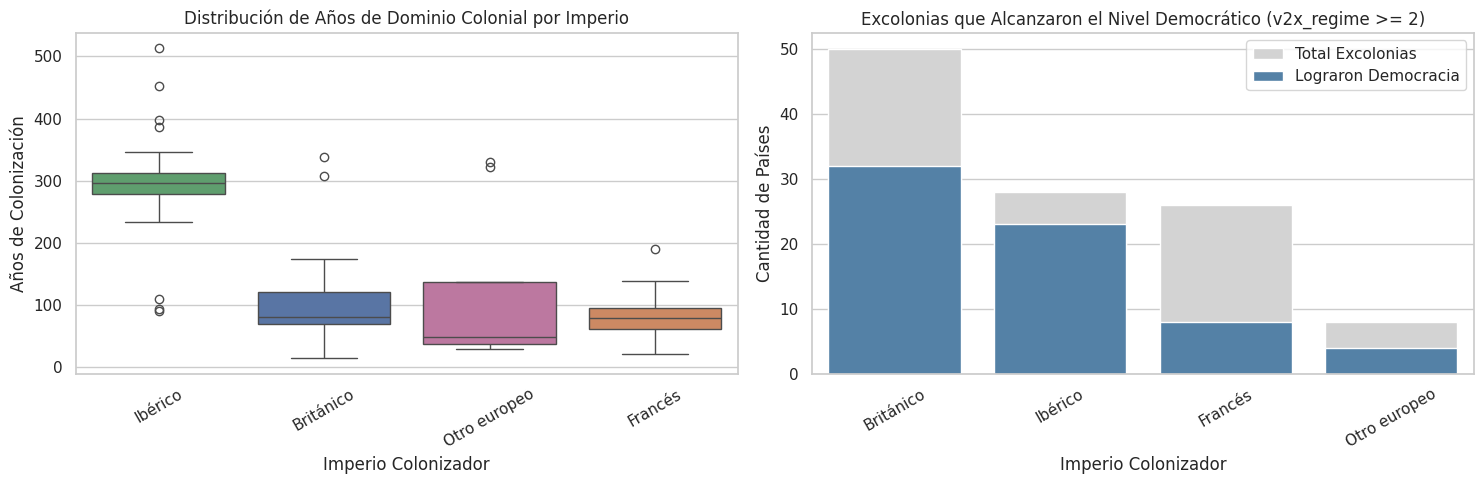

In [ ]:
# ==========================================
# GRÁFICOS EXPLORATORIOS
# ==========================================

# Definimos el estilo general y el tamaño de los gráficos.
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Paleta de colores consistente
paleta_colonizador = {
    'Británico': '#4C72B0',      # Azul
    'Francés': '#DD8452',        # Naranja
    'Ibérico': '#55A868',        # Verde
    'Otro europeo': '#C76DA2'    # Violeta / rosa
}

orden_colonizador = [
    'Ibérico',
    'Británico',
    'Francés',
    'Otro europeo'
]

# Creamos una figura con dos gráficos para explorar:
# 1. la duración de la colonización;
# 2. la democratización según el colonizador.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfico 1: Duración de la colonización ---

# Mostramos la distribución de los años de dominio colonial
# según la categoría de colonizador.
sns.boxplot(data=df_paises, x='colonizador_4cat', y='duracion_colonial', ax=axes[0], palette=paleta_colonizador)  # --- CORRECCIÓN v5 (paleta única): antes 'Set2' genérica ---
axes[0].set_title('Distribución de Años de Dominio Colonial por Imperio')
axes[0].set_xlabel('Imperio Colonizador')
axes[0].set_ylabel('Años de Colonización')
axes[0].tick_params(axis='x', rotation=30)

# --- Gráfico 2: Democratización ---

# Comparamos, para cada categoría de colonizador, la cantidad total de excolonias
# con la cantidad de países que alcanzaron el nivel democrático (v2x_regime >= 2).
sns.barplot(data=tabla_democratizacion, x='colonizador_4cat', y='total_excolonias', color='lightgray', label='Total Excolonias', ax=axes[1])
sns.barplot(data=tabla_democratizacion, x='colonizador_4cat', y='lograron_democracia', color='steelblue', label='Lograron Democracia', ax=axes[1])

# Configuramos título, etiquetas y leyenda del gráfico.
axes[1].set_title('Excolonias que Alcanzaron el Nivel Democrático (v2x_regime >= 2)')
axes[1].set_xlabel('Imperio Colonizador')
axes[1].set_ylabel('Cantidad de Países')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

# Guardamos y mostramos el gráfico.
guardar('exploratorio_duracion_colonial_y_democratizacion')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# MAPA DE EXCOLONIAS SEGÚN COLONIZADOR
# ==========================================

# 1. Preparamos los datos (una fila por país excolonia)
df_mapa = df_final.drop_duplicates(subset=['iso3']).copy()

# Filtramos solo aquellos que tienen un colonizador asignado
df_mapa = df_mapa.dropna(subset=['colonizer'])

# --- Creamos el mapa coroplético interactivo ---

# Coloreamos cada país según el imperio colonizador.
# Plotly utiliza los códigos ISO3 para identificar los países.
fig = px.choropleth(
    df_mapa,
    locations="iso3",               # Plotly lee automáticamente tus códigos ISO3
    color="colonizer",              # Colorea según el imperio
    title="Distribución Global de Excolonias según Imperio Colonizador",
    color_discrete_sequence=px.colors.qualitative.Set1, # Paleta de colores distintiva
    projection="natural earth",     # Estilo de mapa (proyección curva)
    hover_name="iso3"               # Muestra el código al pasar el ratón
)

# --- Ajustamos el diseño del mapa ---

# Configuramos márgenes, leyenda, costas y color de los países
# que no forman parte de la muestra.
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    legend_title_text='Imperio Colonizador',
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="Black",
        showland=True,
        landcolor="lightgray"       # Los países no colonizados quedarán en gris claro
    )
)

# Guardamos el mapa como imagen y lo mostramos.
fig.write_image(f'{carpeta_figuras}/mapa_coropletico.png', scale=3)
fig.show()

# 3. Etapa A — Selección hacia la democracia
Tiempo hasta la primera democratización, por colonizador (Kaplan-Meier + test de log-rank).

In [ ]:
# ==========================================
# ETAPA A: TIEMPO HASTA LA PRIMERA DEMOCRATIZACIÓN
# ==========================================

# Partimos de una observación por país.
df_etapaA = df_paises.copy()

# Identificamos el primer año en que cada país alcanzó el nivel democrático
# (v2x_regime >= 2).
primer_anio_dem = df_final_completo[
    df_final_completo['v2x_regime'] >= 2
].groupby('iso3')['year'].min().rename('primer_anio_democratico')

df_etapaA = df_etapaA.merge(primer_anio_dem, on='iso3', how='left')

# Identificamos el último año observado para cada país.
ultimo_anio_obs = df_final.groupby('iso3')['year'].max().rename('ultimo_anio_obs')
df_etapaA = df_etapaA.merge(ultimo_anio_obs, on='iso3', how='left')

# Definimos el evento: 1 si el país alguna vez alcanzó el nivel democrático,
# 0 si no lo alcanzó durante el período observado.
df_etapaA['event_A'] = df_etapaA['democratizo_alguna_vez']

# Calculamos el tiempo desde la independencia hasta la democratización.
# Para los países que no democratizaron, calculamos el tiempo hasta
# el último año disponible (casos censurados).
df_etapaA['duration_A'] = np.where(
    df_etapaA['event_A'] == 1,
    df_etapaA['primer_anio_democratico'] - df_etapaA['colend_mean'],
    df_etapaA['ultimo_anio_obs'] - df_etapaA['colend_mean']
)

df_etapaA

,country_name,year,v2x_polyarchy,v2x_libdem,v2x_regime,iso3,aut_ep_start_year,aut_ep_outcome_agg,colonizer,duracion_colonial,...,colend_mean,sai_statehisten0,wdi_area,ross_oil_prod,colonizador_4cat,democratizo_alguna_vez,primer_anio_democratico,ultimo_anio_obs,event_A,duration_A
0,Angola,1900,0.008,0.034,0.0,AGO,NaN,0.0,portugal,398.0,...,1974.0,0.0,1246700.0,7564000.0,Ibérico,0,NaN,2025,0,51.0
1,United Arab Emirates,1971,0.016,0.048,0.0,ARE,NaN,0.0,britain,79.0,...,1971.0,0.0,71020.0,58100000.0,Británico,0,NaN,2025,0,54.0
2,Argentina,1900,0.341,0.272,1.0,ARG,NaN,0.0,spain,253.0,...,1818.0,0.0,2736690.0,2814754.0,Ibérico,1,1964.0,2025,1,146.0
3,Australia,1900,0.634,NaN,2.0,AUS,NaN,0.0,britain,106.0,...,1904.0,0.0,7682300.0,137.0,Británico,1,1900.0,2025,1,-4.0
4,Burundi,1916,0.019,0.049,0.0,BDI,NaN,0.0,belgium,40.0,...,1962.0,0.0,25680.0,0.0,Otro europeo,0,NaN,2025,0,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Yemen,1918,0.018,0.012,0.0,YEM,NaN,0.0,britain,88.0,...,1967.0,1350.0,527970.0,0.0,Británico,0,NaN,2025,0,58.0
108,South Africa,1900,0.156,0.110,0.0,ZAF,NaN,0.0,britain,111.0,...,1912.0,0.0,1213090.0,0.0,Británico,1,1995.0,2025,1,83.0
109,Zanzibar,1900,0.033,0.068,0.0,ZAN,NaN,0.0,britain,49.0,...,1961.0,0.0,743390.0,0.0,Británico,0,NaN,2025,0,64.0
110,Zambia,1911,0.039,0.068,0.0,ZMB,NaN,0.0,britain,64.0,...,1964.0,0.0,743390.0,0.0,Británico,1,2007.0,2025,1,43.0


In [ ]:
# Identificamos los casos en los que la duración calculada es negativa,
# es decir, cuando el año de democratización es anterior al año de independencia.

mask_neg_A = df_etapaA['duration_A'] < 0
print(f"[EtapaA][v3] {mask_neg_A.sum()} países con duration_A<0:")
display(df_etapaA.loc[mask_neg_A, ['iso3', 'colonizador_4cat', 'duration_A']].sort_values('duration_A'))



[EtapaA][v3] 5 países con duration_A<0:


,iso3,colonizador_4cat,duration_A
73,NZL,Británico,-9.0
90,SUR,Otro europeo,-9.0
48,JAM,Británico,-6.0
11,BRB,Británico,-6.0
3,AUS,Británico,-4.0


In [ ]:
# Establecemos un umbral para comparar casos donde el desfasaje es pequeño
# y casos donde el desfasaje es grande:
# Los desfasajes entre -5 y -1 años se consideran
# diferencias menores entre las fechas.
UMBRAL_DURACION_A_MENOR = -5  # años
mask_menor_A = mask_neg_A & (
    df_etapaA['duration_A'] >= UMBRAL_DURACION_A_MENOR
)

# Mostramos únicamente los casos que cumplen la condición.
display(
    df_etapaA.loc[
        mask_menor_A,
        ['iso3', 'colonizador_4cat', 'duration_A']
    ]
)


,iso3,colonizador_4cat,duration_A
3,AUS,Británico,-4.0


In [ ]:
# Corregimos los desfasajes pequeños (entre -5 y -1 años),
# asignándoles una duración de 0 años.
df_etapaA.loc[mask_menor_A, 'duration_A'] = 0

# Verificamos cómo quedaron los casos después de la corrección.
display(
    df_etapaA.loc[
        mask_menor_A,
        ['iso3', 'colonizador_4cat', 'duration_A']
    ]
)

,iso3,colonizador_4cat,duration_A
3,AUS,Británico,0.0


In [ ]:
# Revisamos los casos con desfasajes grandes (menores a -5 años).
# Estos casos presentan una diferencia importante entre las fechas
# de independencia y democratización y, por precaución, se excluyen
# del análisis de supervivencia.

mask_revisar_A = df_etapaA['duration_A'] < UMBRAL_DURACION_A_MENOR

if mask_revisar_A.sum() > 0:
    print(
        f"[EtapaA][ATENCIÓN] {mask_revisar_A.sum()} casos "
        "con desfasaje mayor a 5 años — se excluyen del análisis:"
    )

    display(
        df_etapaA.loc[
            mask_revisar_A,
            ['iso3', 'colonizador_4cat', 'duration_A']
        ]
    )

    df_etapaA = df_etapaA[~mask_revisar_A]


# Eliminamos los casos para los que no fue posible calcular
# una duración entre la independencia y el evento o el final
# del período observado.
df_etapaA = df_etapaA[df_etapaA['duration_A'].notna()]


# Resumimos la muestra final que será utilizada en el análisis.
print(
    f"[EtapaA] N países: {len(df_etapaA)} | "
    f"democratizaron: {df_etapaA['event_A'].sum()} | "
    f"nunca: {(df_etapaA['event_A'] == 0).sum()}"
)

[EtapaA][ATENCIÓN] 4 casos con desfasaje mayor a 5 años — se excluyen del análisis:


,iso3,colonizador_4cat,duration_A
11,BRB,Británico,-6.0
48,JAM,Británico,-6.0
73,NZL,Británico,-9.0
90,SUR,Otro europeo,-9.0


[EtapaA] N países: 108 | democratizaron: 63 | nunca: 45


[ok] guardada: km_etapaA_primera_democratizacion.png


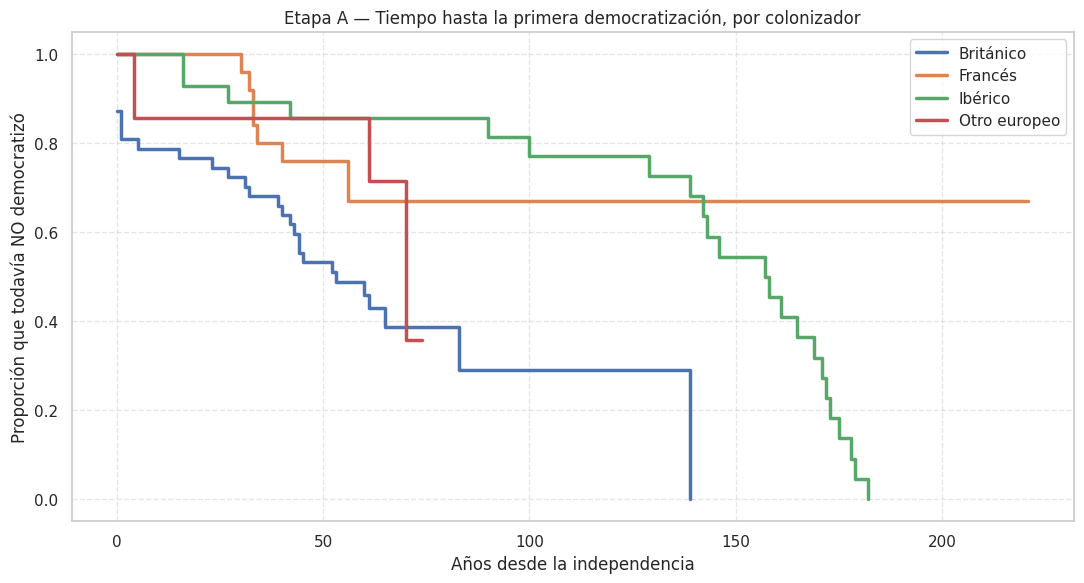

In [ ]:
# Estimamos y graficamos las curvas de Kaplan-Meier para cada categoría
# de colonizador.
fig, ax = plt.subplots(figsize=(11, 6))
kmf_a = KaplanMeierFitter()

for col in ['Británico', 'Francés', 'Ibérico', 'Otro europeo']:
    sub = df_etapaA[df_etapaA['colonizador_4cat'] == col]
    try:
        kmf_a.fit(
            durations=sub['duration_A'],
            event_observed=sub['event_A'],
            label=col
        )
        kmf_a.plot_survival_function(
            ci_show=False,
            linewidth=2.5,
            ax=ax
        )
    except Exception as e:
        print(f"[aviso] {col}: no estimable ({e})")

# Configuramos el gráfico.
ax.set_title('Etapa A — Tiempo hasta la primera democratización, por colonizador')
ax.set_xlabel('Años desde la independencia')
ax.set_ylabel('Proporción que todavía NO democratizó')
ax.grid(True, linestyle='--', alpha=0.5)

# Guardamos y mostramos el gráfico.
guardar('km_etapaA_primera_democratizacion')
plt.tight_layout()
plt.show()

In [ ]:
# Comparamos globalmente las curvas de Kaplan-Meier de las cuatro
# categorías de colonizador para evaluar si el tiempo hasta la
# primera democratización es diferente entre los grupos.
test_global_A = multivariate_logrank_test(
    df_etapaA['duration_A'],        # Tiempo desde la independencia
    df_etapaA['colonizador_4cat'],  # Grupo de colonizador
    df_etapaA['event_A']            # 1 = democratizó; 0 = censurado
)

# El test de log-rank global evalúa la hipótesis nula de que las
# cuatro categorías presentan la misma distribución del tiempo
# hasta la democratización.
print(
    f"\n[EtapaA] Log-rank global entre los cuatro colonizadores: "
    f"p={test_global_A.p_value:.5f}"
)


[EtapaA] Log-rank global entre los cuatro colonizadores: p=0.00044


In [ ]:
# Comparamos mediante el test de log-rank todas las parejas posibles
# de categorías de colonizador.
colonizadores = ['Británico', 'Francés', 'Ibérico', 'Otro europeo']

for col1, col2 in combinations(colonizadores, 2):

    # Seleccionamos los países pertenecientes a cada grupo.
    d1 = df_etapaA[df_etapaA['colonizador_4cat'] == col1]
    d2 = df_etapaA[df_etapaA['colonizador_4cat'] == col2]

    # Comparamos las curvas de Kaplan-Meier de ambos grupos.
    test = logrank_test(
        d1['duration_A'],
        d2['duration_A'],
        d1['event_A'],
        d2['event_A']
    )

    print(
        f"[EtapaA] Log-rank {col1} vs {col2}: "
        f"p={test.p_value:.5f}"
    )

[EtapaA] Log-rank Británico vs Francés: p=0.01615
[EtapaA] Log-rank Británico vs Ibérico: p=0.00007
[EtapaA] Log-rank Británico vs Otro europeo: p=0.29710
[EtapaA] Log-rank Francés vs Ibérico: p=0.92066
[EtapaA] Log-rank Francés vs Otro europeo: p=0.73373
[EtapaA] Log-rank Ibérico vs Otro europeo: p=0.08269


In [ ]:
# ==========================================
# ETAPA B: TIEMPO HASTA EL DETERIORO DEMOCRÁTICO
# ==========================================

# Conservamos únicamente los períodos en los que el país se encuentra
# en un régimen democrático (v2x_regime >= 2). Estos son los períodos
# durante los cuales el país está "en riesgo" de experimentar una
# regresión democrática.
df_etapaB = df_final[df_final['v2x_regime'] >= 2].copy()

# Ordenamos las observaciones por país y año para poder identificar
# correctamente los episodios democráticos consecutivos.
df_etapaB = df_etapaB.sort_values(by=['iso3', 'year'])
df_etapaB

,country_name,year,v2x_polyarchy,v2x_libdem,v2x_regime,iso3,aut_ep_start_year,aut_ep_outcome_agg,colonizer,duracion_colonial,colstart_mean,colend_mean,sai_statehisten0,wdi_area,ross_oil_prod,colonizador_4cat
3957,Argentina,1964,0.528,0.423,2.0,ARG,NaN,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,13700000.0,Ibérico
3958,Argentina,1965,0.527,0.427,2.0,ARG,1966.0,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,13400000.0,Ibérico
3967,Argentina,1974,0.557,0.322,2.0,ARG,1975.0,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,21100000.0,Ibérico
3968,Argentina,1975,0.509,0.290,2.0,ARG,1975.0,3.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,20800000.0,Ibérico
3977,Argentina,1984,0.830,0.674,2.0,ARG,NaN,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,24600000.0,Ibérico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6407,Zambia,2011,0.503,0.420,2.0,ZMB,2011.0,1.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico
6408,Zambia,2012,0.503,0.421,2.0,ZMB,2011.0,1.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico
6418,Zambia,2022,0.520,0.436,2.0,ZMB,NaN,0.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico
6419,Zambia,2023,0.525,0.427,2.0,ZMB,NaN,0.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico


In [ ]:
# Un nuevo episodio comienza cuando entre dos observaciones consecutivas
# del mismo país existe un salto de más de un año.
# Por ejemplo: democracia 1920-1930 y luego 1980-1990 se consideran
# dos episodios democráticos diferentes.
df_etapaB['cambio_episodio'] = (df_etapaB['year'] != df_etapaB.groupby('iso3')['year'].shift(1) + 1).astype(int)

# Asignamos un identificador acumulativo a cada episodio democrático
# dentro de cada país.
df_etapaB['episodio_id'] = df_etapaB.groupby('iso3')['cambio_episodio'].cumsum()
df_etapaB

,country_name,year,v2x_polyarchy,v2x_libdem,v2x_regime,iso3,aut_ep_start_year,aut_ep_outcome_agg,colonizer,duracion_colonial,colstart_mean,colend_mean,sai_statehisten0,wdi_area,ross_oil_prod,colonizador_4cat,cambio_episodio,episodio_id
3957,Argentina,1964,0.528,0.423,2.0,ARG,NaN,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,13700000.0,Ibérico,1,1
3958,Argentina,1965,0.527,0.427,2.0,ARG,1966.0,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,13400000.0,Ibérico,0,1
3967,Argentina,1974,0.557,0.322,2.0,ARG,1975.0,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,21100000.0,Ibérico,1,2
3968,Argentina,1975,0.509,0.290,2.0,ARG,1975.0,3.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,20800000.0,Ibérico,0,2
3977,Argentina,1984,0.830,0.674,2.0,ARG,NaN,0.0,spain,253.0,1565.0,1818.0,0.0,2736690.0,24600000.0,Ibérico,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6407,Zambia,2011,0.503,0.420,2.0,ZMB,2011.0,1.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico,0,1
6408,Zambia,2012,0.503,0.421,2.0,ZMB,2011.0,1.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico,0,1
6418,Zambia,2022,0.520,0.436,2.0,ZMB,NaN,0.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico,1,2
6419,Zambia,2023,0.525,0.427,2.0,ZMB,NaN,0.0,britain,64.0,1900.0,1964.0,0.0,743390.0,0.0,Británico,0,2


In [ ]:
# Identificamos si el episodio termina en un quiebre democrático.
# aut_ep_start_year marca el inicio de cualquier episodio de autocratización,
# pero no todos estos episodios terminan en un quiebre democrático completo.
# Por eso exigimos además aut_ep_outcome_agg == 1, que identifica específicamente
# los episodios cuyo desenlace fue un quiebre democrático.
# Si la variable no existe con este nombre, revisar df_ert.columns y utilizar
# la variable equivalente aut_ep_outcome.
# --- CORRECCIÓN v6: la versión original marcaba el quiebre solo si la fila exacta
# (aut_ep_start_year==year) sobrevivía al filtro v2x_regime>=2 que ya tiene df_etapaB.
# Eso pierde casos donde el año del quiebre cae fuera del episodio (ej. Argentina 1966).
# Ahora buscamos la marca de ERT en TODO el episodio + margen posterior, topeado por
# el inicio del próximo episodio del mismo país, usando episodio_id (ya calculado
# arriba) para las fronteras. Autónomo: no depende de df_supervivencia. ---

fronteras_episodio = df_etapaB.groupby(['iso3', 'episodio_id'])['year'].agg(
    anio_inicio_episodio='min', anio_fin_episodio='max'
).reset_index()

df_final['es_quiebre_marca'] = np.where(
    (df_final['aut_ep_start_year'] == df_final['year']) & (df_final['aut_ep_outcome_agg'] == 1),
    1, 0
)

def buscar_evento_episodio(row, buffer_posterior=3):
    anio_tope = row['anio_fin_episodio'] + buffer_posterior
    siguientes = fronteras_episodio[
        (fronteras_episodio['iso3'] == row['iso3']) &
        (fronteras_episodio['anio_inicio_episodio'] > row['anio_fin_episodio'])
    ]
    if len(siguientes) > 0:
        anio_tope = min(anio_tope, siguientes['anio_inicio_episodio'].min() - 1)
    anios_candidatos = range(row['anio_inicio_episodio'], anio_tope + 1)
    match = df_final[(df_final['iso3'] == row['iso3']) & (df_final['year'].isin(anios_candidatos))]
    return int(match['es_quiebre_marca'].max()) if len(match) > 0 else 0

fronteras_episodio['event_episodio'] = fronteras_episodio.apply(buscar_evento_episodio, axis=1)

df_etapaB = df_etapaB.merge(
    fronteras_episodio[['iso3', 'episodio_id', 'anio_fin_episodio', 'event_episodio']],
    on=['iso3', 'episodio_id'], how='left'
)
df_etapaB['es_quiebre'] = np.where(
    (df_etapaB['year'] == df_etapaB['anio_fin_episodio']) & (df_etapaB['event_episodio'] == 1),
    1, 0
)

print(f"Quiebres detectados en df_etapaB: {df_etapaB['es_quiebre'].sum()}")

Quiebres detectados en df_etapaB: 40


In [ ]:
# Mostramos los casos identificados como quiebre democrático.
casos_quiebre = df_etapaB[
    df_etapaB['es_quiebre'] == 1
].copy()

display(
    casos_quiebre[
        [
            'iso3',
            'country_name',
            'year',
            'v2x_regime',
            'aut_ep_start_year',
            'aut_ep_outcome_agg',
            'colonizador_4cat'
        ]
    ].sort_values(['iso3', 'year'])
)

,iso3,country_name,year,v2x_regime,aut_ep_start_year,aut_ep_outcome_agg,colonizador_4cat
1,ARG,Argentina,1965,2.0,1966.0,0.0,Ibérico
198,BEN,Benin,2018,2.0,2018.0,1.0,Francés
213,BFA,Burkina Faso,2014,2.0,2014.0,1.0,Francés
219,BFA,Burkina Faso,2021,2.0,2018.0,1.0,Francés
229,BGD,Bangladesh,2001,2.0,2002.0,0.0,Británico
262,BOL,Bolivia,2018,2.0,2006.0,1.0,Ibérico
567,CHL,Chile,1972,2.0,1972.0,1.0,Ibérico
607,CIV,Ivory Coast,2019,2.0,2020.0,0.0,Francés
905,FJI,Fiji,1986,2.0,1987.0,0.0,Británico
912,FJI,Fiji,1999,2.0,2000.0,0.0,Británico


In [ ]:
# Resumimos cada episodio democrático en una única observación.
# Identificamos cuándo comienza y termina el episodio, si terminó en un
# quiebre y conservamos las variables de control asociadas al país.
df_supervivencia = df_etapaB.groupby(['iso3', 'colonizer', 'colonizador_4cat', 'episodio_id']).agg(
    anio_inicio_episodio=('year', 'min'),
    anio_fin_episodio=('year', 'max'),
    event=('es_quiebre', 'max'),
    independencia=('colend_mean', 'first'),
    duracion_colonial=('duracion_colonial', 'first'),
    sai_statehisten0=('sai_statehisten0', 'first'),
    wdi_area=('wdi_area', 'first'),
    ross_oil_prod=('ross_oil_prod', 'mean')
).reset_index()

#Verificamos
display(df_supervivencia)

,iso3,colonizer,colonizador_4cat,episodio_id,anio_inicio_episodio,anio_fin_episodio,event,independencia,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod
0,ARG,spain,Ibérico,1,1964,1965,1,1818.0,253.0,0.0,2736690.0,1.355000e+07
1,ARG,spain,Ibérico,2,1974,1975,0,1818.0,253.0,0.0,2736690.0,2.095000e+07
2,ARG,spain,Ibérico,3,1984,2025,0,1818.0,253.0,0.0,2736690.0,3.075438e+07
3,AUS,britain,Británico,1,1900,2025,0,1904.0,106.0,0.0,7682300.0,9.708802e+06
4,BEN,france,Francés,1,1992,2018,1,1960.0,87.0,0.0,112760.0,3.662444e+04
...,...,...,...,...,...,...,...,...,...,...,...,...
104,VEN,spain,Ibérico,1,1959,2001,1,1820.0,286.0,0.0,882050.0,1.414209e+08
105,VUT,britain,Británico,1,1980,2025,0,1980.0,74.0,1350.0,12190.0,0.000000e+00
106,ZAF,britain,Británico,1,1995,2025,0,1912.0,111.0,0.0,1213090.0,4.589870e+05
107,ZMB,britain,Británico,1,2007,2012,1,1964.0,64.0,0.0,743390.0,0.000000e+00


In [ ]:
# Calculamos el tiempo transcurrido desde la independencia hasta
# el comienzo de cada episodio democrático.
df_supervivencia['entry'] = df_supervivencia['anio_inicio_episodio'] - df_supervivencia['independencia']

# Calculamos el tiempo transcurrido desde la independencia hasta
# el final del episodio democrático.
# El +1 permite incluir el año de inicio en el cálculo de duración.
df_supervivencia['duration'] = df_supervivencia['anio_fin_episodio'] - df_supervivencia['independencia'] + 1

# Verificamos
df_supervivencia

,iso3,colonizer,colonizador_4cat,episodio_id,anio_inicio_episodio,anio_fin_episodio,event,independencia,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod,entry,duration
0,ARG,spain,Ibérico,1,1964,1965,1,1818.0,253.0,0.0,2736690.0,1.355000e+07,146.0,148.0
1,ARG,spain,Ibérico,2,1974,1975,0,1818.0,253.0,0.0,2736690.0,2.095000e+07,156.0,158.0
2,ARG,spain,Ibérico,3,1984,2025,0,1818.0,253.0,0.0,2736690.0,3.075438e+07,166.0,208.0
3,AUS,britain,Británico,1,1900,2025,0,1904.0,106.0,0.0,7682300.0,9.708802e+06,-4.0,122.0
4,BEN,france,Francés,1,1992,2018,1,1960.0,87.0,0.0,112760.0,3.662444e+04,32.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,VEN,spain,Ibérico,1,1959,2001,1,1820.0,286.0,0.0,882050.0,1.414209e+08,139.0,182.0
105,VUT,britain,Británico,1,1980,2025,0,1980.0,74.0,1350.0,12190.0,0.000000e+00,0.0,46.0
106,ZAF,britain,Británico,1,1995,2025,0,1912.0,111.0,0.0,1213090.0,4.589870e+05,83.0,114.0
107,ZMB,britain,Británico,1,2007,2012,1,1964.0,64.0,0.0,743390.0,0.000000e+00,43.0,49.0


In [ ]:
# Establecemos un umbral para distinguir pequeños desfasajes entre
# la fecha de independencia y el inicio del episodio de diferencias
# suficientemente grandes como para requerir revisión.
UMBRAL_ENTRY_MENOR = -5  # años; ajustar tras revisar la tabla impresa abajo

# Identificamos los episodios cuyo inicio aparece antes de la
# independencia registrada.
mask_entry_neg = df_supervivencia['entry'] < 0
print(f"[v3] {mask_entry_neg.sum()} episodios con entry<0:")
display(df_supervivencia.loc[mask_entry_neg, ['iso3', 'colonizador_4cat', 'entry']].sort_values('entry'))

[v3] 5 episodios con entry<0:


,iso3,colonizador_4cat,entry
77,NZL,Británico,-9.0
92,SUR,Otro europeo,-9.0
45,JAM,Británico,-6.0
11,BRB,Británico,-6.0
3,AUS,Británico,-4.0


In [ ]:
# Separamos los desfasajes pequeños (entre -5 y -1 años) de los
# desfasajes grandes (menores a -5 años).
mask_menor = mask_entry_neg & (df_supervivencia['entry'] >= UMBRAL_ENTRY_MENOR)
mask_revisar = mask_entry_neg & (df_supervivencia['entry'] < UMBRAL_ENTRY_MENOR)

# Los desfasajes pequeños se consideran diferencias menores entre
# las fechas y se corrigen estableciendo la entrada en 0 años.
print(f"{mask_menor.sum()} casos con desfasaje menor (entry >= {UMBRAL_ENTRY_MENOR}) — se recortan a 0.")
df_supervivencia.loc[mask_menor, 'entry'] = 0

1 casos con desfasaje menor (entry >= -5) — se recortan a 0.


In [ ]:
# Los desfasajes grandes se muestran para revisión y se excluyen
# temporalmente del análisis para evitar incorporar episodios con
# una inconsistencia temporal importante.
if mask_revisar.sum() > 0:
    print(f"[ATENCIÓN] {mask_revisar.sum()} casos con desfasaje grande — decidir manualmente, se excluyen por ahora:")
    display(df_supervivencia.loc[mask_revisar, ['iso3', 'colonizador_4cat', 'entry']])
    df_supervivencia = df_supervivencia[~mask_revisar]

[ATENCIÓN] 4 casos con desfasaje grande — decidir manualmente, se excluyen por ahora:


,iso3,colonizador_4cat,entry
11,BRB,Británico,-6.0
45,JAM,Británico,-6.0
77,NZL,Británico,-9.0
92,SUR,Otro europeo,-9.0


In [ ]:
# Eliminamos los episodios cuya duración no supera el momento
# de entrada al período de riesgo, ya que no representan un
# intervalo válido para el análisis de supervivencia.
n_antes_filtro = len(df_supervivencia)
df_supervivencia = df_supervivencia[df_supervivencia['duration'] > df_supervivencia['entry']]
print(f"Episodios descartados por duration<=entry tras las correcciones: {n_antes_filtro - len(df_supervivencia)}")

#Verificamos
df_supervivencia

Episodios descartados por duration<=entry tras las correcciones: 0


,iso3,colonizer,colonizador_4cat,episodio_id,anio_inicio_episodio,anio_fin_episodio,event,independencia,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod,entry,duration
0,ARG,spain,Ibérico,1,1964,1965,1,1818.0,253.0,0.0,2736690.0,1.355000e+07,146.0,148.0
1,ARG,spain,Ibérico,2,1974,1975,0,1818.0,253.0,0.0,2736690.0,2.095000e+07,156.0,158.0
2,ARG,spain,Ibérico,3,1984,2025,0,1818.0,253.0,0.0,2736690.0,3.075438e+07,166.0,208.0
3,AUS,britain,Británico,1,1900,2025,0,1904.0,106.0,0.0,7682300.0,9.708802e+06,0.0,122.0
4,BEN,france,Francés,1,1992,2018,1,1960.0,87.0,0.0,112760.0,3.662444e+04,32.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,VEN,spain,Ibérico,1,1959,2001,1,1820.0,286.0,0.0,882050.0,1.414209e+08,139.0,182.0
105,VUT,britain,Británico,1,1980,2025,0,1980.0,74.0,1350.0,12190.0,0.000000e+00,0.0,46.0
106,ZAF,britain,Británico,1,1995,2025,0,1912.0,111.0,0.0,1213090.0,4.589870e+05,83.0,114.0
107,ZMB,britain,Británico,1,2007,2012,1,1964.0,64.0,0.0,743390.0,0.000000e+00,43.0,49.0


In [ ]:
# Single-spell:
# Para el análisis principal, conservamos únicamente el primer episodio
# democrático de cada país. De este modo, cada país aporta una sola
# observación y evitamos que los países con múltiples episodios tengan
# mayor peso en el análisis.
df_supervivencia_single = df_supervivencia[
    df_supervivencia['episodio_id'] == 1
].copy()

print(
    f"[Etapa B] df_supervivencia_single: {len(df_supervivencia_single)} "
    "países con su primer episodio democrático (single-spell)."
)

[Etapa B] df_supervivencia_single: 63 países con su primer episodio democrático (single-spell).


In [ ]:
# ==========================================
# TABLA 1: ESTADÍSTICAS DESCRIPTIVAS POR TIPO DE COLONIZADOR
# ==========================================

# Construimos una tabla descriptiva agrupando los países según
# la categoría de su colonizador.
#
# La tabla incluye:
# - cantidad de países por categoría;
# - duración mediana del período colonial y sus percentiles 25 y 75;
# - año mediano de independencia;
# - porcentaje de países que alguna vez alcanzaron el nivel democrático;
# - cantidad de episodios que terminaron en un quiebre democrático;
# - cantidad de observaciones-año en las que los países estuvieron
#   dentro del período de riesgo democrático (Etapa B).

tabla1_completa = pd.DataFrame({

    # Cantidad de países diferentes dentro de cada categoría
    # de colonizador.
    'n_paises': df_paises.groupby('colonizador_4cat')['iso3'].nunique(),

    # Duración del período colonial: mediana y percentiles 25 y 75.
    'duracion_colonial_mediana': (
        df_paises.groupby('colonizador_4cat')['duracion_colonial']
        .median().round(1)
    ),

    'duracion_colonial_p25': (
        df_paises.groupby('colonizador_4cat')['duracion_colonial']
        .quantile(0.25).round(1)
    ),

    'duracion_colonial_p75': (
        df_paises.groupby('colonizador_4cat')['duracion_colonial']
        .quantile(0.75).round(1)
    ),

    # Año mediano de independencia de los países de cada categoría.
    'anio_independencia_mediana': (
        df_paises.groupby('colonizador_4cat')['colend_mean']
        .median()
    ),

    # Porcentaje de países que alcanzaron alguna vez el nivel
    # democrático definido para la Etapa A.
    'pct_democratizo_alguna_vez': (
        df_paises.groupby('colonizador_4cat')['democratizo_alguna_vez']
        .mean() * 100
    ).round(1),

    # Cantidad total de episodios democráticos que fueron identificados
    # como terminados en un quiebre democrático.
    'n_eventos_quiebre': (
        df_supervivencia.groupby('colonizador_4cat')['event']
        .sum()
    ),

    # Cantidad de observaciones país-año en las que el país se encontraba
    # en riesgo de experimentar un quiebre democrático (Etapa B).
    'anios_pais_riesgo': (
        df_etapaB.groupby('colonizador_4cat').size()
    ),

}).reset_index()

# Mostramos la tabla descriptiva final.
tabla1_completa

,colonizador_4cat,n_paises,duracion_colonial_mediana,duracion_colonial_p25,duracion_colonial_p75,anio_independencia_mediana,pct_democratizo_alguna_vez,n_eventos_quiebre,anios_pais_riesgo
0,Británico,50,81.0,69.0,121.5,1961.0,64.0,14,1410
1,Francés,26,79.0,61.2,95.5,1960.0,30.8,10,152
2,Ibérico,28,296.5,278.2,312.8,1823.0,82.1,14,833
3,Otro europeo,8,49.0,38.0,136.8,1956.0,50.0,2,125


In [ ]:
# Si alguna categoría de colonizador no presenta ningún episodio
# de quiebre democrático, reemplazamos el valor faltante (NaN) por 0.
# Esto permite interpretar correctamente la ausencia de eventos.
tabla1_completa['n_eventos_quiebre'] = (
    tabla1_completa['n_eventos_quiebre'].fillna(0)
)

# Calculamos la tasa de quiebres democráticos por cada 1.000 años-país
# en riesgo.
#
# La tasa relaciona la cantidad de quiebres observados con el tiempo
# total durante el cual los países estuvieron expuestos al riesgo de
# sufrir un quiebre. Multiplicamos por 1.000 para facilitar la lectura.
tabla1_completa['tasa_quiebre_x1000_anios_pais'] = (
    tabla1_completa['n_eventos_quiebre']
    / tabla1_completa['anios_pais_riesgo']
    * 1000
).round(2)

# Mostramos la Tabla 1 completa, incorporando la tasa de quiebres
# calculada para cada categoría de colonizador.
print("=== TABLA 1 completa (metodología, sección 7.3) ===")
display(tabla1_completa)

dfi.export(
    tabla1_completa,
    f'{carpeta_figuras}/tabla1_completa.png',
    table_conversion='matplotlib'
)

=== TABLA 1 completa (metodología, sección 7.3) ===


,colonizador_4cat,n_paises,duracion_colonial_mediana,duracion_colonial_p25,duracion_colonial_p75,anio_independencia_mediana,pct_democratizo_alguna_vez,n_eventos_quiebre,anios_pais_riesgo,tasa_quiebre_x1000_anios_pais
0,Británico,50,81.0,69.0,121.5,1961.0,64.0,14,1410,9.93
1,Francés,26,79.0,61.2,95.5,1960.0,30.8,10,152,65.79
2,Ibérico,28,296.5,278.2,312.8,1823.0,82.1,14,833,16.81
3,Otro europeo,8,49.0,38.0,136.8,1956.0,50.0,2,125,16.00


/tmp/ipykernel_2840/2296769578.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2840/2296769578.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




[ok] guardada: boxplot_duracion_colonial_y_democratica.png


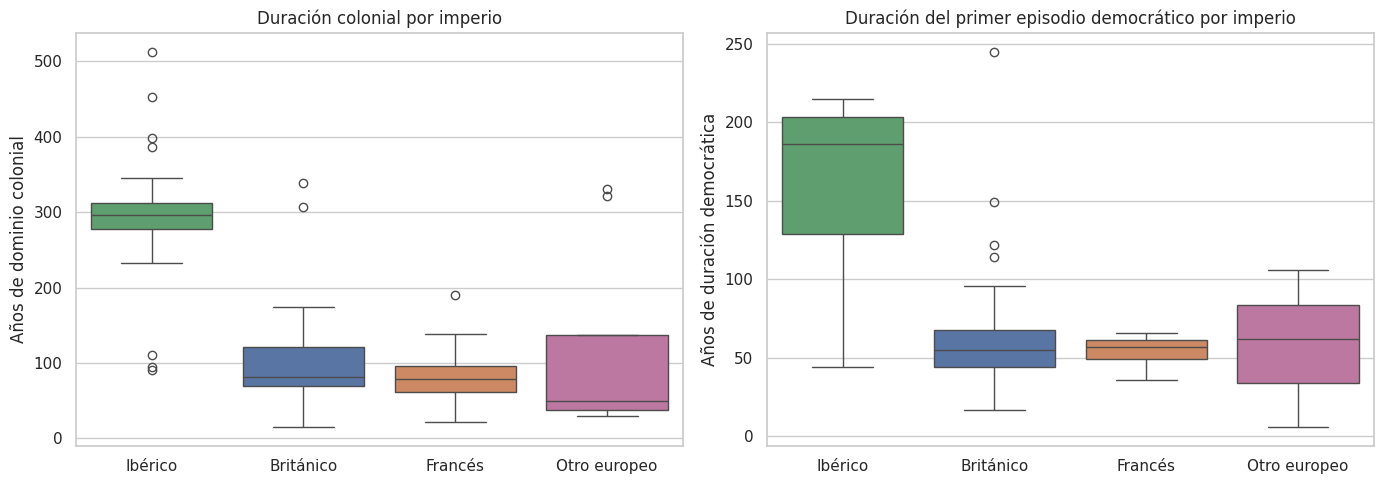

[ok] guardada: duracion_colonial_vs_democratica_kde.png


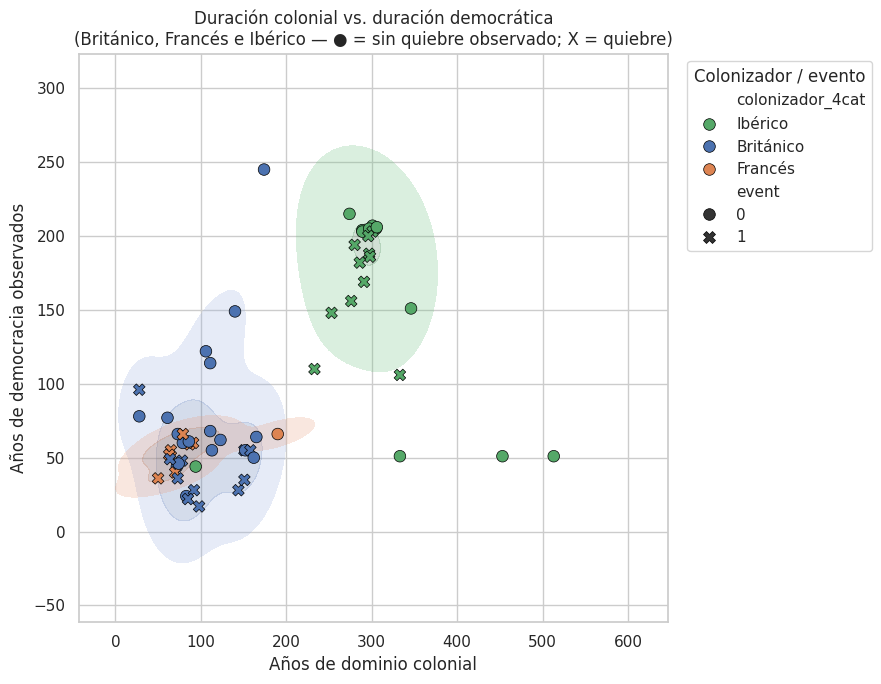

[nota] 'Otro europeo' (N=3) se excluyó de este gráfico.
[nota] La categoría se mantiene en las tablas y en el boxplot comparativo de los cuatro grupos.


In [ ]:
# ==========================================
# VISUALIZACIÓN: DURACIÓN COLONIAL Y DURACIÓN DEMOCRÁTICA
# ==========================================

# Comparamos descriptivamente dos dimensiones de la muestra:
# 1. cuánto tiempo duró el período colonial;
# 2. cuánto tiempo duró el primer episodio democrático observado.
#
# Cada boxplot permite comparar la distribución de estas variables
# entre las cuatro categorías de colonizador.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ------------------------------------------
# 1. Duración del período colonial
# ------------------------------------------

# Utilizamos df_paises porque contiene una observación por país.
# La variable duracion_colonial mide la cantidad de años entre
# el comienzo y el final del período colonial.
sns.boxplot(
    data=df_paises,
    x='colonizador_4cat',
    y='duracion_colonial',
    order=orden_colonizador,
    palette=paleta_colonizador,
    ax=axes[0]
)

axes[0].set_title('Duración colonial por imperio')
axes[0].set_xlabel('')
axes[0].set_ylabel('Años de dominio colonial')


# ------------------------------------------
# 2. Duración del primer episodio democrático
# ------------------------------------------

# Utilizamos df_supervivencia_single, que conserva únicamente
# el primer episodio democrático de cada país.
#
# La variable duration representa la duración observada de ese
# episodio democrático, haya terminado en un quiebre o haya quedado
# censurado al final del período de observación.
sns.boxplot(
    data=df_supervivencia_single,
    x='colonizador_4cat',
    y='duration',
    order=orden_colonizador,
    palette=paleta_colonizador,
    ax=axes[1]
)

axes[1].set_title('Duración del primer episodio democrático por imperio')
axes[1].set_xlabel('')
axes[1].set_ylabel('Años de duración democrática')


# Guardamos y mostramos ambos gráficos.
guardar('boxplot_duracion_colonial_y_democratica')
plt.tight_layout()
plt.show()


# ==========================================
# DURACIÓN COLONIAL Y DURACIÓN DEMOCRÁTICA
# SEGÚN LA LONGITUD DEL PERÍODO COLONIAL
# ==========================================

# Clasificamos los países según la duración de su período colonial.
# Para ello dividimos la distribución en tres grupos de igual tamaño
# (terciles):
#   - Corta: tercio inferior de duración colonial.
#   - Media: tercio intermedio.
#   - Larga: tercio superior.
#
# Esta clasificación permite explorar si los países que estuvieron
# sometidos durante períodos coloniales más largos presentan también
# diferencias en la duración de sus episodios democráticos.
df_supervivencia_single['duracion_colonial_tercil'] = pd.qcut(
    df_supervivencia_single['duracion_colonial'],
    3,
    labels=['Corta', 'Media', 'Larga'],
    duplicates='drop'
)


# Excluimos la categoría "Otro europeo" únicamente de esta
# visualización, debido a su reducido número de casos.
# La categoría no se elimina de los datos originales ni del resto
# de los análisis.
df_scatter = df_supervivencia_single[
    df_supervivencia_single['colonizador_4cat'] != 'Otro europeo'
].copy()


# Utilizamos la misma paleta de colores definida previamente,
# eliminando solamente la categoría que no se incluye en este gráfico.
paleta = {
    k: v
    for k, v in paleta_colonizador.items()
    if k != 'Otro europeo'
}


# Creamos el gráfico que relaciona la duración del período colonial
# con la duración del primer episodio democrático.
fig, ax = plt.subplots(figsize=(9, 7))


# La estimación KDE permite visualizar dónde se concentra la
# distribución de los países para cada categoría de colonizador.
# Las áreas sombreadas facilitan la identificación de zonas con
# mayor concentración de observaciones.
sns.kdeplot(
    data=df_scatter,
    x='duracion_colonial',
    y='duration',
    hue='colonizador_4cat',
    palette=paleta,
    fill=True,
    alpha=0.25,
    levels=3,
    thresh=0.15,
    ax=ax,
    warn_singular=False
)


# Agregamos las observaciones individuales para mostrar la relación
# entre duración colonial y duración democrática.
#
# El símbolo identifica el resultado del episodio democrático:
#   ● = no se observó un quiebre durante el período de observación.
#   X = el episodio terminó en un quiebre democrático.
sns.scatterplot(
    data=df_scatter,
    x='duracion_colonial',
    y='duration',
    hue='colonizador_4cat',
    palette=paleta,
    style='event',
    style_order=[0, 1],
    markers={0: 'o', 1: 'X'},
    s=70,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend='brief'
)


# Simplificamos la leyenda para evitar etiquetas repetidas
# generadas por las variables de color y forma.
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title='Colonizador / evento',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


# Configuramos los ejes y el título.
ax.set_xlabel('Años de dominio colonial')
ax.set_ylabel('Años de democracia observados')

ax.set_title(
    'Duración colonial vs. duración democrática\n'
    '(Británico, Francés e Ibérico — ● = sin quiebre observado; X = quiebre)'
)


# Guardamos y mostramos el gráfico.
guardar('duracion_colonial_vs_democratica_kde')
plt.tight_layout()
plt.show()


# Dejamos constancia de que "Otro europeo" fue excluido únicamente
# de este gráfico por contar con pocos casos, lo que dificulta una
# representación confiable de su distribución.
print(
    f"[nota] 'Otro europeo' "
    f"(N={(df_supervivencia_single['colonizador_4cat']=='Otro europeo').sum()}) "
    f"se excluyó de este gráfico."
)
print(
    "[nota] La categoría se mantiene en las tablas y en el boxplot "
    "comparativo de los cuatro grupos."
)

[ok] guardada: diagrama_episodios_swimmer.png


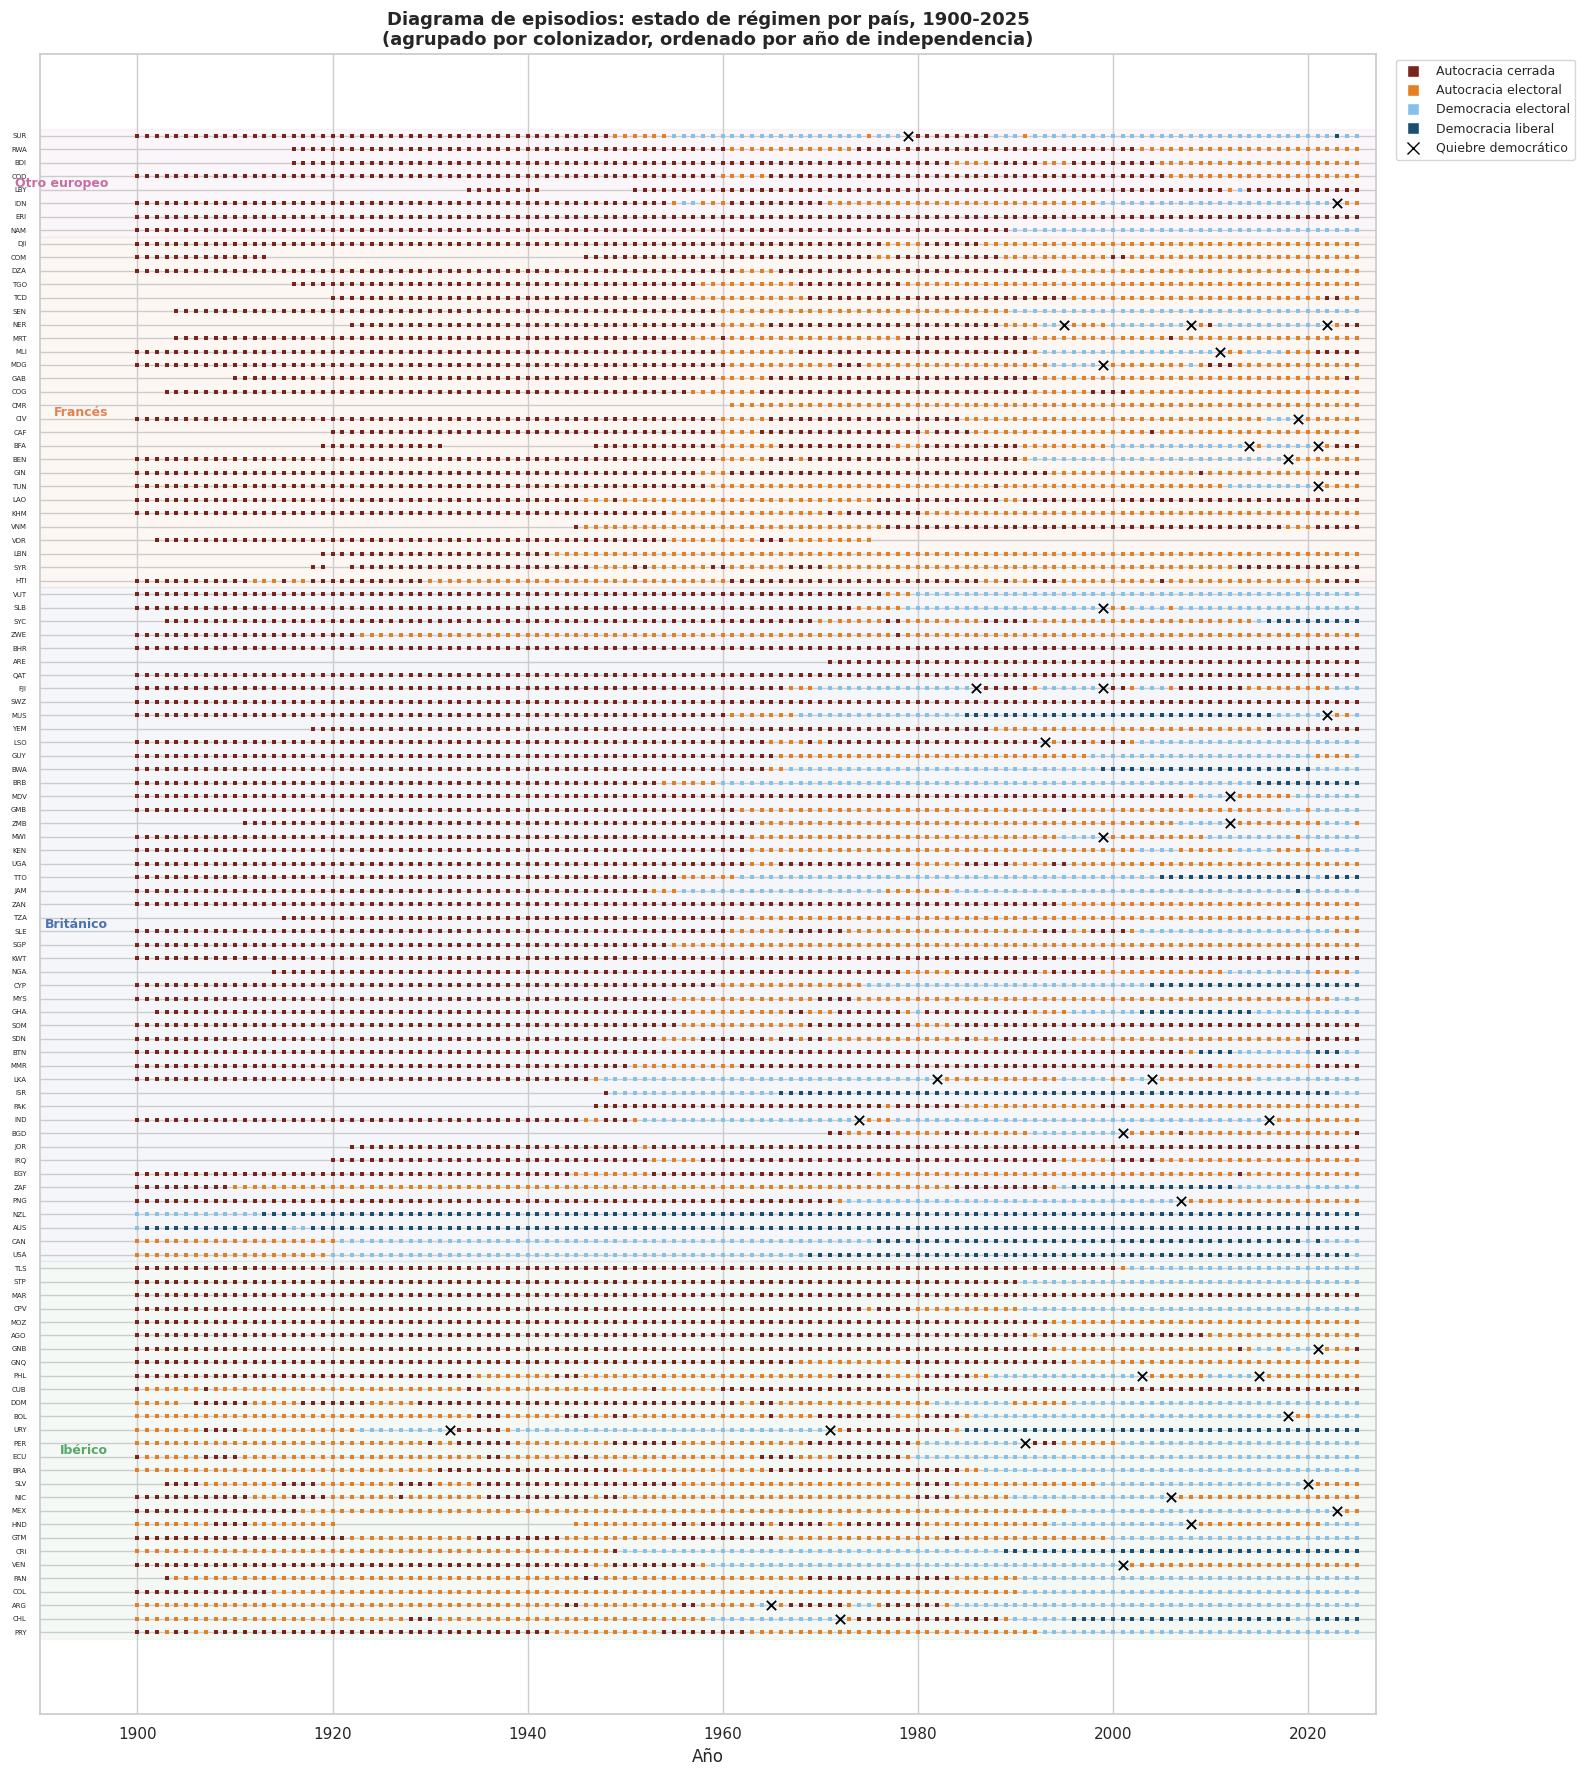

[EtapaB] 112 países graficados, ordenados por colonizador y año de independencia.


In [ ]:
# ==========================================
# DIAGRAMA DE EPISODIOS (SWIMMER PLOT)
# ==========================================

# Un país por fila, desde la independencia
# hasta el cierre de la ventana, coloreado por estado de régimen (v2x_regime) año a
# año, con marca en los quiebres democráticos (TODOS los episodios, no solo
# single-spell -- un país puede quebrar más de una vez, sección 4 de la
# metodología), agrupado por colonizador. Usa df_final_completo (sin piso de 1900,
# igual que la trayectoria de arriba) para mostrar también los casos
# latinoamericanos anteriores a 1900, aunque el conjunto de riesgo formal de la
# Etapa B empiece recién ahí. Funciona como verificación visual de que ese
# conjunto de riesgo está bien construido. ---


# Visualizamos la trayectoria del régimen político de cada país a lo largo del
# período observado. Cada país ocupa una fila y cada año se representa según
# el tipo de régimen registrado en v2x_regime.
#
# A diferencia del análisis de supervivencia de la Etapa B, que trabaja con
# los episodios democráticos y sus quiebres, este gráfico muestra la trayectoria
# completa del régimen político. Por eso permite visualizar tanto los períodos
# autocráticos como los democráticos y todos los episodios de cada país.
#
# Los quiebres democráticos identificados previamente en df_supervivencia se
# señalan con una "X". De este modo, el gráfico funciona también como una
# comprobación visual de la construcción de los episodios democráticos.

# Definimos los colores correspondientes a cada categoría de régimen.
REGIME_COLORS = {
    0: '#7B241C',   # Autocracia cerrada
    1: '#E67E22',   # Autocracia electoral
    2: '#85C1E9',   # Democracia electoral
    3: '#1B4F72',   # Democracia liberal
}

# Definimos las etiquetas que aparecerán en la leyenda del gráfico.
REGIME_LABELS = {
    0: 'Autocracia cerrada',
    1: 'Autocracia electoral',
    2: 'Democracia electoral',
    3: 'Democracia liberal',
}


# ==========================================
# 1. CONSTRUIMOS LA BASE PARA EL SWIMMER PLOT
# ==========================================
# Partimos de df_final_completo para conservar la trayectoria política completa
# de cada país durante todo el período observado.
df_swimmer = df_final_completo[
    ['iso3', 'year', 'v2x_regime']
].dropna(subset=['v2x_regime']).copy()

# Incorporamos la categoría de colonizador y el año de independencia,
# necesarios para ordenar y agrupar visualmente los países.
df_swimmer = df_swimmer.merge(
    df_paises[['iso3', 'colonizador_4cat', 'colend_mean']],
    on='iso3',
    how='left'
)

# Eliminamos los países para los cuales no tenemos información sobre
# la categoría de colonizador.
df_swimmer = df_swimmer.dropna(subset=['colonizador_4cat'])

# Convertimos v2x_regime en una variable entera con valores entre 0 y 3,
# correspondientes a las cuatro categorías de régimen utilizadas en el gráfico.
df_swimmer['v2x_regime'] = (
    df_swimmer['v2x_regime']
    .round()
    .clip(0, 3)
    .astype(int)
)


# ==========================================
# 2. ORDENAMOS LOS PAÍSES
# ==========================================
# Ordenamos primero por categoría de colonizador, utilizando el mismo orden
# definido para el resto del análisis, y luego por año de independencia.
# Esto permite comparar visualmente los países dentro de cada grupo colonial.
df_paises_ord = df_paises[
    df_paises['iso3'].isin(df_swimmer['iso3'].unique())
].copy()

df_paises_ord['colonizador_4cat'] = pd.Categorical(
    df_paises_ord['colonizador_4cat'],
    categories=orden_colonizador,
    ordered=True
)

df_paises_ord = df_paises_ord.sort_values(
    ['colonizador_4cat', 'colend_mean']
).reset_index(drop=True)

# Guardamos el orden final de los países y asignamos una posición vertical
# a cada uno para utilizarla en el gráfico.
orden_paises = df_paises_ord['iso3'].tolist()

pos_pais = {
    iso3: i
    for i, iso3 in enumerate(orden_paises)
}

df_swimmer['y_pos'] = df_swimmer['iso3'].map(pos_pais)


# ==========================================
# 3. CREAAMOS EL GRÁFICO
# ==========================================
# Cada país ocupa una fila y cada observación anual se representa como un
# cuadrado coloreado según el régimen político registrado ese año.
n_paises = len(orden_paises)

fig, ax = plt.subplots(
    figsize=(16, max(10, n_paises * 0.16))
)

for regimen, color in REGIME_COLORS.items():

    # Seleccionamos las observaciones correspondientes a cada tipo de régimen.
    sub = df_swimmer[df_swimmer['v2x_regime'] == regimen]

    # Representamos cada año como un cuadrado del color correspondiente.
    ax.scatter(
        sub['year'],
        sub['y_pos'],
        color=color,
        marker='s',
        s=9,
        linewidths=0
    )


# ==========================================
# 4. IDENTIFICAMOS LOS QUIEBRES DEMOCRÁTICOS
# ==========================================
# Recuperamos los episodios que fueron identificados previamente como quiebres
# democráticos en df_supervivencia (event == 1).
quiebres = df_supervivencia.loc[
    df_supervivencia['event'] == 1,
    ['iso3', 'anio_fin_episodio']
].copy()

# Asignamos a cada quiebre la posición vertical correspondiente al país.
quiebres['y_pos'] = quiebres['iso3'].map(pos_pais)

# Conservamos únicamente los quiebres que corresponden a países incluidos
# en el gráfico.
quiebres = quiebres.dropna(subset=['y_pos'])

# Marcamos cada quiebre con una "X" negra.
ax.scatter(
    quiebres['anio_fin_episodio'],
    quiebres['y_pos'],
    marker='x',
    color='black',
    s=45,
    linewidths=1.3,
    zorder=5
)


# ==========================================
# 5. DESTACAMOS LOS GRUPOS DE COLONIZADOR
# ==========================================
# Agregamos bandas de fondo para separar visualmente los países según
# su categoría de colonizador.
#
# Como los países ya están ordenados por colonizador, cada grupo forma
# un bloque contiguo de filas.
i = 0

for colon, grupo in groupby(
    df_paises_ord['colonizador_4cat'].tolist()
):

    tam = len(list(grupo))

    y_ini = i - 0.5
    y_fin = i + tam - 1 + 0.5

    # Banda de fondo correspondiente al grupo colonial.
    ax.axhspan(
        y_ini,
        y_fin,
        color=paleta_colonizador[colon],
        alpha=0.06,
        zorder=0
    )

    # Etiqueta del grupo colonial.
    ax.text(
        df_swimmer['year'].min() - 3,
        (y_ini + y_fin) / 2,
        colon,
        ha='right',
        va='center',
        fontsize=9,
        fontweight='bold',
        color=paleta_colonizador[colon]
    )

    i += tam


# ==========================================
# 6. CONFIGURAMOS EL GRÁFICO Y LA LEYENDA
# ==========================================
# Etiquetamos cada fila con el código ISO3 correspondiente al país.
ax.set_yticks(range(n_paises))
ax.set_yticklabels(orden_paises, fontsize=5)

ax.set_xlabel('Año')

ax.set_title(
    f'Diagrama de episodios: estado de régimen por país, '
    f'{int(df_swimmer["year"].min())}-{VENTANA_FIN}\n'
    '(agrupado por colonizador, ordenado por año de independencia)',
    fontsize=13,
    fontweight='bold'
)

# Definimos los límites temporales del gráfico.
ax.set_xlim(
    df_swimmer['year'].min() - 10,
    VENTANA_FIN + 2
)

# Construimos manualmente la leyenda para mostrar las cuatro categorías
# de régimen y la marca utilizada para identificar los quiebres.
handles = [
    plt.Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=c,
        markersize=8,
        label=REGIME_LABELS[k]
    )
    for k, c in REGIME_COLORS.items()
]

handles.append(
    plt.Line2D(
        [0], [0],
        marker='x',
        color='black',
        linestyle='None',
        markersize=8,
        label='Quiebre democrático'
    )
)

ax.legend(
    handles=handles,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    fontsize=9
)


# ==========================================
# 7. GUARDAMOS Y MOSTRAR EL GRÁFICO
# ==========================================
guardar('diagrama_episodios_swimmer')

plt.tight_layout()
plt.show()

print(
    f"[EtapaB] {n_paises} países graficados, "
    "ordenados por colonizador y año de independencia."
)

# 4. Modelo — Nivel y tendencia democrática
Sobre las 112 excolonias, sin condicionar a haber democratizado. Nivel promedio y pendiente de v2x_polyarchy.

In [ ]:
# Tendencia de v2x_polyarchy por país:
# Para las 110 excolonias, sin distinguir entre Etapa A/B.
# La trayectoria comienza en el año de independencia de cada país
# y llega hasta 2025. No se aplica un piso de 1900.
# Solo se calcula una tendencia cuando existen al menos 5 años observados.

# Establecemos el mínimo de observaciones/años que debe tener un país
# para poder calcular una tendencia de su nivel de democracia.
MIN_ANIOS_TENDENCIA = 5

# Seleccionamos las variables necesarias para construir la trayectoria
# democrática y, posteriormente, relacionarla con las características
# históricas y estructurales del país.
df_trayectoria = df_final_completo[
    [
        'iso3',
        'year',
        'v2x_polyarchy',
        'colend_mean',
        'duracion_colonial',
        'sai_statehisten0',
        'wdi_area',
        'ross_oil_prod'
    ]
].copy()

# Incorporamos la categoría del colonizador.
df_trayectoria = df_trayectoria.merge(
    df_paises[['iso3', 'colonizador_4cat']],
    on='iso3',
    how='left'
)

# Aseguramos que las variables utilizadas para definir el período
# estén en formato numérico.
df_trayectoria['year'] = pd.to_numeric(
    df_trayectoria['year'],
    errors='coerce'
)

df_trayectoria['colend_mean'] = pd.to_numeric(
    df_trayectoria['colend_mean'],
    errors='coerce'
)

# Conservamos únicamente los años comprendidos entre la independencia
# y 2025.
df_trayectoria = df_trayectoria[
    (df_trayectoria['year'] >= df_trayectoria['colend_mean']) &
    (df_trayectoria['year'] <= 2025)
].copy()

# Ordenamos la trayectoria temporal de cada país.
df_trayectoria = df_trayectoria.sort_values(
    ['iso3', 'year']
).reset_index(drop=True)

df_trayectoria

,iso3,year,v2x_polyarchy,colend_mean,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod,colonizador_4cat
0,AGO,1974,0.021,1974.0,398.0,0.0,1246700.0,7564000.0,Ibérico
1,AGO,1975,0.073,1974.0,398.0,0.0,1246700.0,7564000.0,Ibérico
2,AGO,1976,0.073,1974.0,398.0,0.0,1246700.0,7564000.0,Ibérico
3,AGO,1977,0.073,1974.0,398.0,0.0,1246700.0,7062000.0,Ibérico
4,AGO,1978,0.073,1974.0,398.0,0.0,1246700.0,6469000.0,Ibérico
...,...,...,...,...,...,...,...,...,...
10374,ZWE,2021,0.297,1975.0,75.0,0.0,386850.0,0.0,Británico
10375,ZWE,2022,0.292,1975.0,75.0,0.0,386850.0,0.0,Británico
10376,ZWE,2023,0.296,1975.0,75.0,0.0,386850.0,0.0,Británico
10377,ZWE,2024,0.272,1975.0,75.0,0.0,386850.0,0.0,Británico


In [ ]:
# Calculamos cuántos años han transcurrido desde la independencia
# en cada observación país-año.

# Por ejemplo, si un país se independizó en 1950:
# 1950 = 0 años desde la independencia
# 1951 = 1 año
# 1960 = 10 años
# etc.

# Esta será la variable temporal utilizada para estimar
# la tendencia de la democracia después de la independencia.
df_trayectoria['anios_desde_independencia'] = df_trayectoria['year'] - df_trayectoria['colend_mean']

#Verificamos
df_trayectoria

,iso3,year,v2x_polyarchy,colend_mean,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod,colonizador_4cat,anios_desde_independencia
0,AGO,1974,0.021,1974.0,398.0,0.0,1246700.0,7564000.0,Ibérico,0.0
1,AGO,1975,0.073,1974.0,398.0,0.0,1246700.0,7564000.0,Ibérico,1.0
2,AGO,1976,0.073,1974.0,398.0,0.0,1246700.0,7564000.0,Ibérico,2.0
3,AGO,1977,0.073,1974.0,398.0,0.0,1246700.0,7062000.0,Ibérico,3.0
4,AGO,1978,0.073,1974.0,398.0,0.0,1246700.0,6469000.0,Ibérico,4.0
...,...,...,...,...,...,...,...,...,...,...
10374,ZWE,2021,0.297,1975.0,75.0,0.0,386850.0,0.0,Británico,46.0
10375,ZWE,2022,0.292,1975.0,75.0,0.0,386850.0,0.0,Británico,47.0
10376,ZWE,2023,0.296,1975.0,75.0,0.0,386850.0,0.0,Británico,48.0
10377,ZWE,2024,0.272,1975.0,75.0,0.0,386850.0,0.0,Británico,49.0


In [ ]:
# Contamos cuántos países distintos están disponibles
# en la base antes de aplicar el requisito mínimo de años observados.
total_paises_disponibles = df_trayectoria['iso3'].nunique()

#Verificamos
total_paises_disponibles

112

In [ ]:
# Creamos una lista vacía donde iremos guardando los resultados
# de la pendiente estimada para cada país.
resultados_pendiente = []


# Recorremos la base país por país.
# "grupo" contiene todas las observaciones disponibles
# para un determinado país.
for iso3, grupo in df_trayectoria.groupby('iso3'):


    # Si el país tiene menos de 5 observaciones/años,
    # no calculamos su pendiente y lo excluimos de este análisis.
    if len(grupo) < MIN_ANIOS_TENDENCIA:
        continue

    # Estimamos una regresión lineal de v2x_polyarchy
    # sobre los años transcurridos desde la independencia.

    # La variable independiente (X) es:
    #     anios_desde_independencia

    # La variable dependiente (Y) es:
    #     v2x_polyarchy

    # La pendiente ("slope") indica la dirección y magnitud
    # de la tendencia promedio de la democracia a lo largo del tiempo.
    slope, intercept, r, p, se = stats.linregress(grupo['anios_desde_independencia'], grupo['v2x_polyarchy'])


    # Guardamos en resultados_pendiente un registro por país
    # con la pendiente estimada y distintas características
    # del país que pueden utilizarse posteriormente en el análisis.
    resultados_pendiente.append({

        # Identificador del país.
        'iso3': iso3,

        # Categoría del colonizador.
        'colonizador_4cat': grupo['colonizador_4cat'].iloc[0],

        # Pendiente de v2x_polyarchy respecto de los años
        # transcurridos desde la independencia.
        'pendiente_polyarchy': slope,

        # Cantidad de observaciones/años disponibles para ese país.
        'n_anios': len(grupo),

        # Año de independencia.
        'colend_mean': grupo['colend_mean'].iloc[0],

        # Duración del período colonial.
        'duracion_colonial': grupo['duracion_colonial'].iloc[0],

        # Promedio de la variable histórica en las observaciones disponibles.
        'sai_statehisten0': grupo['sai_statehisten0'].mean(),

        # Promedio de la superficie del país.
        'wdi_area': grupo['wdi_area'].mean(),

        # Promedio de la producción petrolera en las observaciones disponibles.
        'ross_oil_prod': grupo['ross_oil_prod'].mean(),
    })

In [ ]:
# Convertimos la lista de resultados en un DataFrame.
# A partir de acá, cada fila representa un país y no un país-año.
df_tendencia = pd.DataFrame(resultados_pendiente)

# Verificamos
df_tendencia

,iso3,colonizador_4cat,pendiente_polyarchy,n_anios,colend_mean,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod
0,AGO,Ibérico,0.006336,52,1974.0,398.0,0.0,1.246700e+06,4.824207e+07
1,ARE,Británico,0.001900,55,1971.0,79.0,0.0,7.102000e+04,1.094060e+08
2,ARG,Ibérico,0.002886,208,1818.0,253.0,0.0,2.736690e+06,1.040277e+07
3,AUS,Británico,0.001088,122,1904.0,106.0,0.0,7.683097e+06,1.002712e+07
4,BDI,Otro europeo,0.002526,64,1962.0,40.0,0.0,2.568000e+04,0.000000e+00
...,...,...,...,...,...,...,...,...,...
107,YEM,Británico,0.002594,59,1967.0,88.0,1350.0,5.279700e+05,7.795437e+06
108,ZAF,Británico,0.005361,114,1912.0,111.0,0.0,1.213090e+06,1.248122e+05
109,ZAN,Británico,0.005484,65,1961.0,49.0,0.0,7.433900e+05,0.000000e+00
110,ZMB,Británico,0.005364,62,1964.0,64.0,0.0,7.433900e+05,0.000000e+00


In [ ]:
# Clasificamos a los países según si su independencia ocurrió
# antes o después de 1945.

# pre-1945: independencia anterior a 1945.
# post-1945: independencia en 1945 o posteriormente.
df_tendencia['era'] = np.where(df_tendencia['colend_mean'] < 1945, 'pre-1945', 'post-1945')
df_tendencia

,iso3,colonizador_4cat,pendiente_polyarchy,n_anios,colend_mean,duracion_colonial,sai_statehisten0,wdi_area,ross_oil_prod,era
0,AGO,Ibérico,0.006336,52,1974.0,398.0,0.0,1.246700e+06,4.824207e+07,post-1945
1,ARE,Británico,0.001900,55,1971.0,79.0,0.0,7.102000e+04,1.094060e+08,post-1945
2,ARG,Ibérico,0.002886,208,1818.0,253.0,0.0,2.736690e+06,1.040277e+07,pre-1945
3,AUS,Británico,0.001088,122,1904.0,106.0,0.0,7.683097e+06,1.002712e+07,pre-1945
4,BDI,Otro europeo,0.002526,64,1962.0,40.0,0.0,2.568000e+04,0.000000e+00,post-1945
...,...,...,...,...,...,...,...,...,...,...
107,YEM,Británico,0.002594,59,1967.0,88.0,1350.0,5.279700e+05,7.795437e+06,post-1945
108,ZAF,Británico,0.005361,114,1912.0,111.0,0.0,1.213090e+06,1.248122e+05,pre-1945
109,ZAN,Británico,0.005484,65,1961.0,49.0,0.0,7.433900e+05,0.000000e+00,post-1945
110,ZMB,Británico,0.005364,62,1964.0,64.0,0.0,7.433900e+05,0.000000e+00,post-1945


In [ ]:
# Verificamos cuántos países tienen una pendiente calculada
# y cuántos fueron excluidos por tener menos de 5 observaciones.
print(f"[Rol2][tendencia] Países con pendiente calculada: {len(df_tendencia)} | excluidos por <{MIN_ANIOS_TENDENCIA} años: {total_paises_disponibles - len(df_tendencia)}")

# Verificamos cuántos países quedaron en cada categoría de colonizador
# dentro de la muestra final utilizada para calcular las pendientes.
print(df_tendencia['colonizador_4cat'].value_counts())

[Rol2][tendencia] Países con pendiente calculada: 112 | excluidos por <5 años: 0
colonizador_4cat
Británico       50
Ibérico         28
Francés         26
Otro europeo     8
Name: count, dtype: int64


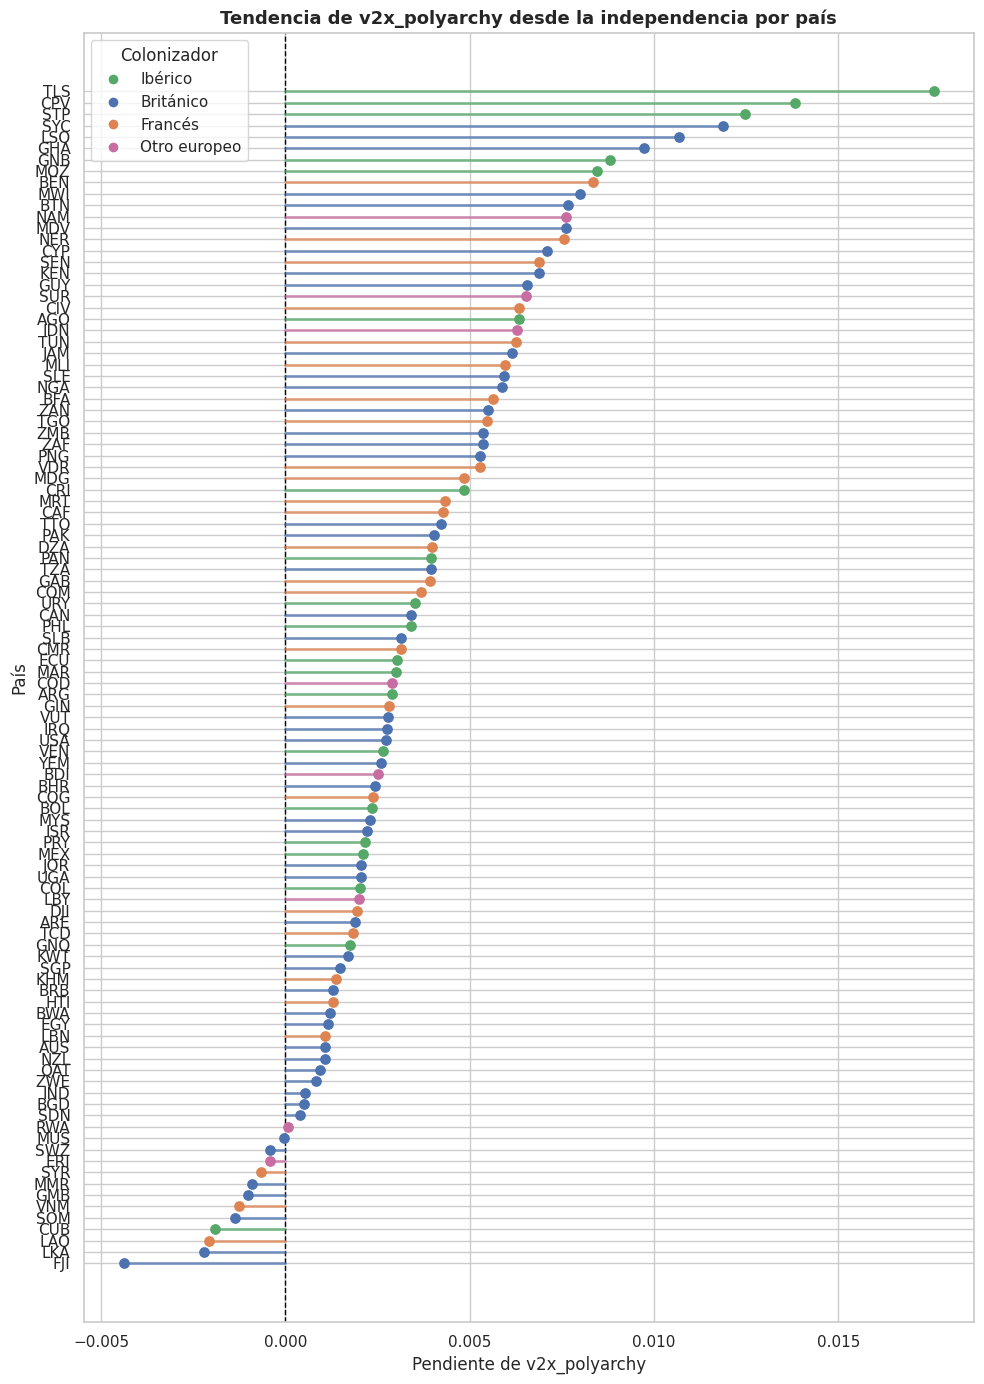

In [ ]:
# ==========================================
# Gráfico: pendiente de v2x_polyarchy por país
# ==========================================

# Hacemos una copia para el gráfico, sin modificar df_tendencia.
df_grafico = df_tendencia.copy()

# Nos quedamos únicamente con los casos que tienen:
# - un país identificado (iso3)
# - una pendiente válida
# - una categoría de colonizador válida
df_grafico = df_grafico[
    df_grafico['iso3'].notna()
    & df_grafico['pendiente_polyarchy'].notna()
    & df_grafico['colonizador_4cat'].notna()
].copy()

# Nos aseguramos de que la pendiente sea numérica.
df_grafico['pendiente_polyarchy'] = pd.to_numeric(
    df_grafico['pendiente_polyarchy'],
    errors='coerce'
)

# Eliminamos nuevamente cualquier pendiente que haya quedado
# como NaN después de la conversión.
df_grafico = df_grafico[
    df_grafico['pendiente_polyarchy'].notna()
].copy()

# Convertimos iso3 explícitamente a texto para evitar
# problemas con el eje categórico de Matplotlib.
df_grafico['iso3'] = df_grafico['iso3'].astype(str)


# Ordenamos los países desde la pendiente más negativa
# hasta la más positiva.
df_grafico = df_grafico.sort_values(
    'pendiente_polyarchy'
).reset_index(drop=True)

# Creamos la figura.
fig, ax = plt.subplots(figsize=(10, 14))

# Línea vertical en cero.
# A la izquierda: tendencia negativa.
# A la derecha: tendencia positiva.
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

# Dibujamos una línea y un punto para cada país.
for _, fila in df_grafico.iterrows():

    color = paleta_colonizador[fila['colonizador_4cat']]

    # Línea desde cero hasta la pendiente.
    ax.plot(
        [0, fila['pendiente_polyarchy']],
        [fila['iso3'], fila['iso3']],
        color=color,
        linewidth=2,
        alpha=0.7
    )

    # Punto que marca la pendiente.
    ax.scatter(
        fila['pendiente_polyarchy'],
        fila['iso3'],
        color=color,
        s=45,
        zorder=3
    )

# Etiquetas de los ejes.
ax.set_xlabel('Pendiente de v2x_polyarchy')
ax.set_ylabel('País')

# Título.
ax.set_title(
    'Tendencia de v2x_polyarchy desde la independencia por país',
    fontsize=13,
    fontweight='bold'
)

# Creamos la leyenda.
from matplotlib.lines import Line2D

handles = []

for colon in orden_colonizador:

    if colon in df_grafico['colonizador_4cat'].unique():

        handles.append(
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=paleta_colonizador[colon],
                markersize=8,
                label=colon
            )
        )


ax.legend(
    handles=handles,
    title='Colonizador',
    loc='best'
)

plt.tight_layout()
plt.show()

[ok] guardada: trayectoria_polyarchy_por_colonizador.png


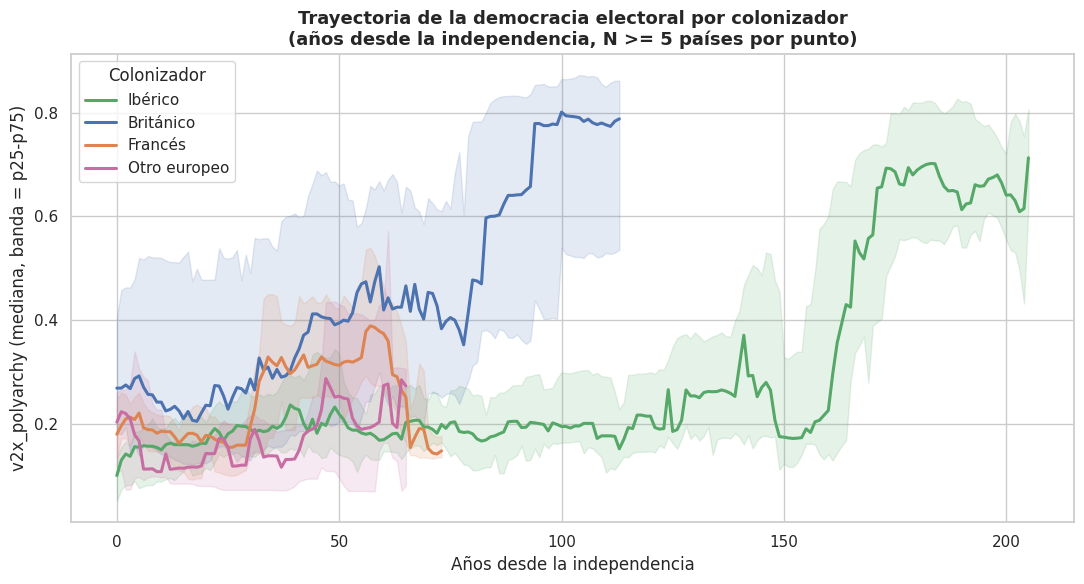

[nota] Puntos recortados a los años con al menos 5 países observados; la cola de casos individuales longevos no infla el gráfico.


In [ ]:
# ==========================================
# Trayectorias de v2x_polyarchy en tiempo-evento
# ==========================================
#
# Este análisis complementa el cálculo de pendientes realizado previamente.
#
# Mientras que en df_tendencia calculamos UNA PENDIENTE POR PAÍS para resumir
# la tendencia lineal de v2x_polyarchy desde la independencia, acá no estimamos
# una pendiente. En cambio, reconstruimos la TRAYECTORIA AGREGADA de la
# democracia para cada grupo de colonizador.
#
# La unidad temporal utilizada no es el año calendario, sino los AÑOS DESDE
# LA INDEPENDENCIA. De esta manera, los países se alinean en el momento 0
# (su año de independencia) y podemos comparar cómo evoluciona su nivel de
# democracia a medida que transcurre el tiempo desde ese evento.
#
# Para cada colonizador y cada año desde la independencia calculamos:
#   - mediana: nivel central de v2x_polyarchy entre los países observados;
#   - p25: percentil 25 de v2x_polyarchy;
#   - p75: percentil 75 de v2x_polyarchy;
#   - n: cantidad de países disponibles en ese punto.
#
# La línea del gráfico representa la MEDIANA de v2x_polyarchy.
# La banda sombreada representa el RANGO INTERCUARTÍLICO (p25-p75),
# es decir, el 50% central de las observaciones.
#
# Se exige un mínimo de países observados en cada punto temporal para evitar
# que los últimos años de la trayectoria queden determinados por uno o pocos
# países con una historia posindependencia particularmente larga.
# ==========================================

# Conservamos únicamente aquellos puntos temporales para los que existen
# al menos 5 países observados.
MIN_PAISES_TRAYECTORIA = 5

# Nos quedamos únicamente con las observaciones posteriores a la independencia.
# "anios_desde_independencia = 0" corresponde al año de independencia;
# los valores positivos corresponden a los años posteriores.
#
# Luego agrupamos por:
#   1. tipo de colonizador
#   2. años transcurridos desde la independencia
#
# Para cada combinación calculamos la mediana y el rango intercuartílico
# de v2x_polyarchy, además de contar cuántos países contribuyen al punto.
resumen_trayectoria = (
    df_trayectoria[df_trayectoria['anios_desde_independencia'] >= 0]
    .groupby(['colonizador_4cat', 'anios_desde_independencia'])['v2x_polyarchy']
    .agg(
        mediana='median',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        n='count'
    )
    .reset_index()
)


# Esto evita extender artificialmente las trayectorias hacia períodos muy
# lejanos desde la independencia cuando solamente quedan uno o pocos países.
resumen_trayectoria = resumen_trayectoria[
    resumen_trayectoria['n'] >= MIN_PAISES_TRAYECTORIA
]

# Creamos el gráfico.
fig, ax = plt.subplots(figsize=(11, 6))

# Recorremos los tipos de colonizador en el orden definido previamente.
# Cada colonizador tendrá una trayectoria independiente.
for colon in orden_colonizador:

    # Seleccionamos los datos correspondientes a ese colonizador
    # y los ordenamos cronológicamente según los años desde la independencia.
    sub = resumen_trayectoria[
        resumen_trayectoria['colonizador_4cat'] == colon
    ].sort_values('anios_desde_independencia')


    # Si no hay observaciones para ese colonizador después del filtro,
    # no dibujamos ninguna trayectoria.
    if sub.empty:
        continue

    # Dibujamos la trayectoria de la MEDIANA de v2x_polyarchy.
    #
    # Eje X = años transcurridos desde la independencia.
    # Eje Y = mediana de v2x_polyarchy entre los países del grupo.
    ax.plot(
        sub['anios_desde_independencia'],
        sub['mediana'],
        color=paleta_colonizador[colon],
        linewidth=2.2,
        label=colon
    )

    # Agregamos la banda intercuartílica.
    #
    # El límite inferior es el percentil 25 (p25)
    # y el límite superior es el percentil 75 (p75).
    #
    # Por lo tanto, la banda muestra la dispersión del 50% central
    # de los países alrededor de la mediana.
    ax.fill_between(
        sub['anios_desde_independencia'],
        sub['p25'],
        sub['p75'],
        color=paleta_colonizador[colon],
        alpha=0.15
    )

# Etiqueta del eje X:
# cantidad de años transcurridos desde la independencia.
ax.set_xlabel('Años desde la independencia')

# Etiqueta del eje Y:
# mediana de v2x_polyarchy y rango intercuartílico.
ax.set_ylabel('v2x_polyarchy (mediana, banda = p25-p75)')

# Título del gráfico.
#
# El N indicado corresponde al mínimo de países que exigimos
# para conservar cada punto de la trayectoria.
ax.set_title(
    f'Trayectoria de la democracia electoral por colonizador\n'
    f'(años desde la independencia, N >= {MIN_PAISES_TRAYECTORIA} países por punto)',
    fontsize=13,
    fontweight='bold'
)

# Incorporamos la leyenda para identificar cada trayectoria
# según el tipo de colonizador.
ax.legend(title='Colonizador')

# Guardamos el gráfico utilizando la función definida previamente.
guardar('trayectoria_polyarchy_por_colonizador')

# Ajustamos automáticamente los márgenes del gráfico.
plt.tight_layout()

# Mostramos el gráfico.
plt.show()

# Dejamos registrada una nota metodológica indicando que los puntos finales
# de las trayectorias fueron recortados cuando había menos del mínimo
# establecido de países observados.
print(
    f"[nota] Puntos recortados a los años con al menos "
    f"{MIN_PAISES_TRAYECTORIA} países observados; "
    f"la cola de casos individuales longevos no infla el gráfico."
)

## 4a.  Modelo OLS: Tendencia de v2x_polyarchy


In [ ]:
# ==========================================
# OLS sobre la tendencia de democratización
# ==========================================

# En este modelo, la variable dependiente es la pendiente de
# v2x_polyarchy calculada previamente para cada país.
#
# Es decir, cada observación de df_tendencia representa un país
# y "pendiente_polyarchy" resume cómo tendió a cambiar su nivel
# de democracia a medida que transcurrieron los años desde
# la independencia.

# La pregunta del modelo es:
# ¿La tendencia de democratización desde la independencia
# difiere según el tipo de colonizador y la época de independencia,
# una vez que controlamos por otras características del país?

# La categoría de referencia para el colonizador es "Británico".
# Por lo tanto, los coeficientes de las demás categorías indican
# cuánto difiere su pendiente promedio respecto de la de los
# países con colonización británica, manteniendo constantes
# las demás variables.

# La categoría de referencia para "era" es "post-1945".
# Por lo tanto, el coeficiente de "pre-1945" indica cuánto difiere
# la pendiente de los países independizados antes de 1945 respecto
# de los independizados desde 1945 en adelante, manteniendo constantes
# las demás variables.

# Además, incluimos como controles:
#   - duracion_colonial: duración del período colonial;
#   - sai_statehisten0: indicador histórico;
#   - wdi_area: superficie del país;
#   - ross_oil_prod: producción petrolera.

# El modelo es una regresión OLS a nivel país.
modelo_ols_tendencia = smf.ols(
    'pendiente_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_tendencia
).fit()


# Mostramos el título del modelo para identificarlo en la salida.
print("=== OLS sobre TENDENCIA (pendiente de v2x_polyarchy) ===")


# Mostramos el resumen completo de la regresión:
# coeficientes, errores estándar, t, p-valores, intervalos de confianza,
# R², número de observaciones y demás estadísticos del modelo.
print(modelo_ols_tendencia.summary())

=== OLS sobre TENDENCIA (pendiente de v2x_polyarchy) ===
                             OLS Regression Results                            
Dep. Variable:     pendiente_polyarchy   R-squared:                       0.168
Model:                             OLS   Adj. R-squared:                  0.098
Method:                  Least Squares   F-statistic:                     2.395
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):             0.0213
Time:                         01:16:19   Log-Likelihood:                 449.53
No. Observations:                  104   AIC:                            -881.1
Df Residuals:                       95   BIC:                            -857.3
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                                                                            coef    std err          t      P>|t|      [0.025      0.975]
-----

In [ ]:
# ==========================================
# Test RESET de especificación funcional
# ==========================================

# El test RESET evalúa si existe evidencia de una mala especificación
# funcional del modelo OLS.

# La hipótesis nula establece que no existe evidencia de mala
# especificación funcional. Un p-valor bajo indica que la forma
# funcional del modelo debería revisarse.

reset_test = linear_reset(
    modelo_ols_tendencia,
    power=2,
    use_f=True
)

print("=== Test RESET de especificación ===")
print(reset_test)
print(f"p-valor RESET: {reset_test.pvalue:.3f}")

=== Test RESET de especificación ===
<F test: F=19.238699875303006, p=3.0096896734300382e-05, df_denom=94, df_num=1>
p-valor RESET: 0.000


## 4b.  Modelo OLS: Nivel promedio de v2x_polyarchy





In [ ]:
# ==========================================
# OLS sobre NIVEL PROMEDIO de democracia
# ==========================================
#
# Este análisis complementa el modelo anterior sobre la TENDENCIA
# de v2x_polyarchy.

# La diferencia entre ambos modelos es la variable dependiente:

#   - Modelo anterior (4a):
#       pendiente_polyarchy
#       → mide la tendencia o velocidad de cambio de la democracia
#         desde la independencia.

#   - Modelo actual (4b):
#       nivel_promedio_polyarchy
#       → mide el nivel promedio de democracia observado durante
#         el período posindependencia.

# De esta manera, se distinguen dos dimensiones:

#   1. TENDENCIA: ¿la democracia aumenta o disminuye con el tiempo
#      desde la independencia?

#   2. NIVEL: ¿los países presentan niveles promedio de democracia
#      diferentes?

# Esta distinción permite evaluar si las diferencias asociadas al
# tipo de colonizador se manifiestan en la trayectoria de cambio
# democrático, en el nivel promedio observado, o en ambas dimensiones.
# ==========================================


# Construimos una base a nivel país.

# df_trayectoria contiene observaciones país-año.
# Al agrupar por iso3 obtenemos una única observación por país.

# La variable "nivel_promedio_polyarchy" corresponde al promedio
# de v2x_polyarchy de todas las observaciones disponibles para cada país
# dentro de la trayectoria posindependencia.
df_nivel = df_trayectoria.groupby('iso3').agg(

    # Nivel promedio de democracia electoral observado para el país.
    nivel_promedio_polyarchy=('v2x_polyarchy', 'mean'),

    # Categoría del colonizador.
    colonizador_4cat=('colonizador_4cat', 'first'),

    # Año de independencia.
    colend_mean=('colend_mean', 'first'),

    # Duración del período colonial.
    duracion_colonial=('duracion_colonial', 'first'),

    # Promedio del indicador histórico disponible para el país.
    sai_statehisten0=('sai_statehisten0', 'mean'),

    # Superficie del país.
    wdi_area=('wdi_area', 'mean'),

    # Promedio de la producción petrolera disponible para el país.
    ross_oil_prod=('ross_oil_prod', 'mean'),

).reset_index()


# Clasificamos los países según el momento de su independencia.
#
# "pre-1945"  = independencia anterior a 1945.
# "post-1945" = independencia en 1945 o posteriormente.
#
# "post-1945" se utiliza como categoría de referencia en el modelo OLS.
df_nivel['era'] = np.where(
    df_nivel['colend_mean'] < 1945,
    'pre-1945',
    'post-1945'
)


# Informamos el número de países incluidos en el análisis.
print(f"N países: {len(df_nivel)}")




N países: 112


In [ ]:
# ==========================================
# OLS sobre el nivel promedio de democracia
# ==========================================
#
# La variable dependiente es:
#
#   nivel_promedio_polyarchy
#
# El modelo evalúa si el nivel promedio de democracia difiere según
# el tipo de colonizador y la época de independencia, controlando
# por características históricas y estructurales del país.
#
# La categoría de referencia para el colonizador es "Británico".
# Por lo tanto, cada coeficiente de las demás categorías representa
# la diferencia respecto de los países con colonización británica,
# manteniendo constantes las demás variables.
#
# La categoría de referencia para "era" es "post-1945".
# Por lo tanto, el coeficiente de "pre-1945" representa la diferencia
# respecto de los países independizados desde 1945 en adelante,
# manteniendo constantes las demás variables.
#
# Controles incluidos:
#   - duracion_colonial: duración del período colonial;
#   - sai_statehisten0: indicador histórico;
#   - wdi_area: superficie del país;
#   - ross_oil_prod: producción petrolera.
#
# La unidad de análisis es el PAÍS: cada país aparece una sola vez.
modelo_ols_nivel = smf.ols(
    'nivel_promedio_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_nivel
).fit()


# Mostramos el título del modelo para identificar la salida.
print("\n=== OLS sobre NIVEL PROMEDIO de v2x_polyarchy ===")


# Mostramos el resumen completo de la regresión:
# coeficientes, errores estándar, estadísticos t, p-valores,
# intervalos de confianza, R² y demás estadísticos del modelo.
print(modelo_ols_nivel.summary())



=== OLS sobre NIVEL PROMEDIO de v2x_polyarchy ===
                               OLS Regression Results                               
Dep. Variable:     nivel_promedio_polyarchy   R-squared:                       0.367
Model:                                  OLS   Adj. R-squared:                  0.318
Method:                       Least Squares   F-statistic:                     7.466
Date:                      Tue, 25 Aug 2026   Prob (F-statistic):           8.22e-08
Time:                              01:16:20   Log-Likelihood:                 63.455
No. Observations:                       112   AIC:                            -108.9
Df Residuals:                           103   BIC:                            -84.44
Df Model:                                 8                                         
Covariance Type:                  nonrobust                                         
                                                                            coef    std err        

In [ ]:
# ==========================================
# Test RESET de especificación funcional
# ==========================================
reset_nivel = linear_reset(
    modelo_ols_nivel,
    power=2,
    use_f=True
)

print("\n=== Test RESET de especificación funcional ===")
print(reset_nivel)
print(f"p-valor RESET: {reset_nivel.pvalue:.3f}")


=== Test RESET de especificación funcional ===
<F test: F=5.571787734432605, p=0.02015380958715143, df_denom=102, df_num=1>
p-valor RESET: 0.020


In [ ]:
# ==========================================
# Robustez del modelo de NIVEL
# ==========================================
#
# Este bloque realiza dos chequeos de robustez sobre el OLS del nivel
# promedio de v2x_polyarchy.

# (1) Heterocedasticidad:
#     usamos errores estándar robustos HC3 para comprobar si los
#     errores estándar y, por lo tanto, la significación estadística
#     de los coeficientes se mantienen cuando no asumimos varianza
#     constante de los residuos.
#
# (2) Diferencias de escala entre predictores:
#     estandarizamos las variables continuas para comprobar si el
#     número de condición elevado del modelo se debe simplemente a
#     que algunas variables están medidas en escalas muy diferentes.
#
# Importante:
# estos análisis son CHEQUEOS DE ROBUSTEZ. No modifican la pregunta
# sustantiva del modelo ni constituyen una corrección del problema de
# especificación funcional evaluado mediante el test RESET.
# ==========================================

# ==========================================
# (A) Errores estándar robustos HC3
# ==========================================

# Estimamos nuevamente exactamente la misma especificación OLS sobre
# el nivel promedio de v2x_polyarchy.

# La diferencia está en:

#     .fit(cov_type='HC3')

# HC3 modifica la estimación de los errores estándar para hacerlos
# robustos frente a heterocedasticidad.

# Los coeficientes estimados por OLS no cambian.
# Lo que puede cambiar son:
#   - errores estándar;
#   - estadísticos t;
#   - p-valores;
#   - intervalos de confianza.
#
# Por lo tanto, este chequeo permite evaluar si las conclusiones sobre
# significancia estadística son sensibles a la posible presencia
# de heterocedasticidad.
modelo_ols_nivel_robusto = smf.ols(
    'nivel_promedio_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_nivel
).fit(cov_type='HC3')


# Mostramos el resultado del modelo con errores estándar robustos HC3.
print("=== OLS sobre NIVEL — errores estándar robustos (HC3) ===")
print(modelo_ols_nivel_robusto.summary())


# ==========================================
# (B) Estandarización de los predictores continuos
# ==========================================
#
# Hacemos una copia de df_nivel para no modificar la base original.
df_nivel_std = df_nivel.copy()


# Identificamos las variables CONTINUAS que vamos a estandarizar.

# Las variables categóricas (colonizador_4cat y era) no se estandarizan.
cols_continuas = [
    'duracion_colonial',
    'sai_statehisten0',
    'wdi_area',
    'ross_oil_prod'
]


# Estandarizamos cada predictor continuo mediante StandardScaler.

# Después de la transformación, cada variable tiene aproximadamente:
#   media = 0
#   desviación estándar = 1

# Esto permite evaluar si parte del elevado número de condición del modelo
# original se debía a diferencias de escala entre los predictores.
df_nivel_std[cols_continuas] = StandardScaler().fit_transform(
    df_nivel_std[cols_continuas]
)


# Estimamos nuevamente el mismo OLS utilizando las variables continuas
# estandarizadas.

# La variable dependiente NO se estandariza.
# Por lo tanto, los coeficientes de las variables continuas ahora indican
# el cambio esperado en el nivel promedio de v2x_polyarchy asociado con
# un aumento de UNA desviación estándar del predictor.

# Las variables categóricas mantienen la misma interpretación.
modelo_ols_nivel_std = smf.ols(
    'nivel_promedio_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_nivel_std
).fit()


# Mostramos el número de condición del modelo estandarizado.
#
# El número de condición es un indicador de posibles problemas numéricos
# asociados con escalas muy diferentes y/o relaciones fuertes entre
# los predictores.
#
# Una reducción importante respecto del modelo original indicaría que
# parte del elevado número de condición estaba asociada a las diferencias
# de escala entre las variables.
print("\n=== OLS sobre NIVEL — predictores estandarizados (chequeo de condición) ===")
print(f"Cond. No.: {modelo_ols_nivel_std.condition_number:.2f}")


# Finalmente mostramos el resumen completo del modelo con predictores
# estandarizados.
print(modelo_ols_nivel_std.summary())

=== OLS sobre NIVEL — errores estándar robustos (HC3) ===
                               OLS Regression Results                               
Dep. Variable:     nivel_promedio_polyarchy   R-squared:                       0.367
Model:                                  OLS   Adj. R-squared:                  0.318
Method:                       Least Squares   F-statistic:                     9.586
Date:                      Tue, 25 Aug 2026   Prob (F-statistic):           3.94e-09
Time:                              01:16:20   Log-Likelihood:                 63.455
No. Observations:                       112   AIC:                            -108.9
Df Residuals:                           103   BIC:                            -84.44
Df Model:                                 8                                         
Covariance Type:                        HC3                                         
                                                                            coef    std err 

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7



In [ ]:
# ==========================================
# Robustez del modelo de TENDENCIA
# ==========================================

# Este bloque replica los dos chequeos de robustez realizados para el
# modelo de NIVEL, pero ahora sobre la variable dependiente:

#     pendiente_polyarchy

# Esta variable resume, para cada país, la tendencia lineal de
# v2x_polyarchy desde la independencia.

# Por lo tanto, el modelo busca explicar diferencias entre países
# en la tendencia de democratización.

# Hacemos dos verificaciones:

# (1) Errores estándar robustos HC3:
#     permiten realizar inferencia sin depender del supuesto de
#     homocedasticidad de los residuos. Los coeficientes OLS no cambian;
#     se modifican los errores estándar y, en consecuencia, los
#     estadísticos de prueba, p-valores e intervalos de confianza.
#
# (2) Estandarización de los predictores continuos:
#     permite evaluar si el elevado número de condición del modelo
#     original está relacionado principalmente con las diferencias
#     de escala entre las variables continuas.

# Importante:
# estos análisis son CHEQUEOS DE ROBUSTEZ. No constituyen una prueba
# de que el modelo esté correctamente especificado y tampoco corrigen
# una eventual mala especificación funcional detectada mediante el
# test RESET.

# La pregunta sustantiva permanece exactamente igual:
# explicar las diferencias entre países en la tendencia de
# v2x_polyarchy desde la independencia.
# ==========================================


# ==========================================
# (A) Errores estándar robustos HC3
# ==========================================

# Estimamos nuevamente el mismo OLS sobre la tendencia.

# La única diferencia respecto del modelo original es:

#     .fit(cov_type='HC3')

# HC3 calcula errores estándar robustos frente a heterocedasticidad.
# No modifica los coeficientes estimados por OLS.

# Por lo tanto, este chequeo permite evaluar si las conclusiones
# sobre significación estadística se mantienen cuando la inferencia
# no depende del supuesto de homocedasticidad.

# En particular, permite comprobar la estabilidad de los resultados
# para las categorías de colonizador y para las variables de control.
modelo_ols_tendencia_robusto = smf.ols(
    'pendiente_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_tendencia
).fit(cov_type='HC3')


# Mostramos el resumen del modelo con errores estándar robustos.
print("=== OLS sobre TENDENCIA — errores estándar robustos (HC3) ===")
print(modelo_ols_tendencia_robusto.summary())


# ==========================================
# (B) Estandarización de los predictores
# ==========================================

# Creamos una copia de df_tendencia para no modificar la base original.
df_tendencia_std = df_tendencia.copy()


# Seleccionamos únicamente las variables continuas.

# Las variables categóricas (colonizador_4cat y era) no se estandarizan.
cols_continuas = [
    'duracion_colonial',
    'sai_statehisten0',
    'wdi_area',
    'ross_oil_prod'
]


# Estandarizamos las variables continuas.

# Después de la transformación, cada variable tiene aproximadamente
# media = 0 y desviación estándar = 1.

# La variable dependiente (pendiente_polyarchy) NO se estandariza.

# Por lo tanto, los coeficientes de las variables continuas pasan a
# expresar el cambio esperado en la pendiente de v2x_polyarchy asociado
# con un aumento de UNA desviación estándar del predictor.
df_tendencia_std[cols_continuas] = StandardScaler().fit_transform(
    df_tendencia_std[cols_continuas]
)


# Estimamos nuevamente el mismo modelo OLS utilizando los predictores
# continuos estandarizados.

# La especificación sustantiva permanece exactamente igual:
# colonizador + era + controles.
# Únicamente cambia la escala de las variables continuas.
modelo_ols_tendencia_std = smf.ols(
    'pendiente_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_tendencia_std
).fit()


# Mostramos el número de condición del modelo después de estandarizar.

# El modelo original presentaba un número de condición elevado.

# Si este valor disminuye considerablemente después de estandarizar,
# eso indica que una parte importante del problema numérico estaba
# asociada a las diferentes escalas en que están medidas las variables.

# La reducción del número de condición NO constituye, por sí sola,
# una prueba de ausencia de multicolinealidad.
print(f"\n=== OLS sobre TENDENCIA — predictores estandarizados ===")
print(f"Cond. No.: {modelo_ols_tendencia_std.condition_number:.2f}")


# Finalmente mostramos el resumen completo del modelo con
# los predictores continuos estandarizados.
print(modelo_ols_tendencia_std.summary())

=== OLS sobre TENDENCIA — errores estándar robustos (HC3) ===
                             OLS Regression Results                            
Dep. Variable:     pendiente_polyarchy   R-squared:                       0.168
Model:                             OLS   Adj. R-squared:                  0.098
Method:                  Least Squares   F-statistic:                     1.775
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):              0.101
Time:                         01:16:20   Log-Likelihood:                 449.53
No. Observations:                  104   AIC:                            -881.1
Df Residuals:                       95   BIC:                            -857.3
Df Model:                            8                                         
Covariance Type:                   HC3                                         
                                                                            coef    std err          z      P>|z|      [0.025      0.975]


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:1894: ValueWarning:

covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7



In [ ]:
# ==========================================
# Ajuste del modelo de NIVEL: logit fraccional
# ==========================================
#
# El modelo OLS anterior sobre nivel_promedio_polyarchy presenta dos
# cuestiones que justifican estimar una especificación alternativa.
#
# Primero, nivel_promedio_polyarchy es una variable fraccional acotada
# entre 0 y 1. Por lo tanto, un modelo lineal OLS puede producir valores
# predichos fuera de ese intervalo y no incorpora explícitamente el
# carácter acotado de la variable dependiente.
#
# Segundo, el test RESET aplicado al OLS de nivel presentó:
#
#     p = 0.020
#
# lo que proporciona evidencia de posible mala especificación funcional.
#
# Como chequeo de especificación, estimamos entonces un modelo GLM
# binomial con función de enlace logit, apropiado para una variable
# dependiente fraccional.
#
# Esta especificación permite modelar directamente el nivel esperado
# de la variable dentro del intervalo [0,1].
#
# Los coeficientes del modelo están expresados en escala logit, por lo
# que también calculamos odds ratios mediante la exponencial de los
# coeficientes para facilitar su interpretación.
#
# Utilizamos errores estándar robustos (HC0) para reducir la dependencia
# de la inferencia respecto del supuesto de varianza correctamente
# especificada.
#
# Importante:
# este modelo no "corrige" automáticamente todos los problemas del OLS.
# Es una especificación alternativa que permite evaluar si las
# conclusiones sobre el NIVEL de democracia se mantienen cuando se
# considera explícitamente el carácter fraccional de la variable
# dependiente.
#
# El análisis de TENDENCIA se mantiene conceptualmente separado:
# pendiente_polyarchy no es una proporción acotada en [0,1], por lo que
# no corresponde aplicar un logit fraccional a esa variable.
# ==========================================

modelo_logit_fraccional_nivel = smf.glm(
    'nivel_promedio_polyarchy ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod',
    data=df_nivel,
    family=sm.families.Binomial()
).fit(cov_type='HC0')

print("=== LOGIT FRACCIONAL sobre NIVEL PROMEDIO de v2x_polyarchy ===")
print(modelo_logit_fraccional_nivel.summary())

print("\n=== Odds ratios ===")
print(np.exp(modelo_logit_fraccional_nivel.params))

=== LOGIT FRACCIONAL sobre NIVEL PROMEDIO de v2x_polyarchy ===
                    Generalized Linear Model Regression Results                     
Dep. Variable:     nivel_promedio_polyarchy   No. Observations:                  112
Model:                                  GLM   Df Residuals:                      103
Model Family:                      Binomial   Df Model:                            8
Link Function:                        Logit   Scale:                          1.0000
Method:                                IRLS   Log-Likelihood:                -47.486
Date:                      Tue, 25 Aug 2026   Deviance:                       9.6041
Time:                              01:16:20   Pearson chi2:                     9.40
No. Iterations:                           4   Pseudo R-squ. (CS):            0.04862
Covariance Type:                        HC0                                         
                                                                            coef    std

In [ ]:
# ==========================================
# Rol 3 — Elastic Net sobre el modelo de NIVEL
# ==========================================
#
# Este análisis complementa el modelo de inferencia estimado previamente
# para nivel_promedio_polyarchy mediante un GLM binomial con enlace logit.
#
# La diferencia es que acá el objetivo no es realizar inferencia estadística
# sobre los coeficientes, sino evaluar la CAPACIDAD PREDICTIVA del modelo
# fuera de muestra y la estabilidad de los predictores bajo regularización.
#
# Utilizamos Elastic Net, que combina penalización Ridge (L2) y Lasso (L1).
# Para ello se explora una grilla de valores de:
#
#   - alpha: intensidad total de la penalización;
#   - l1_ratio: proporción de penalización L1 frente a L2.
#
#   l1_ratio = 0   -> Ridge
#   l1_ratio = 1   -> Lasso
#   valores intermedios -> Elastic Net
#
# La selección de la combinación de hiperparámetros se realiza mediante
# validación cruzada de 5 particiones (5-fold cross-validation).
#
# Las variables continuas se estandarizan antes de aplicar la penalización.
# Esto evita que las diferencias de escala entre predictores hagan que unas
# variables sean penalizadas más que otras únicamente por sus unidades
# de medición.
#
# El intercepto se deja sin penalizar.
#
# Importante:
# este procedimiento no reemplaza el GLM utilizado para la inferencia.
# Su función es complementaria: permite evaluar qué tan bien el modelo
# predice observaciones no utilizadas para estimarlo y cómo se comportan
# los coeficientes cuando se introduce regularización.
# ==========================================


# Convertimos las variables categóricas en variables dummy.
#
# Se mantienen todas las categorías (drop_first=False) porque el objetivo
# acá es construir explícitamente la matriz de predictores para la
# regularización.
df_nivel_dummies = pd.get_dummies(
    df_nivel,
    columns=['colonizador_4cat', 'era'],
    drop_first=False,
    dtype=int
)


# Definimos los predictores que entrarán al modelo.
#
# Las variables categóricas están representadas mediante dummies y las
# variables continuas se incorporan directamente.
features = [
    'colonizador_4cat_Francés',
    'colonizador_4cat_Ibérico',
    'colonizador_4cat_Otro europeo',
    'era_pre-1945',
    'duracion_colonial',
    'sai_statehisten0',
    'wdi_area',
    'ross_oil_prod'
]


# Identificamos las variables continuas que serán estandarizadas.
#
# Las variables categóricas no requieren estandarización.
cols_continuas = [
    'duracion_colonial',
    'sai_statehisten0',
    'wdi_area',
    'ross_oil_prod'
]


# Eliminamos observaciones con valores faltantes en las variables utilizadas.
df_en = df_nivel_dummies.dropna(
    subset=features + ['nivel_promedio_polyarchy']
).copy()


# Estandarizamos las variables continuas.
#
# Después de esta transformación, cada predictor continuo queda en una
# escala comparable, con media aproximadamente igual a 0 y desviación
# estándar aproximadamente igual a 1.
df_en[cols_continuas] = StandardScaler().fit_transform(
    df_en[cols_continuas]
)


# Agregamos una constante para representar el intercepto.
#
# Posteriormente, el intercepto se excluye explícitamente de la penalización.
X = sm.add_constant(df_en[features]).values
y = df_en['nivel_promedio_polyarchy'].values

n_params = X.shape[1]

print(f"[Rol3] N: {len(df_en)} | parámetros: {n_params}")


# Definimos la grilla de hiperparámetros que será evaluada.
#
# alpha controla la intensidad total de la regularización.
#
# l1_ratio determina la combinación entre penalización L1 y L2:
#   0   = Ridge
#   1   = Lasso
#   intermedios = Elastic Net
alphas = [0.0001, 0.0005, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]

l1_ratios = [
    0.0, 0.25, 0.5, 0.75, 1.0
]


# Definimos una validación cruzada de 5 particiones.
#
# En cada iteración, el modelo se estima sobre una parte de los países
# y se evalúa sobre países que no participaron en esa estimación.
#
# shuffle=True mezcla las observaciones antes de formar los folds.
# random_state permite reproducir exactamente la partición.
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


resultados = []


# Evaluamos todas las combinaciones de alpha y l1_ratio.
for alpha_val, l1_ratio in product(alphas, l1_ratios):

    # Creamos un vector de penalización específico para cada parámetro.
    alpha_vec = np.full(n_params, alpha_val)

    # El intercepto no se penaliza.
    alpha_vec[0] = 0

    r2_folds, pseudo_r2_folds = [], []


    # Repetimos la estimación para cada partición de la validación cruzada.
    for train_idx, test_idx in cv.split(X):

        # Estimamos el GLM binomial con enlace logit sobre la muestra
        # de entrenamiento.
        m = sm.GLM(
            y[train_idx],
            X[train_idx],
            family=sm.families.Binomial()
        )

        # Aplicamos la regularización correspondiente a la combinación
        # de alpha y l1_ratio evaluada.
        f = m.fit_regularized(
            alpha=alpha_vec,
            L1_wt=l1_ratio,
            maxiter=300
        )

        # Generamos predicciones para las observaciones que quedaron
        # fuera de la muestra de entrenamiento.
        y_pred = f.predict(X[test_idx])


        # Calculamos un R² predictivo para el conjunto de test.
        #
        # Este indicador compara el error de predicción del modelo con la
        # variabilidad de la variable dependiente dentro del fold.
        ss_res = np.sum(
            (y[test_idx] - y_pred) ** 2
        )

        ss_tot = np.sum(
            (y[test_idx] - y[test_idx].mean()) ** 2
        )

        r2_folds.append(
            1 - ss_res / ss_tot
        )


        # Calculamos el cuadrado de la correlación entre los valores
        # observados y predichos.
        #
        # Esta medida resume la asociación predictiva entre ambos.
        # No debe interpretarse como el pseudo-R² formal de Papke-Wooldridge.
        pseudo_r2_folds.append(
            np.corrcoef(
                y[test_idx],
                y_pred
            )[0, 1] ** 2
        )


    # Promediamos el desempeño obtenido en los cinco folds.
    resultados.append({
        'alpha': alpha_val,
        'l1_ratio': l1_ratio,
        'r2_cv': np.mean(r2_folds),
        'corr2_cv': np.mean(pseudo_r2_folds)
    })


# Ordenamos las combinaciones según su capacidad predictiva medida por
# el cuadrado de la correlación observado-predicho.
tabla_en = pd.DataFrame(resultados).sort_values(
    'corr2_cv',
    ascending=False
)


print(
    "\n=== Elastic Net (GLM binomial) sobre NIVEL — "
    "mejores combinaciones ==="
)

display(tabla_en.head(10))


# Identificamos la combinación con mejor desempeño predictivo.
mejor = tabla_en.iloc[0]


# Si el mejor alpha se encuentra en uno de los extremos de la grilla,
# advertimos que podría ser conveniente ampliar el rango explorado.
if mejor['alpha'] in (min(alphas), max(alphas)):
    print(
        f"[aviso] el mejor alpha ({mejor['alpha']}) quedó en el borde "
        f"de la grilla — considerar ampliarla"
    )


print(
    f"\nMejor combinación: "
    f"alpha={mejor['alpha']}, "
    f"l1_ratio={mejor['l1_ratio']}"
)

print(
    f"R² (CV): {mejor['r2_cv']:.3f} | "
    f"Correlación² observado-predicho (CV): "
    f"{mejor['corr2_cv']:.3f}"
)


# ==========================================
# Reestimación final del Elastic Net
# ==========================================
#
# Una vez seleccionada la combinación de hiperparámetros mediante
# validación cruzada, reestimamos el modelo utilizando toda la muestra.
#
# Esto permite obtener los coeficientes finales del modelo regularizado.
alpha_final = np.full(
    n_params,
    mejor['alpha']
)

# El intercepto continúa sin penalizar.
alpha_final[0] = 0


resultado_final = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
).fit_regularized(
    alpha=alpha_final,
    L1_wt=mejor['l1_ratio'],
    maxiter=300
)


# ==========================================
# Comparación con el GLM sin penalización
# ==========================================
#
# Comparamos los coeficientes del GLM binomial-logit utilizado para
# inferencia con los coeficientes obtenidos mediante Elastic Net.
#
# Esta comparación permite observar si la regularización:
#
#   - mantiene aproximadamente los mismos efectos;
#   - reduce la magnitud de algunos coeficientes;
#   - lleva algunos coeficientes hacia cero.
#
# Un coeficiente cercano a cero después de la regularización puede
# interpretarse como evidencia de baja contribución predictiva dentro
# de esta especificación regularizada.
comparacion = pd.DataFrame({
    'variable': ['Intercept'] + features,
    'coef_sin_penalizar': modelo_logit_fraccional_nivel.params.values,
    'coef_elastic_net': resultado_final.params,
})


# Marcamos los coeficientes que quedan prácticamente en cero después
# de la regularización.
comparacion['descartada_por_EN'] = np.isclose(
    comparacion['coef_elastic_net'],
    0,
    atol=1e-4
)


print(
    "\n=== Comparación: logit fraccional sin penalizar (4b) "
    "vs. Elastic Net ==="
)

display(comparacion)

[Rol3] N: 112 | parámetros: 9

=== Elastic Net (GLM binomial) sobre NIVEL — mejores combinaciones ===


,alpha,l1_ratio,r2_cv,corr2_cv
14,0.0010,1.00,0.189010,0.298189
13,0.0010,0.75,0.185787,0.295402
4,0.0001,1.00,0.153411,0.289525
3,0.0001,0.75,0.153235,0.289476
2,0.0001,0.50,0.153059,0.289427
1,0.0001,0.25,0.152882,0.289378
0,0.0001,0.00,0.152709,0.289336
9,0.0005,1.00,0.164042,0.289294
8,0.0005,0.75,0.163107,0.289066
7,0.0005,0.50,0.162165,0.288834



Mejor combinación: alpha=0.001, l1_ratio=1.0
R² (CV): 0.189 | Correlación² observado-predicho (CV): 0.298

=== Comparación: logit fraccional sin penalizar (4b) vs. Elastic Net ===


,variable,coef_sin_penalizar,coef_elastic_net,descartada_por_EN
0,Intercept,-9.605463e-01,-0.264905,False
1,colonizador_4cat_Francés,-4.831693e-01,-0.438054,False
2,colonizador_4cat_Ibérico,-1.446304e+00,-1.267719,False
3,colonizador_4cat_Otro europeo,-7.890928e-01,-0.666357,False
4,era_pre-1945,8.573744e-02,0.010377,False
5,duracion_colonial,4.876246e-03,0.500954,False
6,sai_statehisten0,-2.582787e-05,-0.004147,False
7,wdi_area,1.426702e-07,0.231383,False
8,ross_oil_prod,-6.389983e-09,-0.200893,False


#5. Rol 4 — Exploración no supervisada y clasificación

¿Las cuatro categorías de colonizador definidas teóricamente coinciden con patrones que emergen de las covariables coloniales y precoloniales?

Se utilizan PCA y K-means para explorar agrupamientos no supervisados, y regresión logística con Elastic Net y Random Forest para evaluar qué tan bien las covariables permiten clasificar las cuatro categorías de colonizador.

El objetivo es evaluar la coherencia empírica de la clasificación, no estimar efectos causales.

## 5a. No supervisado — PCA y clustering

[Rol4][no supervisado] N: 112
Varianza explicada: PC1=37.9%, PC2=32.3%

Cargas de PC1 (qué variable pesa más en ese eje):


,0
wdi_area,0.698487
ross_oil_prod,0.673732
duracion_colonial,0.187218
sai_statehisten0,-0.152151



=== Silhouette score por k (2 a 6) ===
  k=2: silhouette=0.684
  k=3: silhouette=0.448
  k=4: silhouette=0.547
  k=5: silhouette=0.556
  k=6: silhouette=0.596

Adjusted Rand Index (k=4 vs. colonizador_4cat): 0.254  (0=azar, 1=coinciden perfecto)

=== Tabla cruzada: cluster vs. colonizador ===


cluster,0,1,2,3
colonizador_4cat,,,,
Británico,36,3,9,2
Francés,23,0,3,0
Ibérico,3,1,0,24
Otro europeo,5,0,1,2


[ok] guardada: pca_clustering_colonial.png


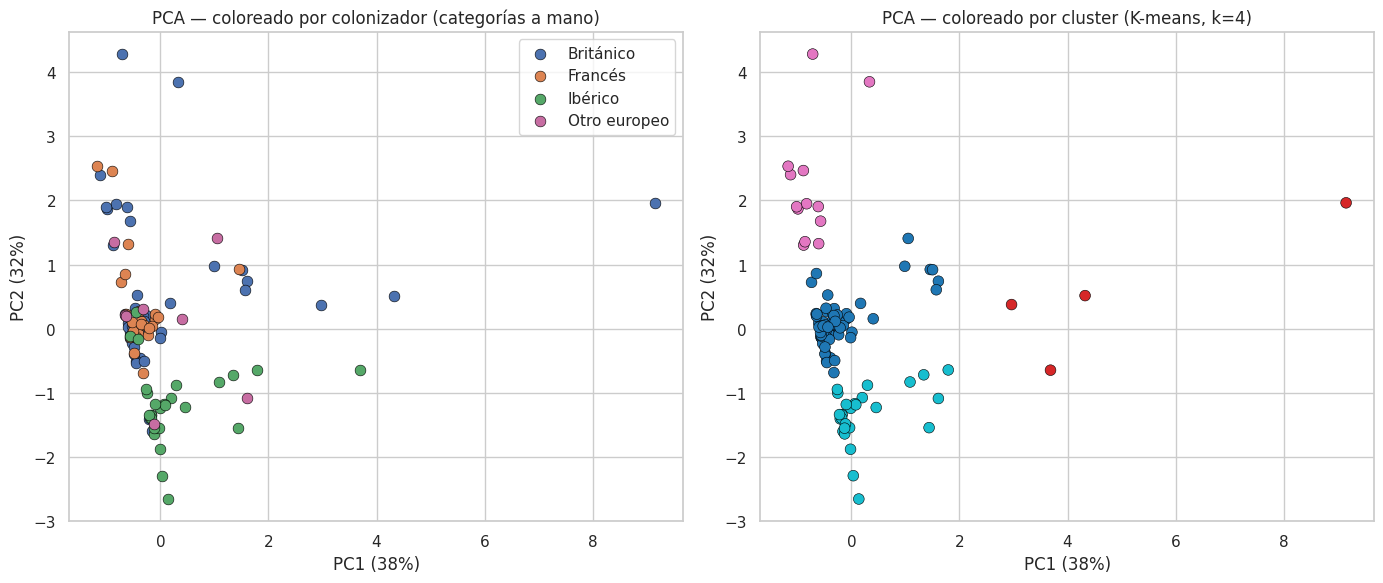

In [ ]:
# Variables utilizadas para identificar los perfiles coloniales/precoloniales.
features_cluster = ['duracion_colonial', 'sai_statehisten0', 'wdi_area', 'ross_oil_prod']

# Eliminamos países con datos faltantes en alguna de estas variables.
df_cluster = df_nivel.dropna(subset=features_cluster).copy()

print(f"[Rol4][no supervisado] N: {len(df_cluster)}")

# Estandarizamos las variables para que las diferencias de escala
# no determinen artificialmente los resultados del análisis.
X_cluster = StandardScaler().fit_transform(df_cluster[features_cluster])

# Reducimos las cuatro variables a dos componentes principales (PCA)
# para visualizar los principales ejes de variación entre países.
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_cluster)

# Indicamos qué proporción de la variabilidad total explica cada componente.
print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

# Mostramos las cargas de PC1 para identificar qué variables contribuyen
# más a ese principal eje de variación.
print("\nCargas de PC1 (qué variable pesa más en ese eje):")

display(pd.Series(pca.components_[0], index=features_cluster).sort_values(key=abs, ascending=False))

# Comparamos distintas cantidades de clusters mediante el silhouette score.
# Un valor mayor indica una separación más clara entre los grupos.
print("\n=== Silhouette score por k (2 a 6) ===")

for k in range(2, 7):

    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)

    sil = silhouette_score(X_cluster, km_k.fit_predict(X_cluster))

    print(f"  k={k}: silhouette={sil:.3f}")

# Fijamos k=4 para hacer comparable el agrupamiento con las cuatro
# categorías de colonizador definidas teóricamente.
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)

df_cluster['cluster'] = kmeans_4.fit_predict(X_cluster)

# Medimos cuánto coinciden los clusters con las categorías de colonizador.
# ARI=0 indica coincidencia equivalente al azar y ARI=1 coincidencia perfecta.
ari = adjusted_rand_score(df_cluster['colonizador_4cat'], df_cluster['cluster'])

print(f"\nAdjusted Rand Index (k=4 vs. colonizador_4cat): {ari:.3f}  (0=azar, 1=coinciden perfecto)")

# Mostramos qué categorías de colonizador quedan dentro de cada cluster.
print("\n=== Tabla cruzada: cluster vs. colonizador ===")

display(pd.crosstab(df_cluster['colonizador_4cat'], df_cluster['cluster']))

# Creamos dos gráficos: uno coloreado según las categorías de colonizador
# y otro según los clusters obtenidos por K-means.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

paleta_col = paleta_colonizador  # --- CORRECCIÓN v5 (paleta única): antes 'Otro europeo'=#C44E52, distinto del canónico #C76DA2 de la Celda 11 ---

# PCA coloreado según las categorías de colonizador definidas previamente.
for cat, color in paleta_col.items():

    mask = df_cluster['colonizador_4cat'] == cat

    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=cat, color=color, s=60, edgecolor='black', linewidth=0.4)

axes[0].set_title('PCA — coloreado por colonizador (categorías a mano)')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')

axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')

axes[0].legend()

# PCA coloreado según los cuatro clusters obtenidos por K-means.
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster['cluster'], cmap='tab10', s=60, edgecolor='black', linewidth=0.4)

axes[1].set_title('PCA — coloreado por cluster (K-means, k=4)')

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')

axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')

plt.tight_layout()

guardar('pca_clustering_colonial')

plt.show()

In [ ]:
# --- Chequeo de robustez del análisis no supervisado ---
#
# wdi_area y ross_oil_prod presentan distribuciones muy asimétricas.
# Aunque la estandarización pone las variables en una escala comparable,
# no elimina esa asimetría: valores extremos todavía pueden influir
# fuertemente sobre el PCA y K-means.
#
# Como chequeo de robustez, transformamos estas dos variables mediante
# log1p antes de estandarizarlas. Se utiliza log1p porque permite trabajar
# también con valores iguales a cero.
df_cluster_log = df_cluster.copy()
df_cluster_log['wdi_area'] = np.log1p(df_cluster_log['wdi_area'])
df_cluster_log['ross_oil_prod'] = np.log1p(df_cluster_log['ross_oil_prod'])

# Estandarizamos nuevamente las variables y repetimos el PCA.
X_cluster_log = StandardScaler().fit_transform(df_cluster_log[features_cluster])
pca_log = PCA(n_components=2, random_state=42)
X_pca_log = pca_log.fit_transform(X_cluster_log)

# Comparamos la proporción de varianza explicada por los dos primeros
# componentes con la especificación original.
print(f"[log] Varianza explicada: PC1={pca_log.explained_variance_ratio_[0]:.1%}, PC2={pca_log.explained_variance_ratio_[1]:.1%}")

# Mostramos las cargas de PC1 para evaluar si la transformación logarítmica
# modifica qué variables dominan el principal eje de variación.
print("[log] Cargas de PC1:")
display(pd.Series(pca_log.components_[0], index=features_cluster).sort_values(key=abs, ascending=False))

# Evaluamos nuevamente la calidad de la separación para distintos números
# de clusters mediante el silhouette score.
print("\n[log] === Silhouette score por k (2 a 6) ===")
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil = silhouette_score(X_cluster_log, km_k.fit_predict(X_cluster_log))
    print(f"  k={k}: silhouette={sil:.3f}")

# Repetimos K-means fijando cuatro clusters para mantener la comparación
# con las cuatro categorías de colonizador definidas previamente.
kmeans_4_log = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_log['cluster'] = kmeans_4_log.fit_predict(X_cluster_log)

# Comparamos los nuevos clusters con las categorías de colonizador mediante
# el Adjusted Rand Index (ARI), para evaluar la estabilidad de la coincidencia.
ari_log = adjusted_rand_score(df_cluster_log['colonizador_4cat'], df_cluster_log['cluster'])
print(f"\n[log] ARI (k=4 vs. colonizador): {ari_log:.3f}")

# Mostramos la correspondencia entre los clusters obtenidos y las categorías
# de colonizador después de la transformación logarítmica.
display(pd.crosstab(df_cluster_log['colonizador_4cat'], df_cluster_log['cluster']))

[log] Varianza explicada: PC1=37.7%, PC2=30.7%
[log] Cargas de PC1:


,0
ross_oil_prod,0.626931
wdi_area,0.588278
sai_statehisten0,0.433278
duracion_colonial,-0.270473



[log] === Silhouette score por k (2 a 6) ===
  k=2: silhouette=0.314
  k=3: silhouette=0.353
  k=4: silhouette=0.366
  k=5: silhouette=0.397
  k=6: silhouette=0.429

[log] ARI (k=4 vs. colonizador): 0.101


cluster,0,1,2,3
colonizador_4cat,,,,
Británico,16,2,8,24
Francés,11,0,3,12
Ibérico,12,15,0,1
Otro europeo,3,1,0,4


## 5b. Clasificación — regresión logística (Elastic Net) y Random Forest

In [ ]:
# --- Rol 4: clasificación supervisada ---

# Variable objetivo: democratizo_alguna_vez.
# El análisis utiliza las excolonias disponibles para esta variable.

# Las variables explicativas se toman de df_nivel cuando corresponden
# a características agregadas a nivel país.
df_clasif = df_paises[
    ['iso3', 'colonizador_4cat', 'democratizo_alguna_vez',
     'colend_mean', 'duracion_colonial']
].copy()

df_clasif = df_clasif.merge(
    df_nivel[['iso3', 'sai_statehisten0', 'wdi_area', 'ross_oil_prod']],
    on='iso3',
    how='left'
)


# Clasificamos los países según el momento de su independencia.
df_clasif['era'] = np.where(
    df_clasif['colend_mean'] < 1945,
    'pre-1945',
    'post-1945'
)


# Comprobamos que la variable histórica esté disponible en la base final.
print(
    f"[Rol4] Comparación de faltantes — sai_statehisten0: "
    f"df_paises={df_paises['sai_statehisten0'].isna().sum()} "
    f"vs. df_nivel={df_clasif['sai_statehisten0'].isna().sum()}"
)


# Transformamos las variables categóricas en variables dummy.
# No eliminamos ninguna categoría en esta etapa porque seleccionamos
# explícitamente las categorías que utilizaremos como predictores.
df_clasif_dummies = pd.get_dummies(
    df_clasif,
    columns=['colonizador_4cat', 'era'],
    drop_first=False,
    dtype=int
)


# Conjunto de predictores utilizados en ambos modelos de clasificación.
features = [
    'colonizador_4cat_Francés',
    'colonizador_4cat_Ibérico',
    'colonizador_4cat_Otro europeo',
    'era_pre-1945',
    'duracion_colonial',
    'sai_statehisten0',
    'wdi_area',
    'ross_oil_prod'
]


# Eliminamos las observaciones que presentan datos faltantes
# en la variable dependiente o en alguno de los predictores.
df_clasif_clean = df_clasif_dummies.dropna(
    subset=features + ['democratizo_alguna_vez']
).copy()

print(
    f"[Rol4] N: {len(df_clasif_clean)} | "
    f"democratizaron: {df_clasif_clean['democratizo_alguna_vez'].sum()} | "
    f"nunca: {(df_clasif_clean['democratizo_alguna_vez'] == 0).sum()}"
)


# Estandarizamos únicamente las variables continuas.
# Esto evita que las diferencias de escala afecten especialmente
# a la regresión logística regularizada.
cols_continuas = [
    'duracion_colonial',
    'sai_statehisten0',
    'wdi_area',
    'ross_oil_prod'
]

X_df = df_clasif_clean[features].copy()

X_df[cols_continuas] = StandardScaler().fit_transform(
    X_df[cols_continuas]
)

X = X_df.values
y = df_clasif_clean['democratizo_alguna_vez'].values


# Utilizamos validación cruzada estratificada para mantener una
# proporción similar de casos positivos y negativos en cada partición.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# --- Modelo 1: regresión logística con Elastic Net ---

# Elastic Net combina regularización L1 y L2.
# La intensidad de la regularización y la proporción L1/L2
# se seleccionan mediante validación cruzada.
logit_en = LogisticRegressionCV(
    Cs=10,
    cv=cv,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.0, 0.25, 0.5, 0.75, 1.0],
    scoring='roc_auc',
    max_iter=5000,
    random_state=42
)


# Evaluamos la capacidad predictiva fuera de muestra mediante
# validación cruzada de cinco particiones.
auc_logit = cross_val_score(
    logit_en,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)


# Una vez seleccionada la configuración óptima, ajustamos el modelo
# utilizando toda la muestra.
logit_en.fit(X, y)


# --- Modelo 2: Random Forest ---

# Utilizamos un conjunto de árboles con profundidad máxima y tamaño
# mínimo de hoja restringidos para limitar el riesgo de sobreajuste.
rf_clasif = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)


# Evaluamos la capacidad predictiva del Random Forest mediante
# la misma validación cruzada estratificada.
auc_rf = cross_val_score(
    rf_clasif,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)


# Ajustamos el Random Forest final utilizando toda la muestra.
rf_clasif.fit(X, y)


# Comparamos el desempeño predictivo promedio de ambos modelos.
# AUC = 0.5 corresponde aproximadamente a clasificación aleatoria;
# valores más altos indican mayor capacidad de discriminación.
print("\n=== AUC-ROC validado por CV (5-fold estratificado) ===")
print(
    f"Logística (Elastic Net): "
    f"{auc_logit.mean():.3f} (± {auc_logit.std():.3f})"
)
print(
    f"Random Forest:           "
    f"{auc_rf.mean():.3f} (± {auc_rf.std():.3f})"
)


# En la regresión logística, transformamos los coeficientes
# en odds ratios para facilitar su interpretación.

# OR > 1: mayores odds del resultado.
# OR < 1: menores odds del resultado.
print("\n=== Odds ratios — logística ===")

display(
    pd.DataFrame({
        'variable': features,
        'odds_ratio': np.exp(logit_en.coef_[0])
    }).sort_values(
        'odds_ratio',
        ascending=False
    )
)


# --- Importancia por permutación ---

# Evaluamos cuánto disminuye el desempeño predictivo del Random Forest
# cuando cada variable es permutada.

# Una caída mayor indica que la variable aporta más información
# para la capacidad predictiva del modelo.

# Usamos importancia por permutación en lugar de la importancia
# nativa del Random Forest.
perm = permutation_importance(
    rf_clasif,
    X,
    y,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc'
)

print("\n=== Importancia por permutación — Random Forest ===")

display(
    pd.DataFrame({
        'variable': features,
        'importancia': perm.importances_mean
    }).sort_values(
        'importancia',
        ascending=False
    )
)

[Rol4] Comparación de faltantes — sai_statehisten0: df_paises=0 vs. df_nivel=0
[Rol4] N: 112 | democratizaron: 67 | nunca: 45

=== AUC-ROC validado por CV (5-fold estratificado) ===
Logística (Elastic Net): 0.761 (± 0.084)
Random Forest:           0.740 (± 0.087)

=== Odds ratios — logística ===


,variable,odds_ratio
4,duracion_colonial,1.468550
3,era_pre-1945,1.202873
6,wdi_area,1.173012
1,colonizador_4cat_Ibérico,1.070955
2,colonizador_4cat_Otro europeo,0.970387
7,ross_oil_prod,0.947236
0,colonizador_4cat_Francés,0.798508
5,sai_statehisten0,0.788111



=== Importancia por permutación — Random Forest ===


,variable,importancia
4,duracion_colonial,0.130404
0,colonizador_4cat_Francés,0.046556
7,ross_oil_prod,0.036285
3,era_pre-1945,0.032548
6,wdi_area,0.031012
5,sai_statehisten0,0.026921
1,colonizador_4cat_Ibérico,0.003074
2,colonizador_4cat_Otro europeo,0.002045


In [ ]:
# --- Modelo 3: Support Vector Machine (SVM) con kernel RBF ---
#
# El kernel RBF permite capturar relaciones no lineales entre los
# predictores y la probabilidad de democratización.
svm_clasif = SVC(
    kernel='rbf',
    random_state=42
)


# Evaluamos la capacidad predictiva fuera de muestra mediante
# la misma validación cruzada estratificada utilizada en los
# modelos anteriores.
#
# No necesitamos probability=True porque roc_auc puede utilizar
# directamente la función de decisión del SVM.
auc_svm = cross_val_score(
    svm_clasif,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)


# Mostramos el AUC-ROC promedio y su desviación estándar
# entre las cinco particiones de la validación cruzada.
print(
    f"SVM (RBF): {auc_svm.mean():.3f} (± {auc_svm.std():.3f})"
)

SVM (RBF): 0.743 (± 0.126)


# Anexo 1 — Modelos de supervivencia (Cox, Andersen-Gill, logit discreto)
Especificaciones alternativas de la Etapa B. No son el resultado central del informe — el logit fraccional sobre nivel es el modelo principal.

In [ ]:
# ==========================================
# Supervivencia democrática por colonizador: mediana KM y RMST
# (NO el promedio simple de 'duration' — la censura lo subestima)
# ==========================================
kmf_resumen = KaplanMeierFitter()
horizonte = df_supervivencia_single['duration'].max()
resumen_km = []

for col in sorted(df_supervivencia_single['colonizador_4cat'].dropna().unique()):
    sub = df_supervivencia_single[df_supervivencia_single['colonizador_4cat'] == col]
    if len(sub) < 3:
        print(f"[aviso] {col}: N={len(sub)}, muy chico para KM confiable, se omite.")
        continue
    try:
        kmf_resumen.fit(durations=sub['duration'], event_observed=sub['event'], entry=sub['entry'])
        mediana = kmf_resumen.median_survival_time_
        rmst = restricted_mean_survival_time(kmf_resumen, t=horizonte)
    except Exception as e:
        mediana, rmst = np.nan, np.nan
        print(f"[aviso] {col}: KM no estimable con este N/censura ({e})")
    resumen_km.append({'colonizador': col, 'n': len(sub),
                        'mediana_supervivencia_KM': mediana, 'rmst': rmst})

tabla_km = pd.DataFrame(resumen_km)
print("\n=== Supervivencia democrática por colonizador (mediana KM y RMST) ===")
print("[nota][v4] mediana_supervivencia_KM y rmst están en años DESDE LA INDEPENDENCIA")
print("[nota][v4] (con entrada diferida al año de democratización), no años desde la democratización.")
dfi.export(tabla_km, f'{carpeta_figuras}/tabla_km_mediana_rmst.png', table_conversion='matplotlib')
display(tabla_km)

media_cruda = df_supervivencia_single.groupby('colonizador_4cat')['duration'].mean().round(1)
print("\n(referencia, NO usar para reportar) Media cruda de 'duration', subestimada por censura:")
print(media_cruda)

[aviso] Británico: KM no estimable con este N/censura (name 'restricted_mean_survival_time' is not defined)
[aviso] Francés: KM no estimable con este N/censura (name 'restricted_mean_survival_time' is not defined)
[aviso] Ibérico: KM no estimable con este N/censura (There are too few early truncation times and too many events. S(t)==0 for all t>51. Recommend BreslowFlemingHarringtonFitter.)
[aviso] Otro europeo: KM no estimable con este N/censura (There are too few early truncation times and too many events. S(t)==0 for all t>6. Recommend BreslowFlemingHarringtonFitter.)

=== Supervivencia democrática por colonizador (mediana KM y RMST) ===
[nota][v4] mediana_supervivencia_KM y rmst están en años DESDE LA INDEPENDENCIA
[nota][v4] (con entrada diferida al año de democratización), no años desde la democratización.


,colonizador,n,mediana_supervivencia_KM,rmst
0,Británico,29,NaN,NaN
1,Francés,8,NaN,NaN
2,Ibérico,23,NaN,NaN
3,Otro europeo,3,NaN,NaN



(referencia, NO usar para reportar) Media cruda de 'duration', subestimada por censura:
colonizador_4cat
Británico        65.8
Francés          54.2
Ibérico         158.0
Otro europeo     58.0
Name: duration, dtype: float64


[v2][aviso] No se pudo estimar KM para 'Ibérico' (N=23): There are too few early truncation times and too many events. S(t)==0 for all t>51. Recommend BreslowFlemingHarringtonFitter.
[v2][aviso] No se pudo estimar KM para 'Otro europeo' (N=3): There are too few early truncation times and too many events. S(t)==0 for all t>6. Recommend BreslowFlemingHarringtonFitter.
[ok] guardada: km_etapaB_por_colonizador.png


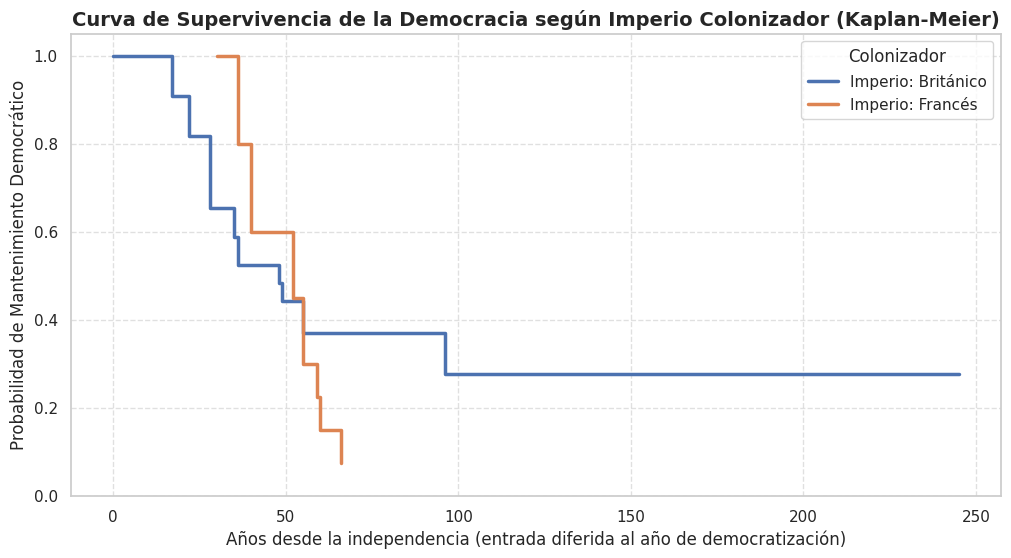


=== PRUEBA DE LOG-RANK (Británico vs. Ibérico) ===
p-valor: 0.00007
Conclusión: Existe una diferencia estadísticamente significativa en la supervivencia de las democracias según el colonizador.


In [ ]:
# --- CORRECCIÓN v4: el eje de tiempo es años desde la independencia (con entrada diferida
# al año de democratización) — así se construyeron 'duration' y 'entry' en la celda de
# construcción de la Etapa B. Antes el eje decía 'años desde la democratización', que no
# coincide con ese reloj y podía llevar a leer mal la mediana y el log-rank. ---
# Configuración del gráfico
plt.figure(figsize=(12, 6))
kmf = KaplanMeierFitter()

imperios_principales = ['Británico', 'Ibérico', 'Francés', 'Otro europeo']

for imperio in imperios_principales:
    mask = df_supervivencia_single['colonizador_4cat'] == imperio
    try:
        kmf.fit(
            durations=df_supervivencia_single.loc[mask, 'duration'],
            event_observed=df_supervivencia_single.loc[mask, 'event'],
            entry=df_supervivencia_single.loc[mask, 'entry'],
            label=f"Imperio: {imperio}"
        )
        kmf.plot_survival_function(ci_show=False, linewidth=2.5)
    except Exception as e:
        print(f"[v2][aviso] No se pudo estimar KM para '{imperio}' (N={mask.sum()}): {e}")

plt.title('Curva de Supervivencia de la Democracia según Imperio Colonizador (Kaplan-Meier)', fontsize=14, fontweight='bold')
plt.xlabel('Años desde la independencia (entrada diferida al año de democratización)', fontsize=12)
plt.ylabel('Probabilidad de Mantenimiento Democrático', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Colonizador', fontsize=11)
guardar('km_etapaB_por_colonizador')
plt.show()

datos_britain = df_supervivencia_single[df_supervivencia_single['colonizador_4cat'] == 'Británico']
datos_iberico = df_supervivencia_single[df_supervivencia_single['colonizador_4cat'] == 'Ibérico']

resultado_test = logrank_test(
    datos_britain['duration'], datos_iberico['duration'],
    event_observed_a=datos_britain['event'], event_observed_b=datos_iberico['event']
)

print("\n=== PRUEBA DE LOG-RANK (Británico vs. Ibérico) ===")
print(f"p-valor: {resultado_test.p_value:.5f}")
if resultado_test.p_value < 0.05:
    print("Conclusión: Existe una diferencia estadísticamente significativa en la supervivencia de las democracias según el colonizador.")
else:
    print("Conclusión: No se observa una diferencia estadísticamente significativa en la vida media democrática entre ambos imperios.")

[Rol2] N: 60 | eventos: 29

=== COX ESTRATIFICADO POR ERA — ESPECIFICACIÓN FINAL (con duracion_colonial) ===


<lifelines.CoxPHFitter: fitted with 60 total observations, 31 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                entry col = 'entry'
                   strata = era
      baseline estimation = breslow
   number of observations = 60
number of events observed = 29
   partial log-likelihood = -57.35
         time fit was run = 2026-08-25 01:17:11 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
colonizador_4cat_Francés  0.53      1.70      0.60           -0.65            1.71                0.52                5.53
colonizador_4cat_Ibérico  3.29     26.82      1.62            0.11            6.46                1.12              641.09
duracion_colonial        -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
sai_statehisten0         -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
wdi_area                 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ross_oil_prod            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                          cmp to     z    p  -log2(p)
covariate                                            
colonizador_4cat_Francés    0.00  0.88 0.38      1.40
colonizador_4cat_Ibérico    0.00  2.03 0.04      4.56
duracion_colonial           0.00 -2.80 0.01      7.63
sai_statehisten0            0.00 -2.28 0.02      5.47
wdi_area                    0.00 -0.77 0.44      1.19
ross_oil_prod               0.00 -0.30 0.76      0.39
---
Concordance = 0.64
Partial AIC = 126.70
log-likelihood ratio test = 19.56 on 6 df
-log2(p) of ll-ratio test = 8.24

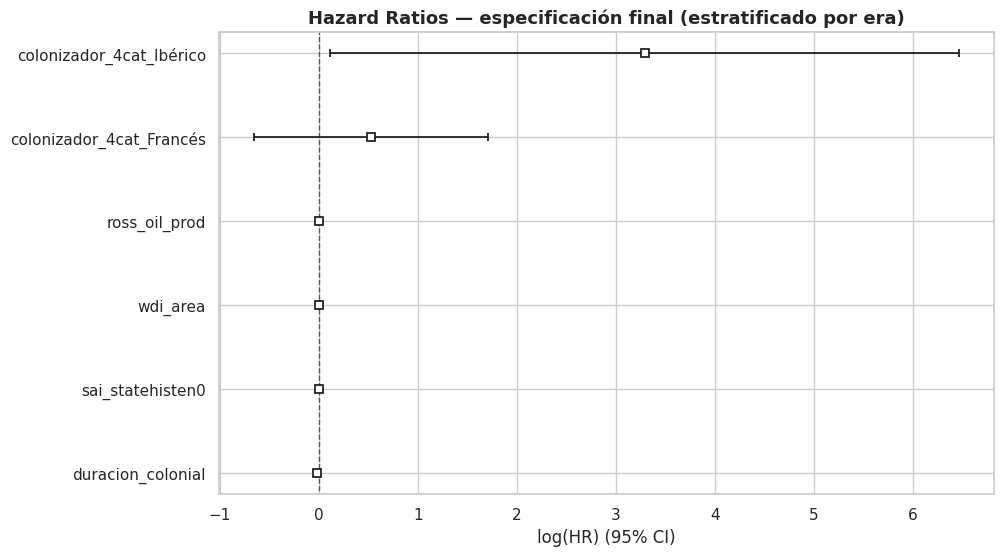


=== CHEQUEO DE PROPORCIONALIDAD, especificación final (con estrato 'era') ===
  colonizador_4cat_Francés       p interacción = 0.476  [ok]
  colonizador_4cat_Ibérico       p interacción = 0.563  [ok]
  duracion_colonial              p interacción = 0.622  [ok]


/usr/local/lib/python3.13/dist-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning:

Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model



  sai_statehisten0               p interacción = 0.122  [ok]
  wdi_area                       p interacción = 0.068  [ok]
  ross_oil_prod                  p interacción = 0.480  [ok]


In [ ]:
#Modelo de supervivencia de COX

df_supervivencia_single['era'] = np.where(
    df_supervivencia_single['independencia'] < 1945, 'pre-1945', 'post-1945'
)

df_cox = pd.get_dummies(df_supervivencia_single, columns=['colonizador_4cat'], drop_first=False, dtype=int)
# 'Otro europeo' (Bélgica/Alemania/Italia/Países Bajos, N chico) se excluye de los modelos
# multivariados por el mismo motivo que en el descriptivo (secciones 7.6/7.9 y la nube KDE):
# con tan pocos casos, sus intervalos de confianza no son interpretables.
df_cox_principal = df_cox[df_cox['colonizador_4cat_Otro europeo'] == 0].copy()

variables_modelo = [
    'entry', 'duration', 'event', 'era',
    'colonizador_4cat_Francés', 'colonizador_4cat_Ibérico',
    'duracion_colonial', 'sai_statehisten0', 'wdi_area', 'ross_oil_prod'
]
df_cox_clean = df_cox_principal[variables_modelo].dropna().copy()
print(f"[Rol2] N: {len(df_cox_clean)} | eventos: {int(df_cox_clean['event'].sum())}")

cph = CoxPHFitter()
cph.fit(df_cox_clean, duration_col='duration', event_col='event', entry_col='entry', strata=['era'])

print("\n=== COX ESTRATIFICADO POR ERA — ESPECIFICACIÓN FINAL (con duracion_colonial) ===")
cph.print_summary()
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Hazard Ratios — especificación final (estratificado por era)', fontsize=13, fontweight='bold')
plt.show()

# Re-chequeo COMPLETO de proporcionalidad — esta vez las 6 covariables, no solo la que
# había fallado antes. No volvemos a asumir sin chequear.
print("\n=== CHEQUEO DE PROPORCIONALIDAD, especificación final (con estrato 'era') ===")
covariables_a_testear = [c for c in variables_modelo if c not in ['entry', 'duration', 'event', 'era']]
df_ph = df_cox_clean.copy()
df_ph['log_duration'] = np.log(df_ph['duration'])

for covar in covariables_a_testear:
    df_temp = df_ph.copy()
    df_temp[f'{covar}_x_logt'] = df_temp[covar] * df_temp['log_duration']
    cols_temp = ['entry', 'duration', 'event', 'era'] + covariables_a_testear + [f'{covar}_x_logt']
    try:
        cph_temp = CoxPHFitter()
        cph_temp.fit(df_temp[cols_temp], duration_col='duration', event_col='event', entry_col='entry', strata=['era'])
        p_interaccion = cph_temp.summary.loc[f'{covar}_x_logt', 'p']
        bandera = "VIOLA PH" if p_interaccion < 0.05 else "ok"
        print(f"  {covar:30s} p interacción = {p_interaccion:.3f}  [{bandera}]")
    except Exception as e:
        print(f"  {covar:30s} no se pudo estimar ({e})")

[Rol2][recurrente] N episodios: 98 | eventos: 38 | países únicos: 61

=== COX RECURRENTE (Andersen-Gill) — especificación final ===


model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
entry col,'entry'
cluster col,'iso3'
robust variance,True
strata,era
baseline estimation,breslow
number of observations,98
number of events observed,38
partial log-likelihood,-86.85


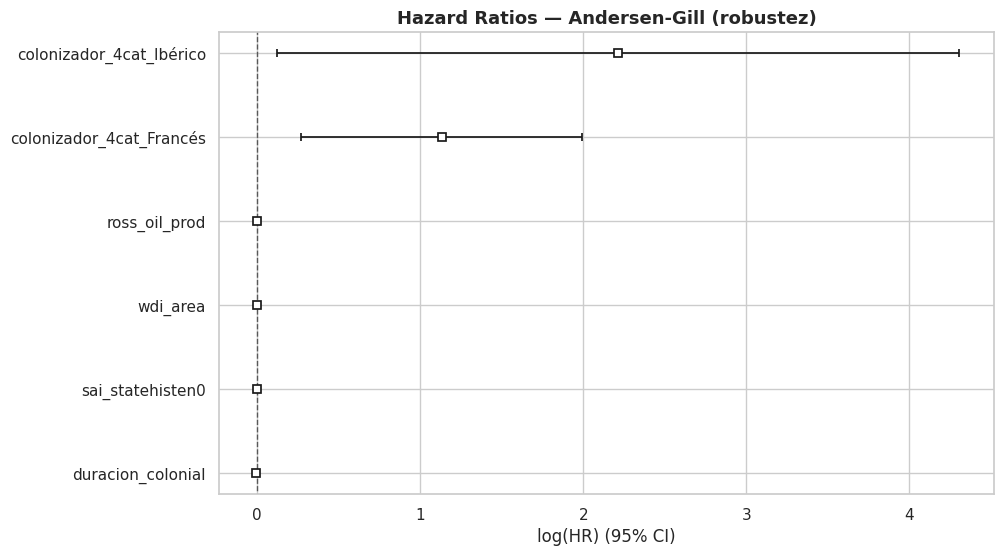

In [ ]:
# 5. Modelo de supervivencia Andersen-Gill
#Misma especificación que el modelo de COX, pero con episodios recurrentes y errores agrupados por país.
df_supervivencia['era'] = np.where(
    df_supervivencia['independencia'] < 1945, 'pre-1945', 'post-1945'
)

df_cox_rec = pd.get_dummies(df_supervivencia, columns=['colonizador_4cat'], drop_first=False, dtype=int)
# Mismo criterio que en el Cox principal: se excluye 'Otro europeo' por N chico.
df_cox_rec_principal = df_cox_rec[df_cox_rec['colonizador_4cat_Otro europeo'] == 0].copy()

variables_modelo_rec = [
    'iso3', 'entry', 'duration', 'event', 'era',
    'colonizador_4cat_Francés', 'colonizador_4cat_Ibérico',
    'duracion_colonial', 'sai_statehisten0', 'wdi_area', 'ross_oil_prod'
]
df_cox_rec_clean = df_cox_rec_principal[variables_modelo_rec].dropna().copy()
print(f"[Rol2][recurrente] N episodios: {len(df_cox_rec_clean)} | eventos: {int(df_cox_rec_clean['event'].sum())} | países únicos: {df_cox_rec_clean['iso3'].nunique()}")

cph_rec = CoxPHFitter()
cph_rec.fit(df_cox_rec_clean, duration_col='duration', event_col='event', entry_col='entry', cluster_col='iso3', strata=['era'])

print("\n=== COX RECURRENTE (Andersen-Gill) — especificación final ===")
cph_rec.print_summary()
plt.figure(figsize=(10, 6))
cph_rec.plot()
plt.title('Hazard Ratios — Andersen-Gill (robustez)', fontsize=13, fontweight='bold')
plt.show()

In [ ]:
#Logit discreto (Beck, Katz & Tucker 1998)
#Misma pregunta (riesgo de quiebre), reformulada como panel país-año.

df_panel = df_etapaB.copy()
df_panel['era'] = np.where(df_panel['colend_mean'] < 1945, 'pre-1945', 'post-1945')
df_panel['anio_inicio_episodio_actual'] = df_panel.groupby(['iso3', 'episodio_id'])['year'].transform('min')
df_panel['t_en_riesgo'] = df_panel['year'] - df_panel['anio_inicio_episodio_actual']

# Mismo criterio que en los modelos de Cox: se excluye 'Otro europeo' por N chico.
df_panel_principal = df_panel[df_panel['colonizador_4cat'] != 'Otro europeo'].copy()

variables_panel = [
    'iso3', 'es_quiebre', 'colonizador_4cat', 'era', 'duracion_colonial',
    'sai_statehisten0', 'wdi_area', 'ross_oil_prod', 't_en_riesgo'
]
df_panel_clean = df_panel_principal[variables_panel].dropna().copy()

print(f"[Rol2][logit discreto] N país-año: {len(df_panel_clean)} | quiebres: {int(df_panel_clean['es_quiebre'].sum())} | países únicos: {df_panel_clean['iso3'].nunique()}")

df_panel_clean['t_en_riesgo_sq'] = df_panel_clean['t_en_riesgo'] ** 2
modelo_logit = smf.logit(
    'es_quiebre ~ C(colonizador_4cat, Treatment(reference="Británico")) '
    '+ C(era, Treatment(reference="post-1945")) '
    '+ duracion_colonial + sai_statehisten0 + wdi_area + ross_oil_prod '
    '+ t_en_riesgo + t_en_riesgo_sq',
    data=df_panel_clean
).fit(cov_type='cluster', cov_kwds={'groups': df_panel_clean['iso3']})

print("\n=== MODELO DE DURACIÓN EN TIEMPO DISCRETO (Beck, Katz & Tucker 1998) ===")
print(modelo_logit.summary())

print("\n=== Odds ratios (análogo a hazard ratios) ===")
odds_ratios = np.exp(modelo_logit.params)
ic = np.exp(modelo_logit.conf_int())
tabla_or = pd.DataFrame({'odds_ratio': odds_ratios.round(3), 'IC_2.5%': ic[0].round(3),
                          'IC_97.5%': ic[1].round(3), 'p': modelo_logit.pvalues.round(3)})
display(tabla_or)

[Rol2][logit discreto] N país-año: 2395 | quiebres: 38 | países únicos: 63
Optimization terminated successfully.
         Current function value: 0.073704
         Iterations 11

=== MODELO DE DURACIÓN EN TIEMPO DISCRETO (Beck, Katz & Tucker 1998) ===
                           Logit Regression Results                           
Dep. Variable:             es_quiebre   No. Observations:                 2395
Model:                          Logit   Df Residuals:                     2385
Method:                           MLE   Df Model:                            9
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                 0.09547
Time:                        01:17:13   Log-Likelihood:                -176.52
converged:                       True   LL-Null:                       -195.15
Covariance Type:              cluster   LLR p-value:                 2.363e-05
                                                                       coef    std err          z      P>|z|      [0

,odds_ratio,IC_2.5%,IC_97.5%,p
Intercept,0.042,0.019,0.096,0.000
"C(colonizador_4cat, Treatment(reference=""Británico""))[T.Francés]",3.338,1.464,7.611,0.004
"C(colonizador_4cat, Treatment(reference=""Británico""))[T.Ibérico]",13.497,4.977,36.607,0.000
"C(era, Treatment(reference=""post-1945""))[T.pre-1945]",0.394,0.162,0.960,0.040
duracion_colonial,0.990,0.985,0.995,0.000
sai_statehisten0,0.999,0.998,1.000,0.142
wdi_area,1.000,1.000,1.000,0.362
ross_oil_prod,1.000,1.000,1.000,0.756
t_en_riesgo,1.053,0.997,1.113,0.065
t_en_riesgo_sq,0.999,0.998,1.000,0.064


# Anexo 2 — Verificaciones metodológicas
Comparación de reglas de colonizador y diagnóstico de la construcción de la Etapa B. Documentan decisiones de diseño ya tomadas, no resultados de investigación.

In [ ]:
# ==========================================
# CASOS MULTICOLONIZADOR: comparación de reglas de asignación
# ==========================================
# Comparamos dos reglas para asignar el colonizador principal en países
# con más de un registro en COLDAT:
# (1) el episodio de mayor duración y
# (2) el episodio más reciente, según la fecha de finalización.

casos_multicolonizador = df_coldat_filtrado.groupby('iso3').filter(lambda x: len(x) > 1)
print(f"Países con más de un colonizador en COLDAT: {casos_multicolonizador['iso3'].nunique()}")

# Regla 1: selecciona el episodio colonial de mayor duración.
regla_duracion = (
    df_coldat_filtrado.sort_values('duracion_colonial', ascending=False)
    .drop_duplicates(subset=['iso3'], keep='first')
    [['iso3', 'colonizer', 'colstart_mean', 'colend_mean', 'duracion_colonial']]
    .rename(columns={'colonizer': 'colonizador_por_duracion', 'colend_mean': 'fin_por_duracion'})
)

# Regla 2: selecciona el episodio colonial que terminó más recientemente.
regla_ultimo = (
    df_coldat_filtrado.sort_values('colend_mean', ascending=False)
    .drop_duplicates(subset=['iso3'], keep='first')
    [['iso3', 'colonizer', 'colstart_mean', 'colend_mean']]
    .rename(columns={'colonizer': 'colonizador_por_ultimo', 'colend_mean': 'fin_por_ultimo'})
)

# Unimos ambas asignaciones para identificar los países en los que las reglas difieren.
comparacion = (
    casos_multicolonizador[['iso3']].drop_duplicates()
    .merge(regla_duracion, on='iso3')
    .merge(regla_ultimo, on='iso3')
)

comparacion['coinciden'] = (
    comparacion['colonizador_por_duracion'] ==
    comparacion['colonizador_por_ultimo']
)

print(f"\nCasos donde las dos reglas DISCREPAN: {(~comparacion['coinciden']).sum()} de {len(comparacion)}")
display(comparacion.sort_values('coinciden'))

# Comparamos las dos reglas anteriores con la regla híbrida utilizada
# finalmente para construir la variable de colonizador.
regla_hibrida = df_coldat_clean[
    ['iso3', 'colonizer', 'colend_mean', 'duracion_colonial']
].rename(
    columns={
        'colonizer': 'colonizador_por_hibrida',
        'colend_mean': 'fin_por_hibrida'
    }
)

comparacion = comparacion.merge(regla_hibrida, on='iso3', how='left')

# Este chequeo permite revisar qué colonizador selecciona la regla híbrida
# y comparar la fecha de finalización elegida con la independencia real.
print(
    f"\n=== Regla híbrida (umbral {UMBRAL_MANDATO_BREVE} años) "
    "— revisión de la asignación ==="
)

display(
    comparacion[
        ['iso3',
         'colonizador_por_duracion', 'fin_por_duracion',
         'colonizador_por_ultimo', 'fin_por_ultimo',
         'colonizador_por_hibrida', 'fin_por_hibrida']
    ].sort_values('iso3')
)

Países con más de un colonizador en COLDAT: 32

Casos donde las dos reglas DISCREPAN: 13 de 32


,iso3,colonizador_por_duracion,colstart_mean_x,fin_por_duracion,duracion_colonial,colonizador_por_ultimo,colstart_mean_y,fin_por_ultimo,coinciden
9,GUY,netherlands,1580.0,1815.0,235.0,britain,1814.0,1966.0,False
2,BLZ,spain,1524.0,1862.0,338.0,britain,1798.0,1980.0,False
3,CAN,france,1608.0,1763.0,155.0,britain,1737.0,1877.0,False
16,WSM,germany,1900.0,1914.0,14.0,britain,1914.0,1920.0,False
23,LCA,france,1650.0,1814.0,164.0,britain,1814.0,1973.0,False
6,ERI,italy,1885.0,1940.0,55.0,britain,1941.0,1951.0,False
7,GHA,portugal,1476.0,1823.0,347.0,britain,1874.0,1957.0,False
26,VUT,france,1887.0,1980.0,93.0,britain,1906.0,1980.0,False
21,ZAF,netherlands,1652.0,1806.0,154.0,britain,1801.0,1912.0,False
25,TTO,spain,1592.0,1797.0,205.0,britain,1797.0,1962.0,False



=== Regla híbrida (umbral 20 años) — revisión de la asignación ===


,iso3,colonizador_por_duracion,fin_por_duracion,colonizador_por_ultimo,fin_por_ultimo,colonizador_por_hibrida,fin_por_hibrida
0,BDI,belgium,1962.0,belgium,1962.0,belgium,1962.0
2,BLZ,spain,1862.0,britain,1980.0,britain,1980.0
3,CAN,france,1763.0,britain,1877.0,britain,1877.0
27,CMR,france,1960.0,france,1960.0,france,1960.0
4,DMA,britain,1972.0,britain,1972.0,britain,1972.0
6,ERI,italy,1940.0,britain,1951.0,italy,1951.0
7,GHA,portugal,1823.0,britain,1957.0,britain,1957.0
5,GNQ,spain,1968.0,spain,1968.0,spain,1968.0
8,GRD,britain,1970.0,britain,1970.0,britain,1970.0
9,GUY,netherlands,1815.0,britain,1966.0,britain,1966.0


In [ ]:
# Diagnóstico: identificamos qué episodios quedan fuera del análisis de Etapa B
# y si el motivo es que comienzan antes de la independencia o no tienen duración válida.

df_diag_b = df_etapaB.groupby(['iso3', 'colonizer', 'colonizador_4cat', 'episodio_id']).agg(
    anio_inicio_episodio=('year', 'min'),
    anio_fin_episodio=('year', 'max'),
    event=('es_quiebre', 'max'),
    independencia=('colend_mean', 'first'),
).reset_index()

# Calculamos el tiempo desde la independencia hasta el inicio y el final
# de cada episodio. Estos valores determinan si el episodio puede entrar
# correctamente en el modelo de supervivencia.
df_diag_b['entry'] = df_diag_b['anio_inicio_episodio'] - df_diag_b['independencia']
df_diag_b['duration'] = df_diag_b['anio_fin_episodio'] - df_diag_b['independencia']

# Identificamos los episodios con entrada negativa o con duración que no
# supera el momento de entrada, que son los que descarta el filtro actual.
descartados_b = df_diag_b[
    (df_diag_b['entry'] < 0) |
    (df_diag_b['duration'] <= df_diag_b['entry'])
]

print(f"Episodios que el filtro actual de la Etapa B descarta: {len(descartados_b)}")

# Mostramos los casos descartados para revisar individualmente el motivo.
display(
    descartados_b[
        ['iso3', 'colonizador_4cat', 'independencia',
         'anio_inicio_episodio', 'anio_fin_episodio',
         'entry', 'duration']
    ]
)

Episodios que el filtro actual de la Etapa B descarta: 12


,iso3,colonizador_4cat,independencia,anio_inicio_episodio,anio_fin_episodio,entry,duration
3,AUS,Británico,1904.0,1900,2025,-4.0,121.0
11,BRB,Británico,1966.0,1960,2025,-6.0,59.0
29,GHA,Británico,1957.0,1980,1980,23.0,23.0
37,GUY,Británico,1966.0,2025,2025,59.0,59.0
45,JAM,Británico,1962.0,1956,1976,-6.0,14.0
50,LBY,Otro europeo,1952.0,2013,2013,61.0,61.0
55,LSO,Británico,1966.0,1993,1993,27.0,27.0
58,MDG,Francés,1960.0,2008,2008,48.0,48.0
65,MUS,Británico,1968.0,2025,2025,57.0,57.0
75,NGA,Británico,1960.0,2025,2025,65.0,65.0


In [ ]:
# --- Verificación puntual: cantidad de quiebres de Argentina ---

# 1) Contamos los años marcados como quiebre en el panel país-año.
# Sirve para comprobar directamente qué observaciones de Argentina
# fueron identificadas como eventos.
arg_quiebres_panel = df_etapaB[
    (df_etapaB['iso3'] == 'ARG') & (df_etapaB['es_quiebre'] == 1)
][['iso3', 'country_name', 'year', 'aut_ep_start_year', 'aut_ep_outcome_agg', 'episodio_id']]

print(f"Quiebres de Argentina según df_etapaB (es_quiebre==1): {len(arg_quiebres_panel)}")
display(arg_quiebres_panel)


# 2) Comprobamos los eventos en la base de supervivencia.
# Cada episodio aporta como máximo un evento, por lo que la suma de
# 'event' permite verificar la cantidad de quiebres registrada allí.
arg_supervivencia = df_supervivencia[df_supervivencia['iso3'] == 'ARG']

print(f"Episodios democráticos de Argentina en df_supervivencia: {len(arg_supervivencia)}")
print(f"Quiebres de Argentina según df_supervivencia (suma de event): {arg_supervivencia['event'].sum()}")

display(
    arg_supervivencia[
        ['iso3', 'episodio_id', 'anio_inicio_episodio',
         'anio_fin_episodio', 'entry', 'duration', 'event']
    ]
)

Quiebres de Argentina según df_etapaB (es_quiebre==1): 1


,iso3,country_name,year,aut_ep_start_year,aut_ep_outcome_agg,episodio_id
1,ARG,Argentina,1965,1966.0,0.0,1


Episodios democráticos de Argentina en df_supervivencia: 3
Quiebres de Argentina según df_supervivencia (suma de event): 1


,iso3,episodio_id,anio_inicio_episodio,anio_fin_episodio,entry,duration,event
0,ARG,1,1964,1965,146.0,148.0,1
1,ARG,2,1974,1975,156.0,158.0,0
2,ARG,3,1984,2025,166.0,208.0,0


In [ ]:
# --- Diagnóstico: episodios que terminan en categoría 3 de ERT ---

# Buscamos episodios considerados "en riesgo" cuyo año siguiente a la
# finalización aparece con categoría 3. Estos casos permiten identificar
# posibles transiciones que no fueron clasificadas como quiebres bajo
# la regla actual.

candidatos_cat3 = []

for _, row in df_supervivencia.iterrows():

    # Revisamos la observación inmediatamente posterior al final del episodio.
    anio_posterior = row['anio_fin_episodio'] + 1

    match = df_final[
        (df_final['iso3'] == row['iso3']) &
        (df_final['year'] == anio_posterior) &
        (df_final['aut_ep_outcome_agg'] == 3)
    ]

    # Si existe una observación con categoría 3, guardamos el episodio
    # para revisar si fue considerado o no como quiebre.
    if len(match) > 0:
        candidatos_cat3.append({
            'iso3': row['iso3'],
            'colonizador_4cat': row['colonizador_4cat'],
            'anio_fin_episodio': row['anio_fin_episodio'],
            'event_actual_en_df_supervivencia': row['event']
        })

df_candidatos_cat3 = pd.DataFrame(candidatos_cat3)

print(
    f"Episodios 'en riesgo' que terminan en categoría 3 "
    f"(no contados como quiebre bajo la regla actual): {len(df_candidatos_cat3)}"
)

display(df_candidatos_cat3)

Episodios 'en riesgo' que terminan en categoría 3 (no contados como quiebre bajo la regla actual): 8


,iso3,colonizador_4cat,anio_fin_episodio,event_actual_en_df_supervivencia
0,ARG,Ibérico,1975,0
1,FJI,Británico,2005,0
2,GHA,Británico,1980,0
3,IDN,Otro europeo,1957,0
4,LBY,Otro europeo,2013,0
5,MDG,Francés,2008,0
6,MLI,Francés,2017,0
7,SUR,Otro europeo,1990,0


In [ ]:
# --- Diagnóstico: tasa de eventos por colonizador dentro de cada era ---

# Como el modelo de Cox está estratificado por 'era', revisamos si la
# frecuencia de eventos cambia entre colonizadores dentro de cada estrato.
# Esto permite detectar posibles diferencias o separación que no se observan
# al analizar todas las eras juntas.

df_supervivencia_single['era'] = np.where(
    df_supervivencia_single['independencia'] < 1945, 'pre-1945', 'post-1945'
)

# Contamos episodios y eventos por combinación de era y colonizador.
resumen_era = df_supervivencia_single.groupby(['era', 'colonizador_4cat']).agg(
    n_episodios=('event', 'count'),
    n_eventos=('event', 'sum')
)

# Calculamos la proporción de episodios que terminan en un evento.
resumen_era['tasa_evento'] = (
    resumen_era['n_eventos'] / resumen_era['n_episodios']
).round(2)

display(resumen_era)

n_episodios  n_eventos  tasa_evento
era       colonizador_4cat                                     
post-1945 Británico                  24         10         0.42
          Francés                     8          7         0.88
          Ibérico                     4          0         0.00
          Otro europeo                2          0         0.00
pre-1945  Británico                   5          1         0.20
          Ibérico                    19         11         0.58
          Otro europeo                1          0         0.00